# Projet de Machine Learning 

In [2]:
# Chargement des librairies nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)

#librairies pour CARTµ
library(rpart)
library(rpart.plot)
library(partykit)

Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:dplyr':

    combine


Warning message:
"le package 'GGally' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'plotly' a été compilé avec la version R 4.4.3"

Attachement du package : 'plotly'


L'objet suivant est masqué depuis 'package:ggplot2':

    last_plot


L'objet suivant est masqué depuis 'package:stats':

  

In [3]:
# Pour installer les packages si besoin

#install.packages("ggplot2")
#install.packages("tidyverse")
#install.packages("gridExtra")
#install.packages("GGally")

#install.packages("corrpolt")

#install.packages("FactoMineR")
#install.packages("factoextra")


#install.packages("MASS")
#install.packages("dplyr")

#install.packages("stats")
#install.packages("graphics")
#install.packages("pROC")







#packages <- c("ggplot2","tidyverse","gridExtra","GGally","plotly","corrplot","reshape2","FactoMineR","factoextra","glmnet","ggfortify","pROC","ROCR")

# 1. Introduction


## Présentation du jeu de données 


Dans ce projet, nous nous intéressons à un jeu de données synthétique comprenant 15 000 dossiers de patients, intégrant des variables démographiques, physiologiques et comportementales (âge, IMC, pression artérielle, cholestérol, habitudes de vie, etc.). Bien que ces données soient artificielles, elles ont été construites de manière à reproduire des corrélations réalistes observées en pratique médicale.

L’objectif principal est de prédire le risque de maladie cardiovasculaire (Heart_Disease_Risk) à partir de l’ensemble des variables explicatives, en mobilisant différentes méthodes de machine learning. Dans un second temps, nous chercherons également à prédire le taux de cholestérol LDL, indicateur clé du risque cardiovasculaire.

Pour répondre à ces objectifs, nous commencerons par une analyse exploratoire approfondie des données afin de mieux comprendre leur structure et les relations entre variables. Nous comparerons ensuite plusieurs modèles de prédiction, en évaluant leurs performances et leur capacité d’interprétation. Enfin, nous discuterons la cohérence des résultats obtenus au regard de l’analyse descriptive initiale.

Les données sont extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [4]:
# Lecture des données
# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Affiche les premières lignes du jeu de données 
head(data)
# Vérification du contenu
summary(data)



,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [5]:
# données "propres", sans trous, bien codées et de petites tailles ?

In [6]:
# Conversion des variables qualitatives en facteur 

data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])



# est ce que on compte stress level en quali ou quanti ? Stress_Level : niveau de stress auto-déclaré : échelle de 1 à 10 ; 

In [7]:
str(data$Heart_Disease_Risk)

 Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...


# 2. Analyse exploratoire des données

Étapes descriptives préliminaires uni- et multidimensionnelle visant à repérer les incohérences, les variables non significatives ou de distribution exotique, les individus non concernés ou atypiques... et à étudier les structures des données. Ce peut être aussi la longue étape de construction de variables, attributs ou features spécifiques des données.

### Analyse descriptive unidimensionnelles

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."


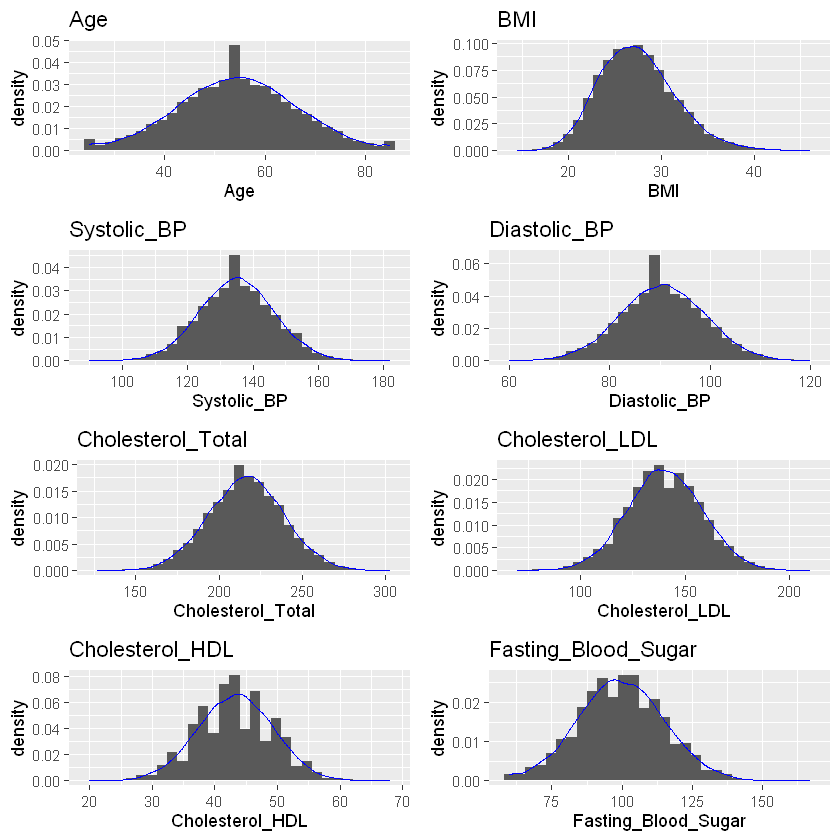

In [8]:
# Histogrammes des variables quantitaives

vars <- c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
          "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
          "Fasting_Blood_Sugar")

plots <- lapply(vars, function(v) {
  ggplot(data, aes_string(x = v)) +
    geom_histogram(aes(y = after_stat(density)), bins = 30) +
    geom_density(alpha = .2, col = "blue") +
    ggtitle(v)
})

grid.arrange(grobs = plots, ncol = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe des densités symétriques (donc plutôt gaussiennes) cela sera nécessaire pour certaines méthodes à venir de modélisation (linéaires), mais pas pour toutes (arbres).
</div>

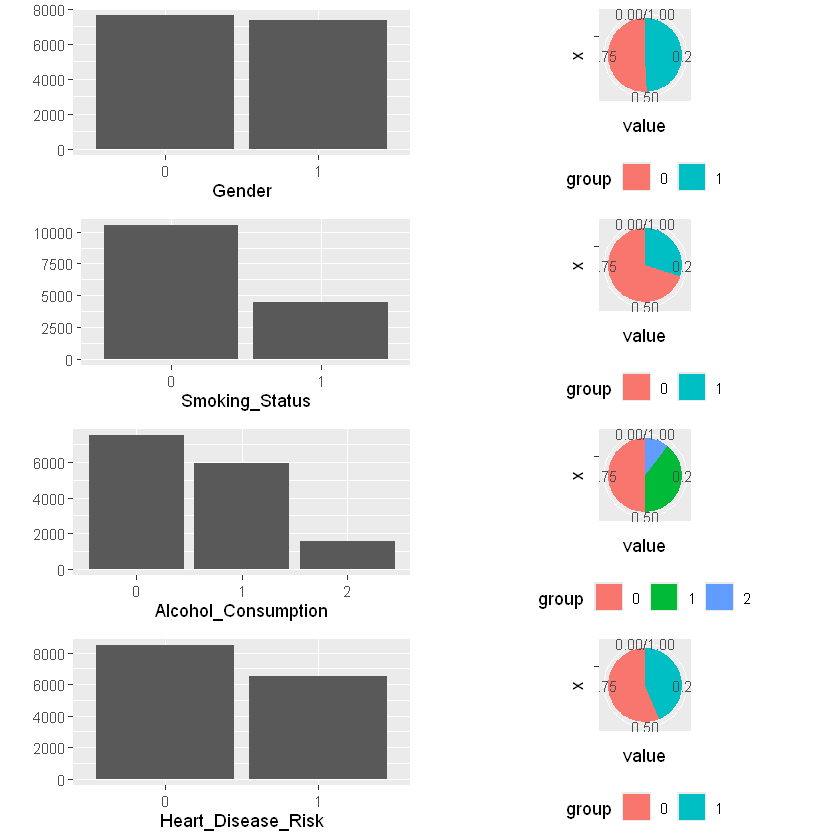

In [9]:
# Statistiques descriptives des variables qualitatives

# Gender
df1 <- data.frame(
  group = levels(as.factor(data$Gender)),
  value = as.vector(table(data$Gender)) / nrow(data)
)

g1 <- ggplot(data, aes(x = Gender)) + 
  geom_bar() +
  ylab("")

g2 <- ggplot(df1, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Smoking_Status
df2 <- data.frame(
  group = levels(as.factor(data$Smoking_Status)),
  value = as.vector(table(data$Smoking_Status)) / nrow(data)
)

g3 <- ggplot(data, aes(x = Smoking_Status)) + 
  geom_bar() +
  ylab("")

g4 <- ggplot(df2, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Alcohol_Consumption
df3 <- data.frame(
  group = levels(as.factor(data$Alcohol_Consumption)),
  value = as.vector(table(data$Alcohol_Consumption)) / nrow(data)
)

g5 <- ggplot(data, aes(x = Alcohol_Consumption)) + 
  geom_bar() +
  ylab("")

g6 <- ggplot(df3, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Heart_Disease_Risk
df4 <- data.frame(
  group = levels(as.factor(data$Heart_Disease_Risk)),
  value = as.vector(table(data$Heart_Disease_Risk)) / nrow(data)
)

g7 <- ggplot(data, aes(x = Heart_Disease_Risk)) + 
  geom_bar() +
  ylab("")

g8 <- ggplot(df4, aes(x = "", y = value, fill = group)) +
  geom_bar(width = 1, stat = "identity") + 
  coord_polar("y", start = 0) + 
  theme(legend.position = "bottom")

# Affichage
grid.arrange(g1, g2, g3, g4, g5, g6, g7, g8, ncol = 2)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La variable genre est équilibrée mais les variables Alcohol_Consumption et Smoking_Status sont fortement déséquilibrées. La variable Heart_Disease_Risk est ??? 
</div>

### Analyse descriptive bidimensionnelles


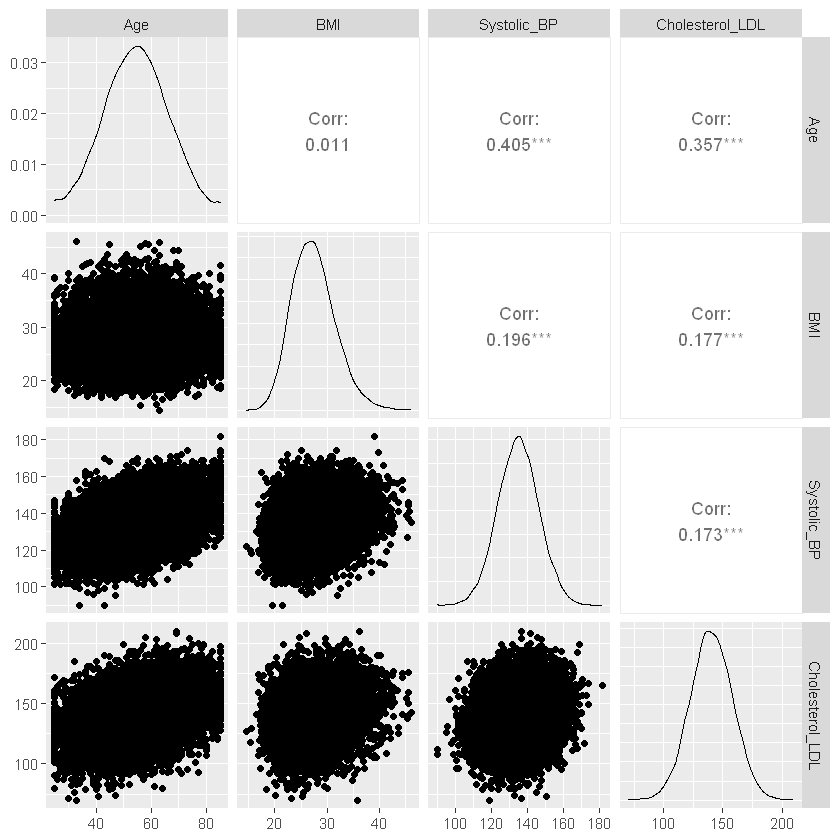

In [10]:
# Corrélations des variables quantitatives

ggpairs(data[, c("Age", "BMI", "Systolic_BP", "Cholesterol_LDL")])

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> La plus forte corrélation observée est entre l'âge et la pression artérielle systolique (Systolic_BP), puis entre l'âge et la quantité de lipoprotéines de basse densité "mauvais cholestérol (Cholesterol_LDL).
</div>

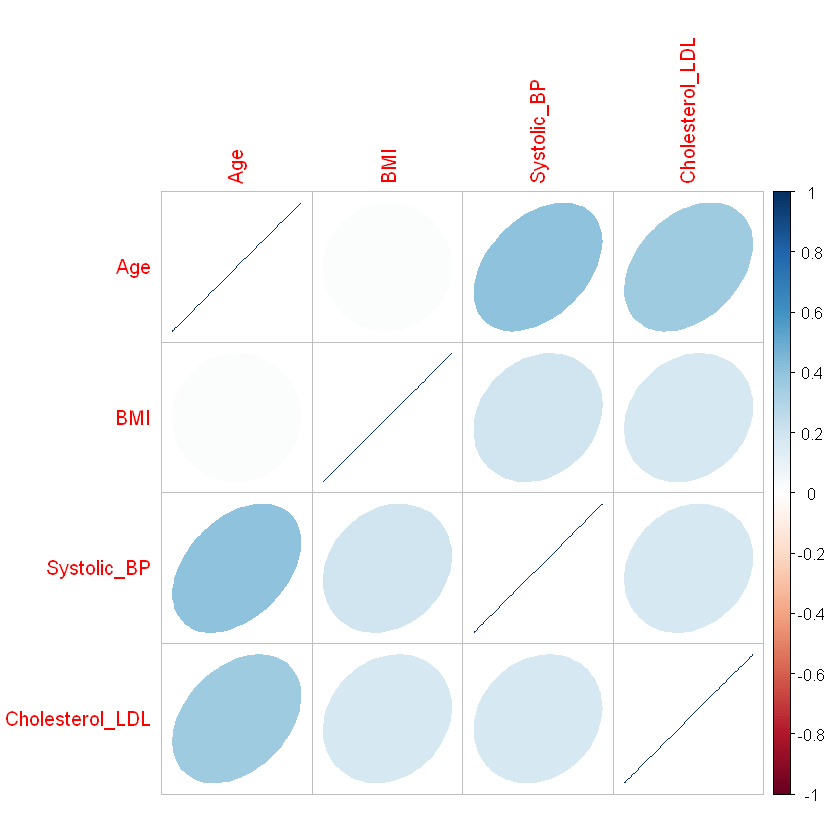

In [11]:
# On fait la même chose avec corrplot pour comparer

corrplot(cor(data[, c("Age", "BMI", "Systolic_BP", "Cholesterol_LDL")]),method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Attention, ici on ne mesure que des corrélations linéaires entre les variables quantitatives. Pour étudier la corrélation entre les variables quantitatives et qualitatives il faut calculer le coefficient "éta carré".
</div>

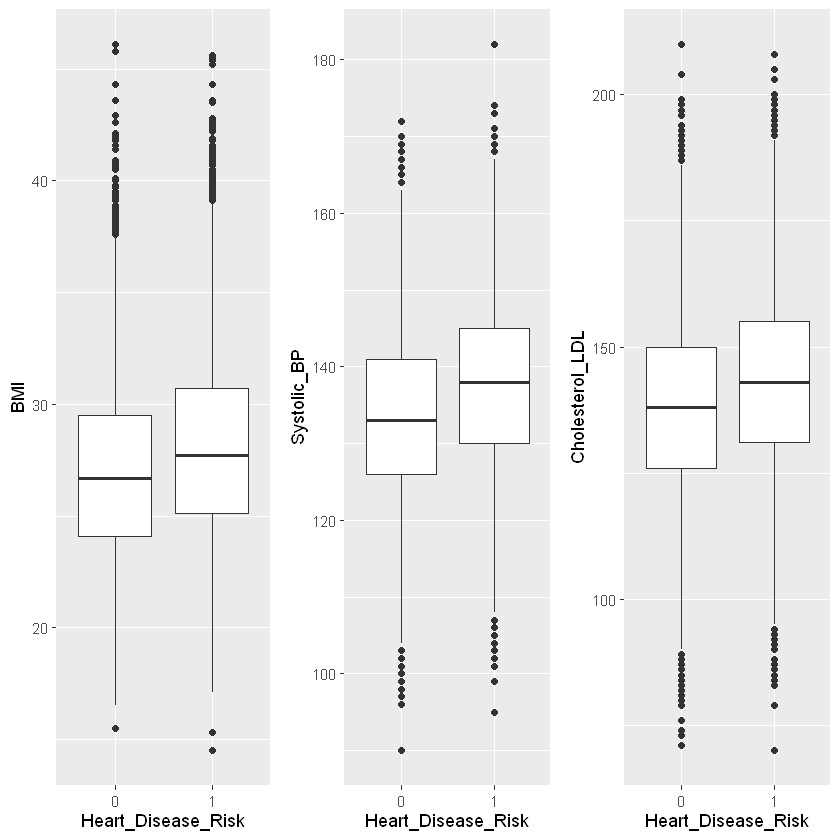

In [12]:
# Analyse bidimensionnelle des variables quantitatives et qualitatives

g1 <- ggplot(data, aes(x = Heart_Disease_Risk, y = BMI)) +
  geom_boxplot()

g2 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Systolic_BP)) +
  geom_boxplot()

g3 <- ggplot(data, aes(x = Heart_Disease_Risk, y = Cholesterol_LDL)) +
  geom_boxplot()

grid.arrange(g1, g2, g3, ncol = 3)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> Ici on regarde le risque d’accident cardiaque en fonction de 3 variables : l'indice de masse corporelle (BMI), la pression artérielle systolique (Systolic_BP) et la quantité de lipoprotéines de basse densité "mauvais cholestérol" (Cholesterol_LDL). On observe pas de forte corrélation avec l'une de ces variables.
</div>

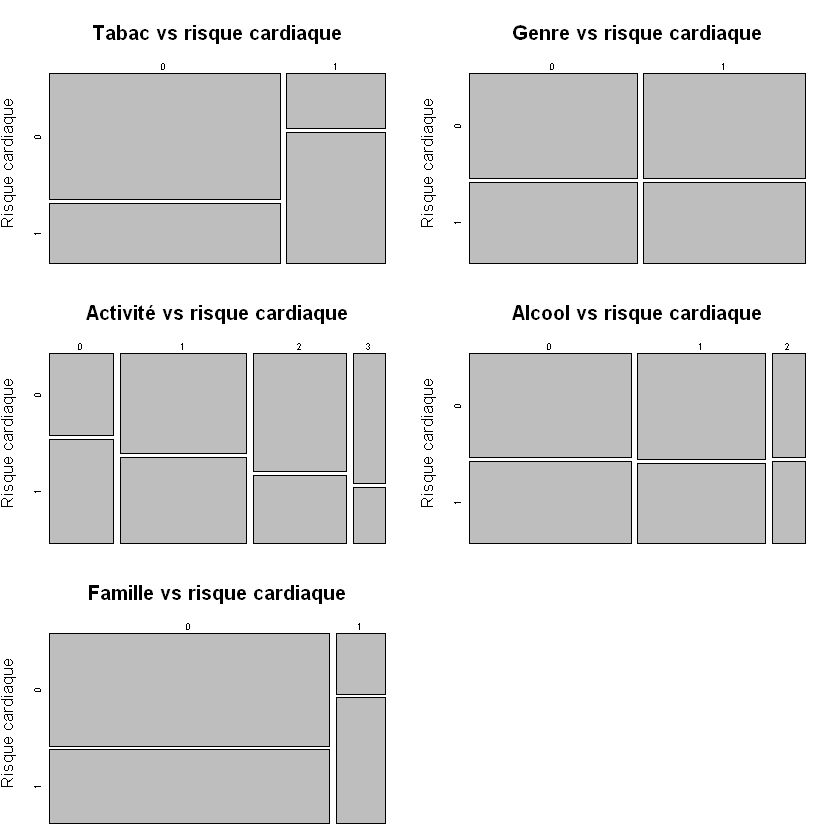

In [13]:
# Mettre 2 lignes et 3 colonnes pour afficher plusieurs plots sur une seule fenêtre
par(mfrow = c(3, 2), mar = c(1, 2, 4, 1), cex.axis = 1.2, cex.lab = 1.3, cex.main = 1.5) # 'mar' ajuste les marges pour que ce soit plus compact

# Mosaic plots
mosaicplot(
  table(data$Smoking_Status, data$Heart_Disease_Risk),
  xlab = "Statut tabagisme",
  ylab = "Risque cardiaque",
  main = "Tabac vs risque cardiaque"
)

mosaicplot(
  table(data$Gender, data$Heart_Disease_Risk),
  xlab = "Genre",
  ylab = "Risque cardiaque",
  main = "Genre vs risque cardiaque"
)

mosaicplot(
  table(data$Physical_Activity_Level, data$Heart_Disease_Risk),
  xlab = "Activité physique",
  ylab = "Risque cardiaque",
  main = "Activité vs risque cardiaque"
)

mosaicplot(
  table(data$Alcohol_Consumption, data$Heart_Disease_Risk),
  xlab = "Consommation alcool",
  ylab = "Risque cardiaque",
  main = "Alcool vs risque cardiaque"
)

mosaicplot(
  table(data$Family_History, data$Heart_Disease_Risk),
  xlab = "Histoire familiale",
  ylab = "Risque cardiaque",
  main = "Famille vs risque cardiaque"
)

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b> On observe que les non-fumeurs ont majoritairement un faible risque cardiaque, tandis que les fumeurs présentent une proportion plus grande de risque élevé, ce qui est cohérent avec les effets connus du tabac sur la santé cardiovasculaire. La variable décrivant l'histoire familiale se comporte de la même façon : les personnes ayant des antécédents familiaux de maladie cardiaque présentent une proportion plus grande de risque élevé.
    Le genre et la consommation d'alcool ne semblent pas corrélés au risque cardiaque. 
    Le niveau d'activité physique semble corrélé linéairement au risuqe cardiaque.  
</div>

### ACP

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


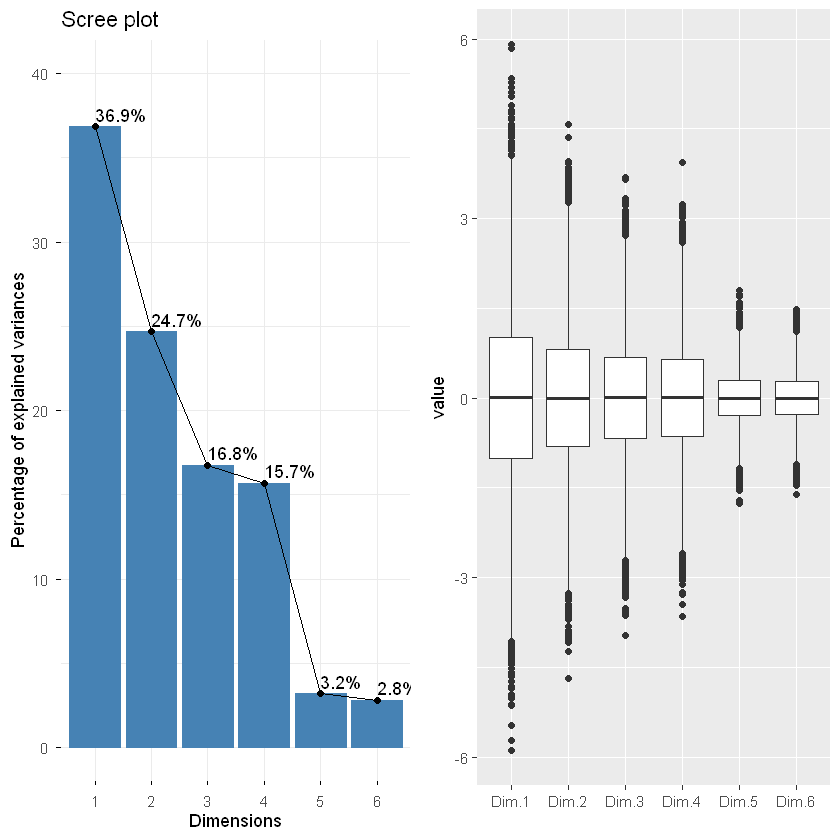

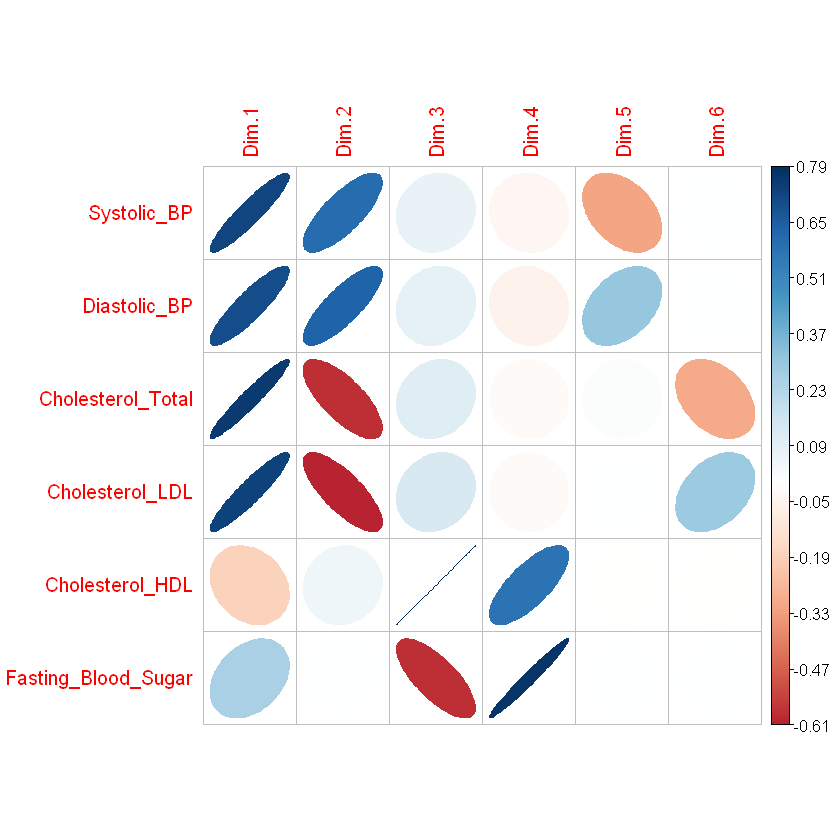

In [14]:
# ACP sur les variables quantitatives. Par ailleurs la variable à modéliser (Heart_Disease_Risk) n'est pas utilisée.

acp <- PCA(data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
          "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
          "Fasting_Blood_Sugar")], scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
library(factoextra)
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
library(reshape2)
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  Ici la première composante principale représente 36.9% des données. D'après le coude observé sur le premier garphe on pourrait garder 2 ou 4 dimensions. Les 4 variables : "Systolic_BP", "Diastolic_BP", "Cholesterol_Total" et "Cholesterol_LDL" semblent fortement corrélées à la dimension 1. 
</div>

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>."


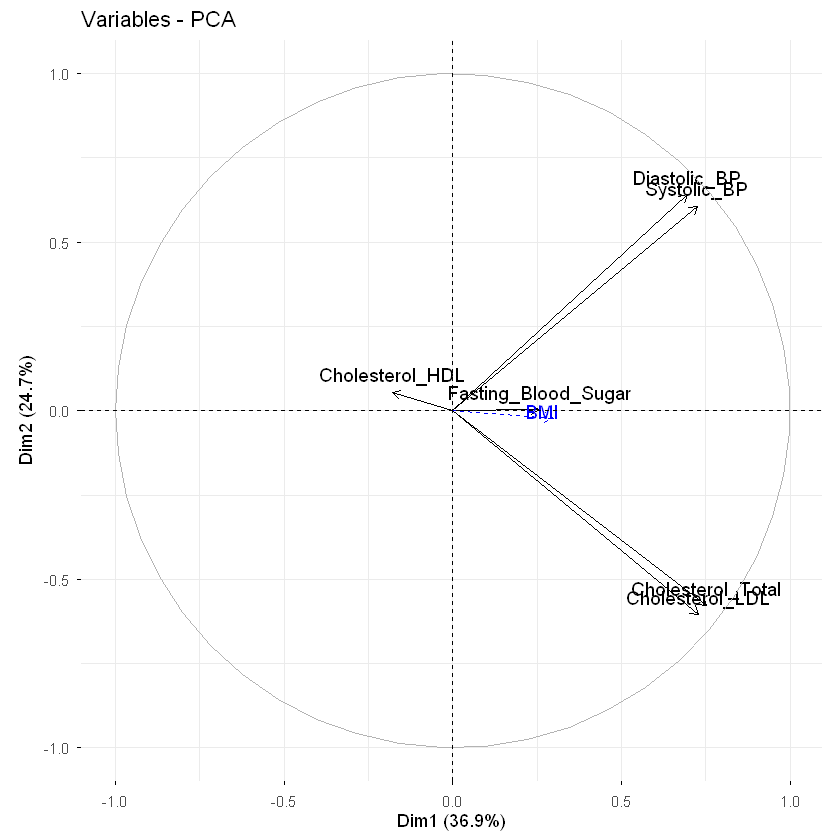

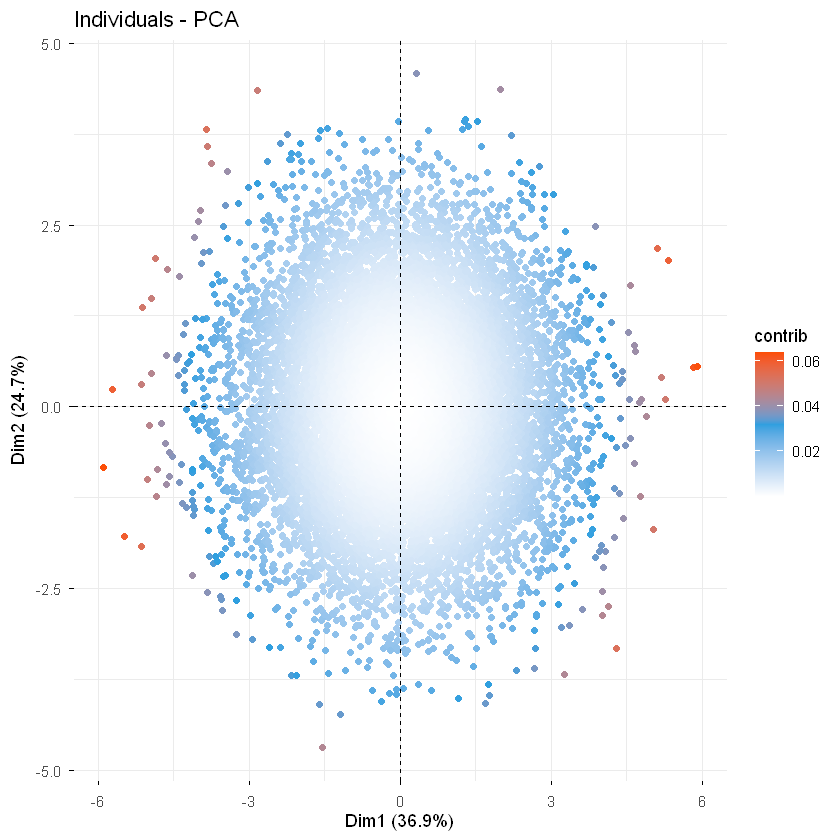

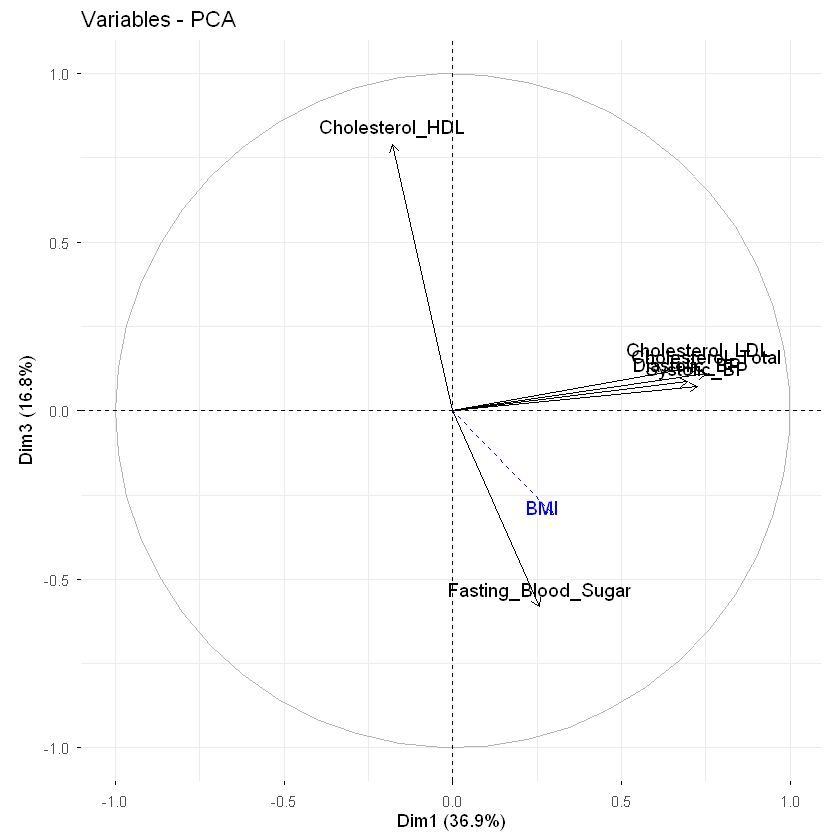

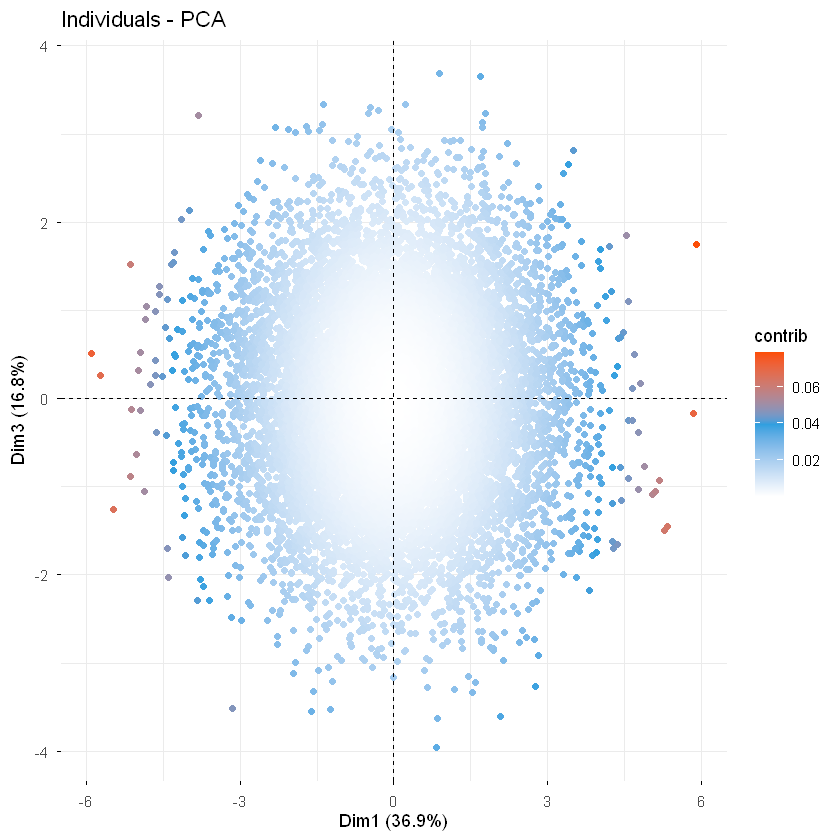

In [15]:
fviz_pca_var(acp)
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
fviz_pca_var(acp,axes=c(1,3))
fviz_pca_ind(acp,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

<div style="border-left:5px solid orange; padding:15px; background-color:#fff8e1; border-radius:5px; font-family:Arial, sans-serif; line-height:1.6;">
  <strong>Interprétation :</strong><br><br>

  <em>Premier graphe (dim 1 et dim 2) :</em><br>
  - <strong>Systolic_BP</strong> et <strong>Diastolic_BP</strong> sont fortement corrélées.<br>
  - <strong>Cholesterol_Total</strong> et <strong>Cholesterol_LDL</strong> sont corrélés positivement.<br>
  - <strong>Cholesterol_HDL</strong> et <strong>BMI</strong> sont corrélés négativement.<br>
  - <strong>Fasting_Blood_Sugar</strong> et <strong>BMI</strong> présentent une légère corrélation positive.<br><br>

  <em>Deuxième graphe (dim 2 et dim 3) :</em><br>
  - À part <strong>BMI</strong>, <strong>Fasting_Blood_Sugar</strong> et <strong>Cholesterol_HDL</strong>, les variables sont fortement corrélées entre elles.
</div>

### Clustering

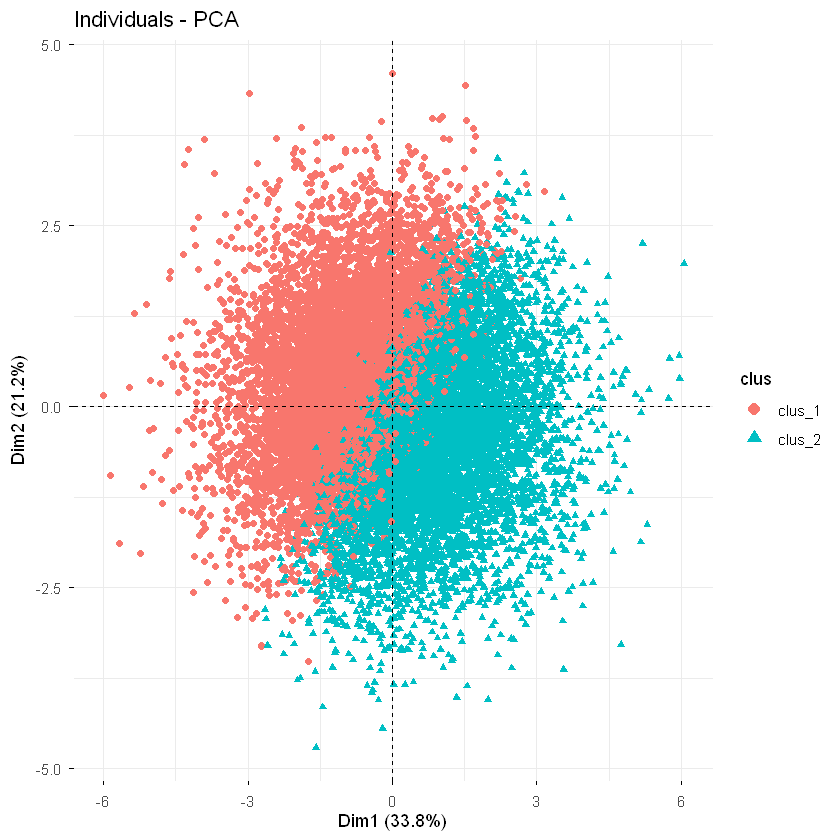

In [16]:
km.data <- kmeans(data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP","Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL", "Fasting_Blood_Sugar")],
  centers = 2)
# Représentation dans les coordonnées de l'acp
acp2 <- PCA(cbind(clus = as.factor(km.data$cluster),
          data[, c("Age", "BMI", "Systolic_BP", "Diastolic_BP",
                 "Cholesterol_Total", "Cholesterol_LDL",
                 "Cholesterol_HDL", "Fasting_Blood_Sugar")]), scale.unit = TRUE,
          graph = FALSE, quali.sup = 1:2, ncp = 7)
fviz_pca_ind(acp2, label="none", habillage="clus")

<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  
</div>

# 3. Modélisation

###  Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pour évaluer correctement un modèle, on divise le jeu de données en échantillon d’apprentissage (80%) et échantillon test (20%). L’échantillon d’apprentissage sert à entraîner le modèle, tandis que l’échantillon test permet de mesurer ses performances sur des données jamais vues. Cette étape est nécessaire pour éviter le surapprentissage et obtenir une estimation réaliste de la capacité du modèle à généraliser à de nouvelles données.

In [17]:
set.seed(111) # initialisation du générateur
# Extraction des échantillons
test.ratio <- .2   # part de l'échantillon test
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
# taille de l'échantillon test
ntest <- ceiling(npop * test.ratio) 
# indices de l'échantillon test
testi <- sample(1:npop, ntest)
# indices de l'échantillon d'apprentissage
appri <- setdiff(1:npop, testi) 

Construction des échantillons pour la régression: prévision du risque d’accident cardiaque "Heart_Disease_Risk".

ENLEVER LE HEART_DISEASE_RISK POUR ETUDE DU CHOLESTEROL

In [ ]:
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -c(1, 19)]

# construction de l'échantillon test
datestr0 <- data[testi, -c(1, 19)] 

# vérification
# str(datappr0)
# str(datestr0)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
str(datappr)
str(datestr)

'data.frame':	12000 obs. of  17 variables:
 $ Age                    : num  0.455 -0.13 0.622 1.541 -0.214 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  -2.006 -0.384 1.021 0.868 -0.623 ...
 $ Weight_kg              : num  -1.701 0.104 1.232 -0.445 -1.059 ...
 $ BMI                    : num  -0.882 0.463 0.707 -1.103 -0.907 ...
 $ Systolic_BP            : num  0.4318 -0.6293 0.5202 0.0781 -0.0987 ...
 $ Diastolic_BP           : num  -0.181 -1.125 1.118 0.646 0.173 ...
 $ Cholesterol_Total      : num  0.034 -0.583 -1.904 -1.023 0.386 ...
 $ Cholesterol_LDL        : num  0.593 -1.189 -0.911 -1.301 0.815 ...
 $ Cholesterol_HDL        : num  1.461 -0.889 0.286 0.286 0.789 ...
 $ Fasting_Blood_Sugar    : num  -1.094 1.074 -0.634 -1.226 0.22 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Act

Construction des échantillons pour la discrimination: prévision du risque d’accident cardiaque "Heart_Disease_Risk".

In [66]:
# construction de l'échantillon d'apprentissage
datappq0 <- data[appri, -1]

# construction de l'échantillon test
datestq0 <- data[testi, -1] 

# vérification
str(datappq0)
str(datestq0)

# on identifie les colonnes numériques
num_cols <- sapply(datappq0, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappq <- datappq0
datappq[, num_cols] <- scale(datappq0[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestq <- datestq0
datestq[, num_cols] <- scale(
  datestq0[, num_cols],
  center = sapply(datappq0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappq0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
summary(datappq)
summary(datestq)

'data.frame':	12000 obs. of  18 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_Total      : int  217 203 173 193 225 260 237 227 206 188 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $

      Age           Gender     Height_cm          Weight_kg       
 Min.   :-2.46911   0:6083   Min.   :-2.91995   Min.   :-2.95670  
 1st Qu.:-0.71488   1:5917   1st Qu.:-0.74279   1st Qu.:-0.71629  
 Median : 0.03694            Median :-0.06788   Median :-0.09554  
 Mean   : 0.00000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.70522            3rd Qu.: 0.73767   3rd Qu.: 0.61796  
 Max.   : 2.54298            Max.   : 3.53532   Max.   : 5.34851  
      BMI           Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.1570   Min.   :-3.98919   Min.   :-3.60504   Min.   :-3.70977  
 1st Qu.:-0.7112   1st Qu.:-0.71768   1st Qu.:-0.65311   1st Qu.:-0.67073  
 Median :-0.0753   Median :-0.01033   Median : 0.05535   Median : 0.03397  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.6340   3rd Qu.: 0.69702   3rd Qu.: 0.64573   3rd Qu.: 0.69463  
 Max.   : 4.4984   Max.   : 4.14536   Max.   : 3.47959   Max.   : 3.73367  

      Age            Gender     Height_cm           Weight_kg       
 Min.   :-2.469112   0:1539   Min.   :-2.919954   Min.   :-2.52147  
 1st Qu.:-0.631343   1:1461   1st Qu.:-0.742795   1st Qu.:-0.70202  
 Median :-0.046599            Median :-0.067876   Median :-0.05987  
 Mean   :-0.008228            Mean   : 0.007207   Mean   : 0.04050  
 3rd Qu.: 0.621681            3rd Qu.: 0.715902   3rd Qu.: 0.66791  
 Max.   : 2.542985            Max.   : 3.567980   Max.   : 4.54939  
      BMI            Systolic_BP         Diastolic_BP       Cholesterol_Total  
 Min.   :-2.59448   Min.   :-3.547092   Min.   :-3.132733   Min.   :-3.929990  
 1st Qu.:-0.71121   1st Qu.:-0.629264   1st Qu.:-0.653114   1st Qu.:-0.670732  
 Median :-0.05084   Median :-0.010330   Median :-0.003690   Median :-0.010071  
 Mean   : 0.04674   Mean   : 0.000368   Mean   : 0.005914   Mean   : 0.004258  
 3rd Qu.: 0.65845   3rd Qu.: 0.697022   3rd Qu.: 0.645734   3rd Qu.: 0.650589  
 Max.   : 4.57174   Max.   : 2.995917

In [67]:
# code pour trouver les variables numeric mais inutile 
# str(datappr0)  # regarde le type de chaque colonne
# sapply(datappr0, class)  # renvoie le type

In [68]:
#Enfin, avant de passer aux différents algorithmes, définissons une fonction traçant le graphe des résidus avec des couleurs et des échelles fixes sur les axes.
#c'était dans le TP à voir si c'est utile

gplot.res <- function(x, y, titre = "titre"){
    ggplot(data.frame(x=x, y=y),aes(x,y))+
    geom_point(col = "blue")+xlim(0, 250)+ylim(-155, 155)+
    ylab("Résidus")+ xlab("Valeurs prédites")+
    ggtitle(titre)+
    geom_hline(yintercept = 0,col="green")
}

consigne : Comparez les performances d’un modèle linéaire (éventuellement généralisé) avec/sans sélection de vari
ables, avec/sans pénalisation, d’un SVR/SVM, d’un arbre optimal, d’une forêt aléatoire, du boosting,
et de réseaux de neurones. Justifiez vos choix (par exemple le noyau pour le SVR/SVM), identifiez les
hyperparamètres de chaque modèle et ajustez-les soigneusement (par validation croisée). Interprétez les
résultats et quantifiez l’amélioration éventuelle apportée par les modèles non linéaires.

## 3.3 Prévision par arbre binaire de discrimination

Nous allons réaliser une prévision par **arbre de décision binaire (CART)**. Puisque `Heart_Disease_Risk` est une variable qualitative binaire, on estime un **arbre de discrimination**.

> **Note :** Les arbres sont invariants aux changements d'échelle. On utilise `datappq` / `datestq` pour la cohérence avec les autres modèles du notebook.

### 3.3.1 Estimation et élagage de l'arbre de discrimination

#### 3.3.1.1 Critère : indice de Gini

On construit d'abord un arbre complet (paramètre `cp` très petit), puis on l'**élague par validation croisée** en sélectionnant le `cp` qui minimise l'erreur CV estimée (`xerror`).

In [70]:
set.seed(111)

# Arbre complet (critère Gini)
# cp=0.001 : arbre peu contraint (grand), méthode "class" pour la discrimination
tree.dis.full <- rpart(
  Heart_Disease_Risk ~ .,
  data    = datappq,
  method  = "class",
  parms   = list(split = "gini"),
  control = rpart.control(cp = 0.001)
)

# Tableau de complexité : colonnes nsplit, rel error, xerror (erreur CV), xstd
printcp(tree.dis.full)


Classification tree:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, method = "class", 
    parms = list(split = "gini"), control = rpart.control(cp = 0.001))

Variables actually used in tree construction:
 [1] Age                     BMI                     Cholesterol_HDL        
 [4] Cholesterol_LDL         Cholesterol_Total       Diastolic_BP           
 [7] Family_History          Fasting_Blood_Sugar     Height_cm              
[10] Physical_Activity_Level Sleep_Hours             Smoking_Status         
[13] Stress_Level            Systolic_BP             Weight_kg              

Root node error: 5260/12000 = 0.43833

n= 12000 

          CP nsplit rel error  xerror      xstd
1  0.2815589      0   1.00000 1.00000 0.0103335
2  0.0374525      1   0.71844 0.71844 0.0096733
3  0.0066540      2   0.68099 0.68099 0.0095300
4  0.0050063      3   0.67433 0.68517 0.0095467
5  0.0047529      6   0.65932 0.68042 0.0095277
6  0.0045627      7   0.65456 0.67814 0.0095185
7  0.0039449 

Nombre de feuilles : 47 


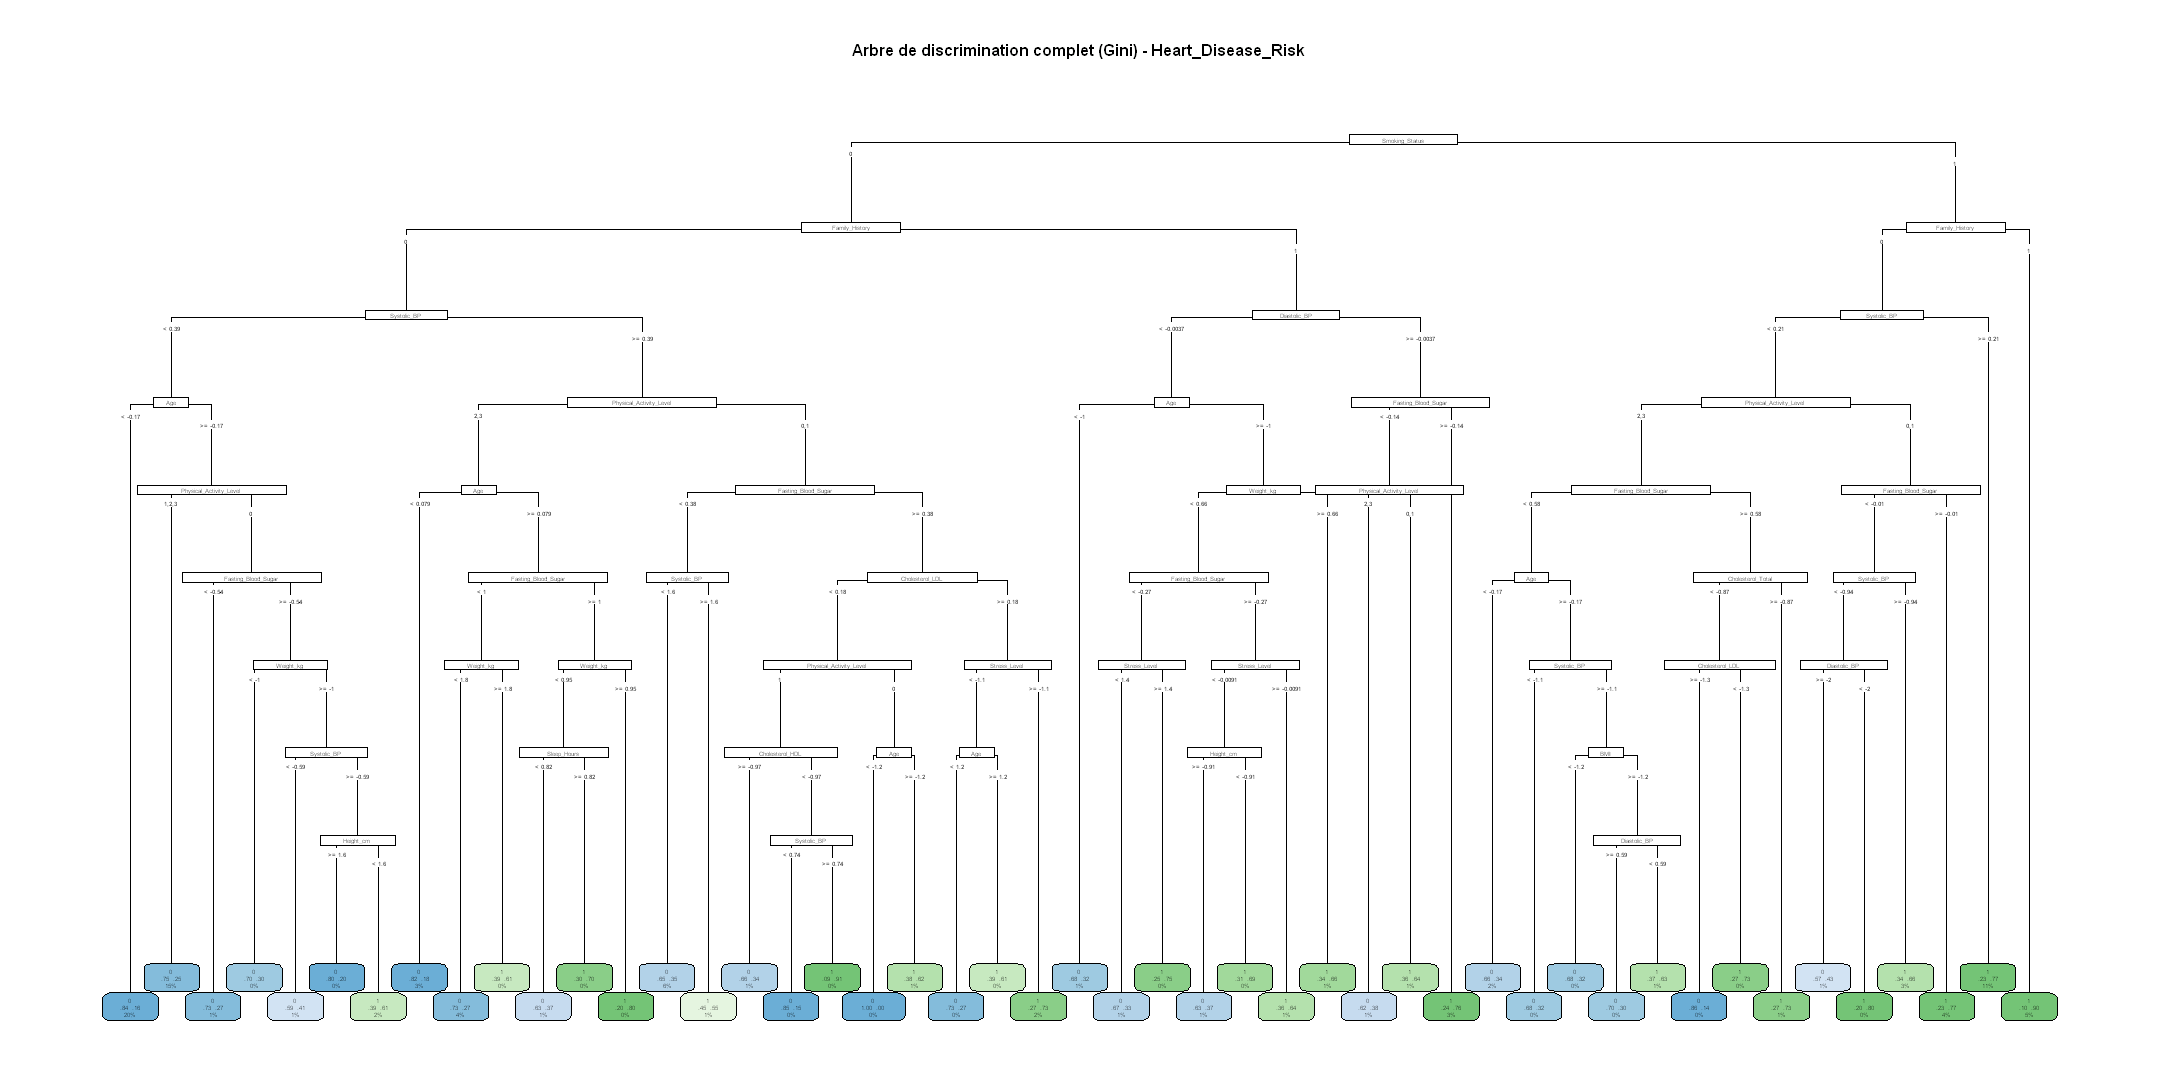

In [71]:
cat("Nombre de feuilles :", sum(tree.dis.full$frame$var == "<leaf>"), "\n") # 47 feuilles

# Visualisation de l'arbre complet (47 feuilles)
# type=5 : affiche la probabilité de classe ; extra=104 : proba + effectif
options(repr.plot.width = 18, repr.plot.height = 9)
rpart.plot(
  tree.dis.full,
  type  = 5,
  extra = 104,
  main  = "Arbre de discrimination complet (Gini) - Heart_Disease_Risk"
)

cp optimal (Gini) : 0.001330798 
Nombre de feuilles : 29 


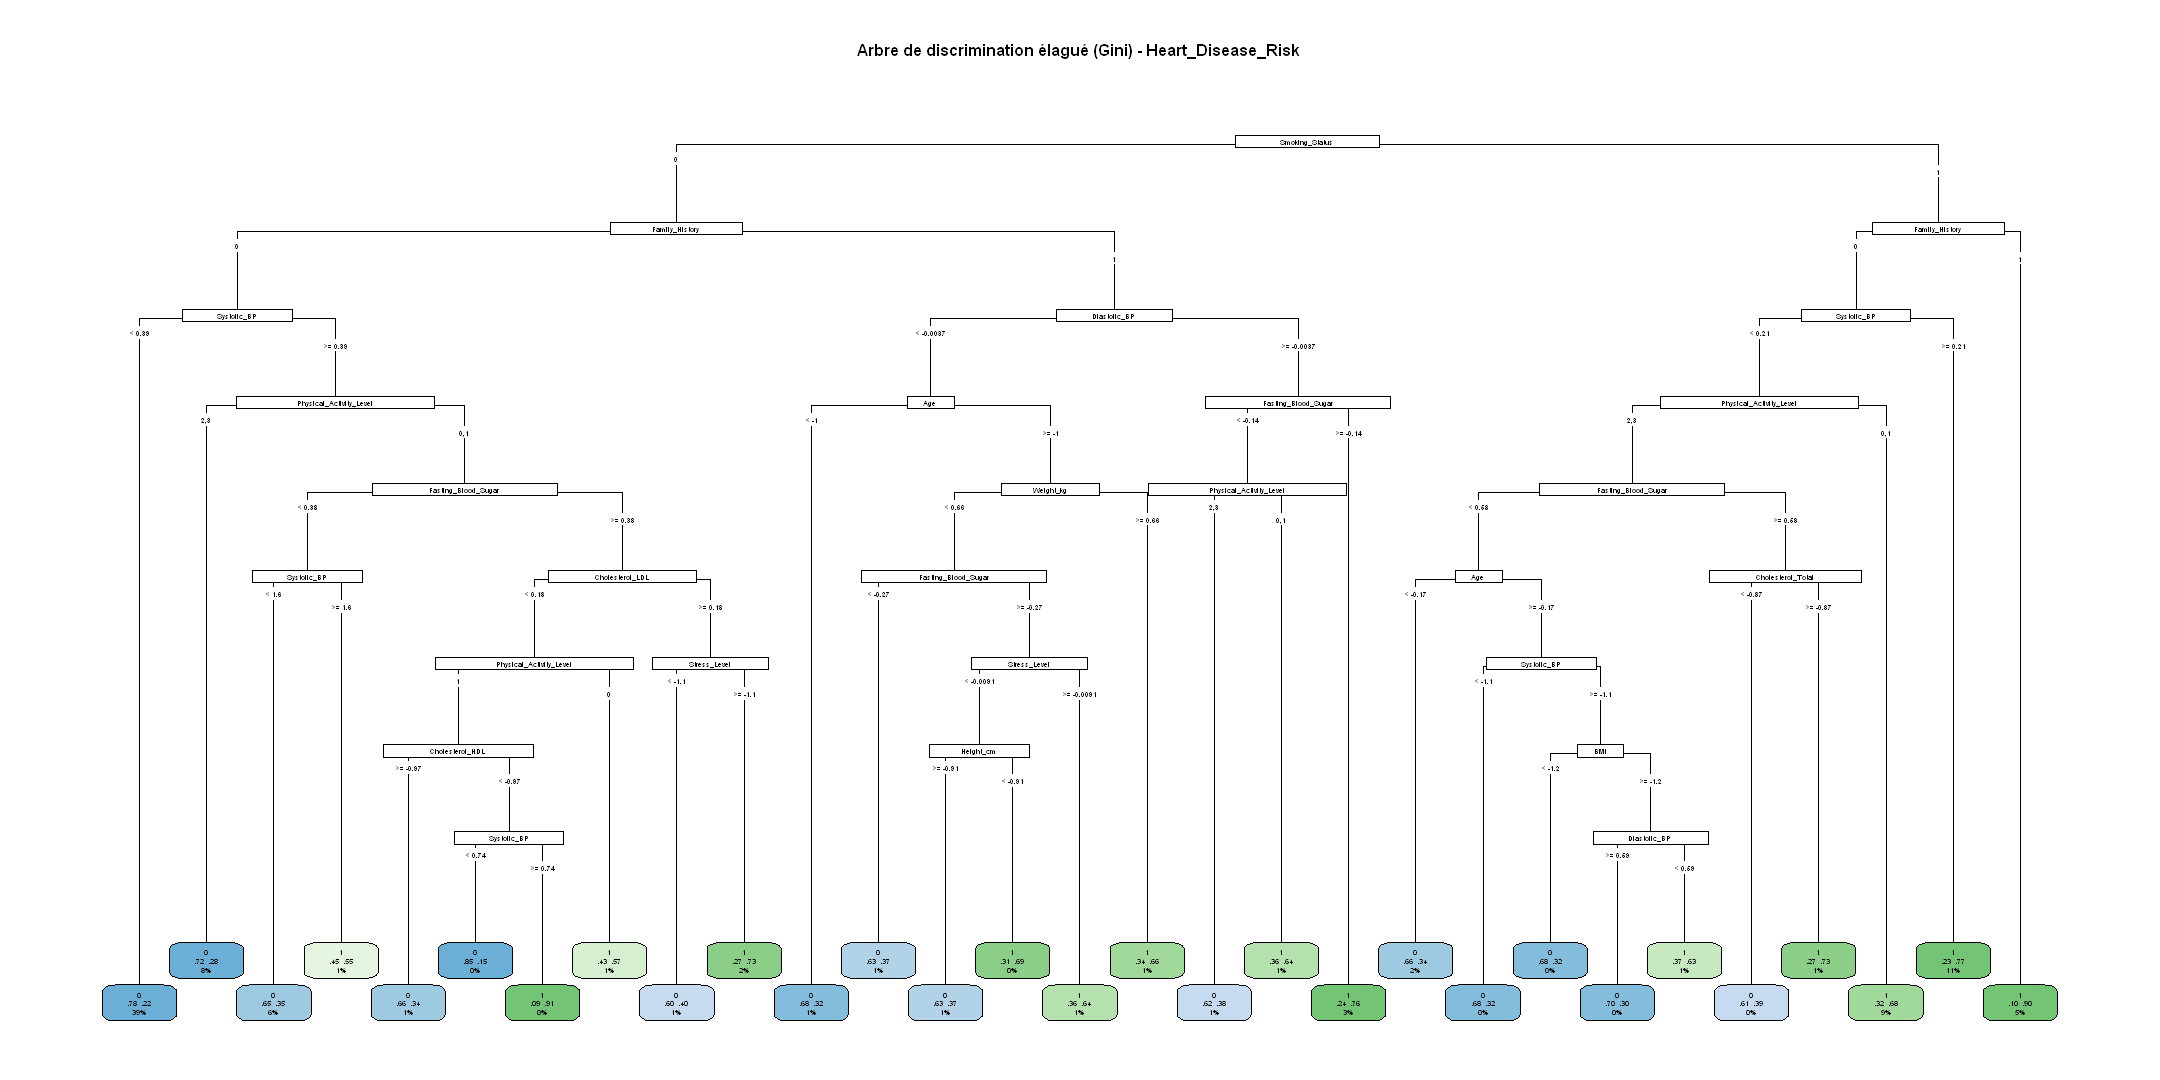

In [72]:
# Élagage par validation croisée
# On sélectionne le cp qui minimise l'erreur de validation croisée (xerror)
opt_cp_dis <- tree.dis.full$cptable[which.min(tree.dis.full$cptable[, "xerror"]), "CP"]
cat("cp optimal (Gini) :", opt_cp_dis, "\n")

# Élagage de l'arbre
tree.dis.gini <- prune(tree.dis.full, cp = opt_cp_dis)

cat("Nombre de feuilles :", sum(tree.dis.gini$frame$var == "<leaf>"), "\n") # 29 feuilles

# Visualisation de l'arbre élagué
# type=5 : affiche la probabilité de classe ; extra=104 : proba + effectif
options(repr.plot.width = 18, repr.plot.height = 9)
rpart.plot(
  tree.dis.gini,
  type  = 5,
  extra = 104,
  main  = "Arbre de discrimination élagué (Gini) - Heart_Disease_Risk"
)

#### 3.3.1.2 Critère : entropie (information gain)

On refait l'estimation avec le critère d'**entropie** pour le comparer à Gini.

cp optimal (Entropie) : 0.001064639 
Nombre de feuilles : 39 


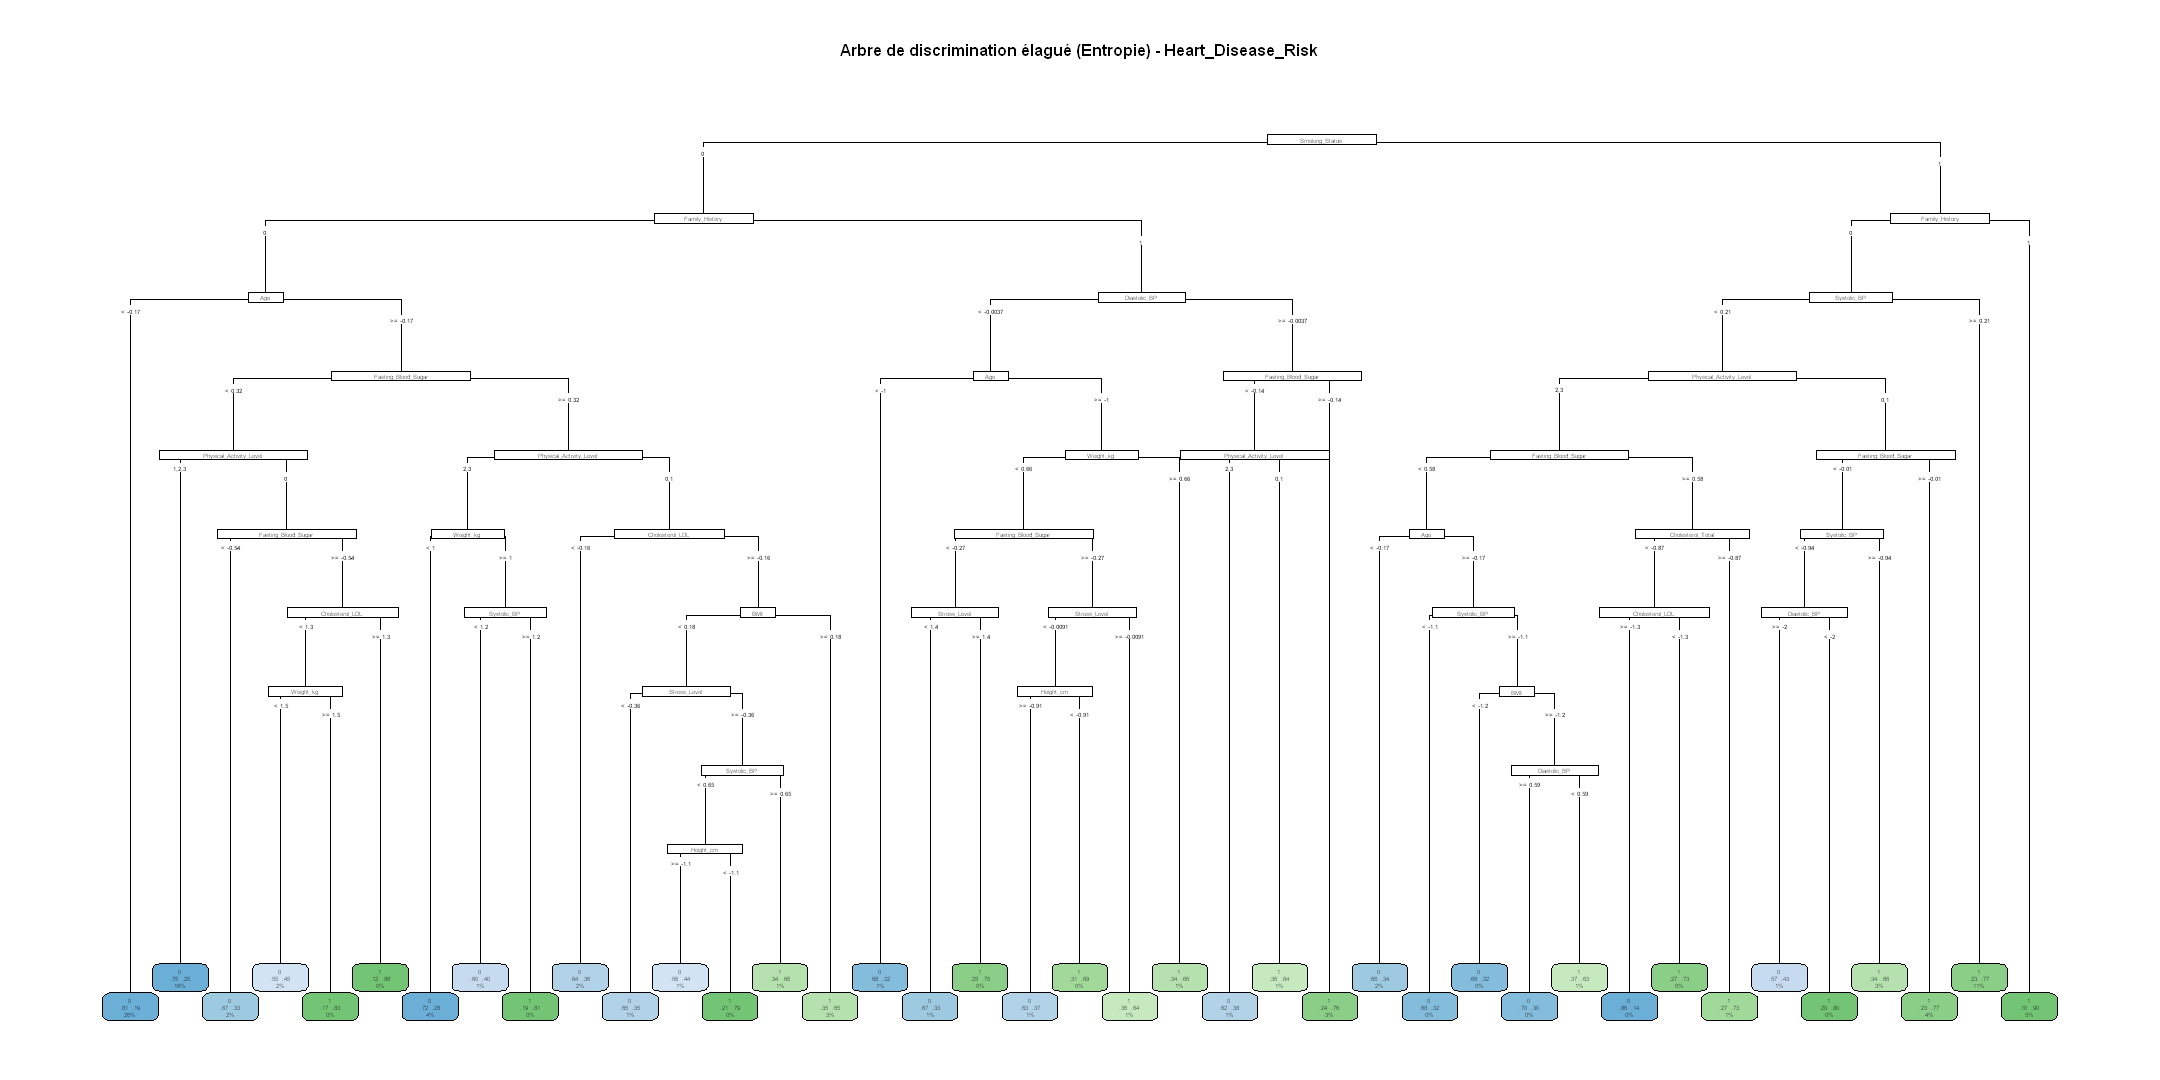

In [73]:
# Arbre complet (critère entropie)
tree.dis.ent.full <- rpart(
  Heart_Disease_Risk ~ .,
  data    = datappq,
  method  = "class",
  parms   = list(split = "information"),
  control = rpart.control(cp = 0.001)
)

opt_cp_ent <- tree.dis.ent.full$cptable[which.min(tree.dis.ent.full$cptable[, "xerror"]), "CP"]
cat("cp optimal (Entropie) :", opt_cp_ent, "\n")

tree.dis.ent <- prune(tree.dis.ent.full, cp = opt_cp_ent)

cat("Nombre de feuilles :", sum(tree.dis.ent$frame$var == "<leaf>"), "\n") # 39 feuilles

options(repr.plot.width = 18, repr.plot.height = 9)
rpart.plot(
  tree.dis.ent,
  type  = 5,
  extra = 104,
  main  = "Arbre de discrimination élagué (Entropie) - Heart_Disease_Risk"
)

Comparaison entre Gini et entropie

In [74]:
printcp(tree.dis.ent)

print("-------------------------")

printcp(tree.dis.gini)


Classification tree:
rpart(formula = Heart_Disease_Risk ~ ., data = datappq, method = "class", 
    parms = list(split = "information"), control = rpart.control(cp = 0.001))

Variables actually used in tree construction:
 [1] Age                     BMI                     Cholesterol_LDL        
 [4] Cholesterol_Total       Diastolic_BP            Family_History         
 [7] Fasting_Blood_Sugar     Height_cm               Physical_Activity_Level
[10] Smoking_Status          Stress_Level            Systolic_BP            
[13] Weight_kg              

Root node error: 5260/12000 = 0.43833

n= 12000 

          CP nsplit rel error  xerror      xstd
1  0.2815589      0   1.00000 1.00000 0.0103335
2  0.0374525      1   0.71844 0.71844 0.0096733
3  0.0066540      2   0.68099 0.68099 0.0095300
4  0.0045627      3   0.67433 0.67966 0.0095246
5  0.0044677      4   0.66977 0.68346 0.0095399
6  0.0039924      8   0.65190 0.67928 0.0095231
7  0.0039449      9   0.64791 0.67852 0.0095200
8  0.0

In [75]:
print("Gini :")
tree.dis.gini$frame$var
print("Entropie :")
tree.dis.ent$frame$var


print("Gini :")
unique(as.character(tree.dis.gini$frame$var[tree.dis.gini$frame$var != "<leaf>"]))
print("Entropie :")
unique(as.character(tree.dis.ent$frame$var[tree.dis.ent$frame$var != "<leaf>"]))


[1] "Gini :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Systolic_BP"             "<leaf>"                 
 [5] "Physical_Activity_Level" "<leaf>"                 
 [7] "Fasting_Blood_Sugar"     "Systolic_BP"            
 [9] "<leaf>"                  "<leaf>"                 
[11] "Cholesterol_LDL"         "Physical_Activity_Level"
[13] "Cholesterol_HDL"         "<leaf>"                 
[15] "Systolic_BP"             "<leaf>"                 
[17] "<leaf>"                  "<leaf>"                 
[19] "Stress_Level"            "<leaf>"                 
[21] "<leaf>"                  "Diastolic_BP"           
[23] "Age"                     "<leaf>"                 
[25] "Weight_kg"               "Fasting_Blood_Sugar"    
[27] "<leaf>"                  "Stress_Level"           
[29] "Height_cm"               "<leaf>"                 
[31] "<leaf>"                  "<leaf>"                 
[33] "<leaf>"                  "Fasting_Blood_Sugar"    
[35] "Physical_Activity_Level" "<leaf>"                 
[37] "<leaf>"                  "<leaf>"                 
[39] "Family_History"          "Systolic_BP"            
[41] "Physical_Activity_Level" "Fasting_Blood_Sugar"    
[43] "Age"                     "<leaf>"                 
[45] "Systolic_BP"             "<leaf>"                 
[47] "BMI"                     "<leaf>"                 
[49] "Diastolic_BP"            "<leaf>"                 
[51] "<leaf>"                  "Cholesterol_Total"      
[53] "<leaf>"                  "<leaf>"                 
[55] "<leaf>"                  "<leaf>"                 
[57] "<leaf>"

[1] "Entropie :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Age"                     "<leaf>"                 
 [5] "Fasting_Blood_Sugar"     "Physical_Activity_Level"
 [7] "<leaf>"                  "Fasting_Blood_Sugar"    
 [9] "<leaf>"                  "Cholesterol_LDL"        
[11] "Weight_kg"               "<leaf>"                 
[13] "<leaf>"                  "<leaf>"                 
[15] "Physical_Activity_Level" "Weight_kg"              
[17] "<leaf>"                  "Systolic_BP"            
[19] "<leaf>"                  "<leaf>"                 
[21] "Cholesterol_LDL"         "<leaf>"                 
[23] "BMI"                     "Stress_Level"           
[25] "<leaf>"                  "Systolic_BP"            
[27] "Height_cm"               "<leaf>"                 
[29] "<leaf>"                  "<leaf>"                 
[31] "<leaf>"                  "Diastolic_BP"           
[33] "Age"                     "<leaf>"                 
[35] "Weight_kg"               "Fasting_Blood_Sugar"    
[37] "Stress_Level"            "<leaf>"                 
[39] "<leaf>"                  "Stress_Level"           
[41] "Height_cm"               "<leaf>"                 
[43] "<leaf>"                  "<leaf>"                 
[45] "<leaf>"                  "Fasting_Blood_Sugar"    
[47] "Physical_Activity_Level" "<leaf>"                 
[49] "<leaf>"                  "<leaf>"                 
[51] "Family_History"          "Systolic_BP"            
[53] "Physical_Activity_Level" "Fasting_Blood_Sugar"    
[55] "Age"                     "<leaf>"                 
[57] "Systolic_BP"             "<leaf>"                 
[59] "BMI"                     "<leaf>"                 
[61] "Diastolic_BP"            "<leaf>"                 
[63] "<leaf>"                  "Cholesterol_Total"      
[65] "Cholesterol_LDL"         "<leaf>"                 
[67] "<leaf>"                  "<leaf>"                 
[69] "Fasting_Blood_Sugar"     "Systolic_BP"            
[71] "Diastolic_BP"            "<leaf>"                 
[73] "<leaf>"                  "<leaf>"                 
[75] "<leaf>"                  "<leaf>"                 
[77] "<leaf>"

[1] "Gini :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Systolic_BP"             "Physical_Activity_Level"
 [5] "Fasting_Blood_Sugar"     "Cholesterol_LDL"        
 [7] "Cholesterol_HDL"         "Stress_Level"           
 [9] "Diastolic_BP"            "Age"                    
[11] "Weight_kg"               "Height_cm"              
[13] "BMI"                     "Cholesterol_Total"

[1] "Entropie :"


[1] "Smoking_Status"          "Family_History"         
 [3] "Age"                     "Fasting_Blood_Sugar"    
 [5] "Physical_Activity_Level" "Cholesterol_LDL"        
 [7] "Weight_kg"               "Systolic_BP"            
 [9] "BMI"                     "Stress_Level"           
[11] "Height_cm"               "Diastolic_BP"           
[13] "Cholesterol_Total"

### 3.3.2 Prévision de l'échantillon test

#### 3.3.2.1 Taux de mal classés et matrices de confusion

In [76]:
# Taux d'erreur et matrices de confusion sur le test
pred_gini_test <- predict(tree.dis.gini,     datestq, type = "class")
pred_ent_test  <- predict(tree.dis.ent, datestq, type = "class")

err_gini_test <- mean(pred_gini_test != datestq$Heart_Disease_Risk)
err_ent_test  <- mean(pred_ent_test  != datestq$Heart_Disease_Risk)

cat(sprintf("Taux d'erreur test - Gini    : %.4f  (accuracy = %.4f)\n",
            err_gini_test, 1 - err_gini_test))
cat(sprintf("Taux d'erreur test - Entropie: %.4f  (accuracy = %.4f)\n",
            err_ent_test,  1 - err_ent_test))

cat("\nMatrice de confusion (Gini) :\n")
print(table(Prédit = pred_gini_test, Observé = datestq$Heart_Disease_Risk))

cat("\nMatrice de confusion (Entropie) :\n")
print(table(Prédit = pred_ent_test, Observé = datestq$Heart_Disease_Risk))

Taux d'erreur test - Gini    : 0.2793  (accuracy = 0.7207)
Taux d'erreur test - Entropie: 0.2700  (accuracy = 0.7300)

Matrice de confusion (Gini) :
      Observé
Prédit    0    1
     0 1392  510
     1  328  770

Matrice de confusion (Entropie) :
      Observé
Prédit    0    1
     0 1402  492
     1  318  788


#### 3.3.2.2 Courbes ROC

AUC - Gini    : 0.7520
AUC - Entropie: 0.7660


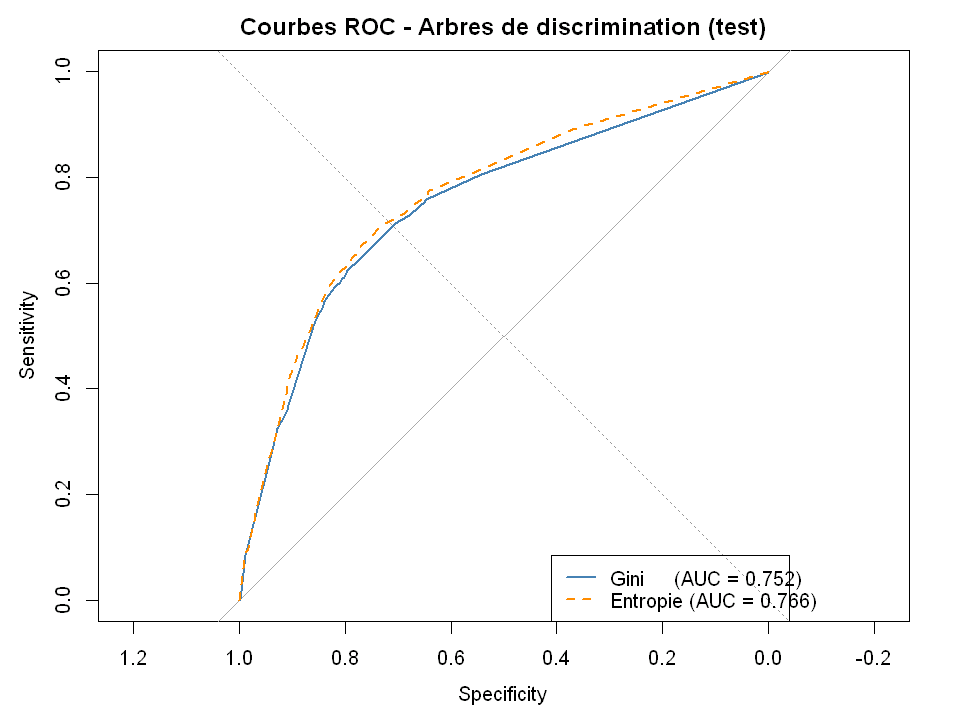

In [77]:
# Courbes ROC
# predict(..., type="prob") : probabilité estimée d'appartenir à la classe 1
prob_gini_test <- predict(tree.dis.gini,     datestq, type = "prob")[, 2]
prob_ent_test  <- predict(tree.dis.ent, datestq, type = "prob")[, 2]

roc_gini <- roc(datestq$Heart_Disease_Risk, prob_gini_test, quiet = TRUE)
roc_ent  <- roc(datestq$Heart_Disease_Risk, prob_ent_test,  quiet = TRUE)

cat(sprintf("AUC - Gini    : %.4f\n", auc(roc_gini)))
cat(sprintf("AUC - Entropie: %.4f\n", auc(roc_ent)))

options(repr.plot.width = 8, repr.plot.height = 6)
plot(roc_gini, col = "steelblue", lwd = 2,
     main = "Courbes ROC - Arbres de discrimination (test)")
lines(roc_ent, col = "darkorange", lwd = 2, lty = 2)
abline(a = 0, b = 1, lty = 3, col = "grey60")
legend("bottomright",
       legend = c(sprintf("Gini     (AUC = %.3f)", auc(roc_gini)),
                  sprintf("Entropie (AUC = %.3f)", auc(roc_ent))),
       col = c("steelblue", "darkorange"), lwd = 2, lty = c(1, 2))

### 3.3.3 Importance des variables

L'importance d'une variable dans `rpart` est la **réduction totale de l'indice de Gini** qu'elle génère, pondérée par la proportion d'observations passant par chaque nœud.

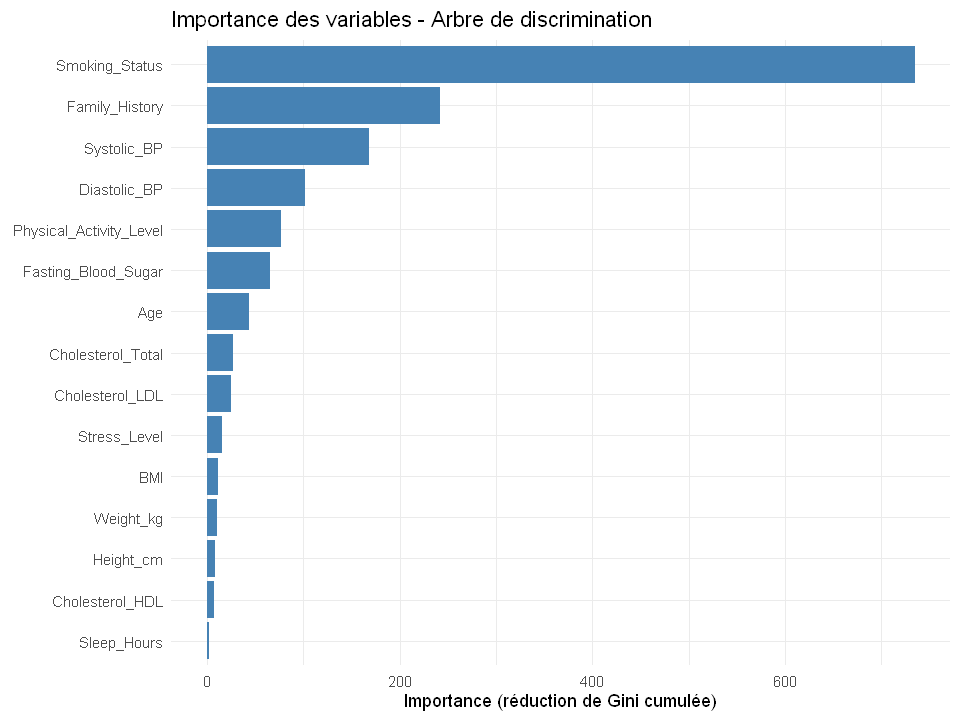

In [78]:
# Importance des variables (arbre de discrimination)
imp_dis <- tree.dis.gini$variable.importance
imp_dis_df <- data.frame(
  variable   = names(imp_dis),
  importance = as.numeric(imp_dis)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_dis_df, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction de Gini cumulée)",
       title = "Importance des variables - Arbre de discrimination") +
  theme_minimal()

---
## 3.4 Prévision par forêt aléatoire - Discrimination (`Heart_Disease_Risk`)

Une **forêt aléatoire** agrège $B$ arbres entraînés sur des sous-échantillons **bootstrap** (**bagging**). À chaque nœud, seul un sous-ensemble de $m$ variables est tiré au sort (**feature subsampling**), ce qui décolle les arbres et réduit la variance.

**Hyperparamètres :**
- `ntree` : nombre d'arbres $B$
- `mtry` : nombre de variables candidates à chaque nœud ($m \approx \sqrt{p}$ en discrimination)
- `nodesize` : taille minimale d'une feuille

### 3.4.1 Analyse de convergence (erreur OOB)

L'erreur **OOB** (*Out-Of-Bag*) est estimée gratuitement : chaque arbre est évalué sur les ~37% d'observations non tirées dans son bootstrap. C'est un estimateur fiable de l'erreur de généralisation.

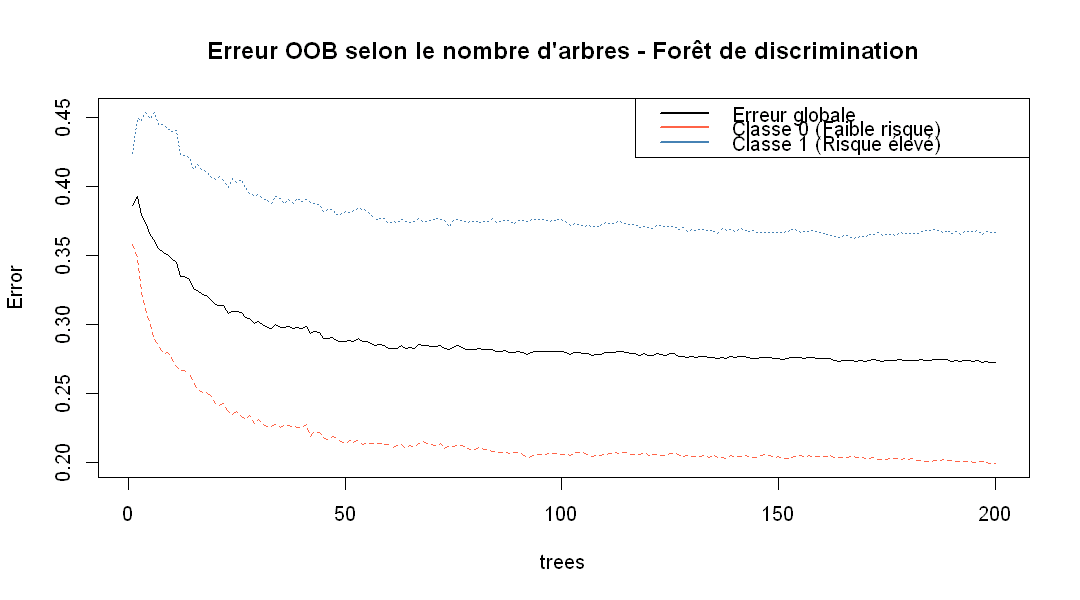

In [79]:
# Convergence de l'erreur OOB
set.seed(111)
rf.dis.conv <- randomForest(
  Heart_Disease_Risk ~ .,
  data     = datappq, # utilisation de data plutot que datappq pour voir la convergence sur l'ensemble des données (et OOB donc déjà séparation et évaluation sur l'ensemble des données)
  ntree    = 200,
  mtry     = floor(sqrt(ncol(datappq) - 1)),  # sqrt(p) : règle empirique
  nodesize = 1
)

# La courbe doit se stabiliser : on choisit ntree à partir duquel
# l'erreur OOB ne diminue plus significativement.
options(repr.plot.width = 9, repr.plot.height = 5)
plot(rf.dis.conv,
     main = "Erreur OOB selon le nombre d'arbres - Forêt de discrimination",
     col  = c("black", "tomato", "steelblue"))
legend("topright",
       legend = c("Erreur globale", "Classe 0 (Faible risque)", "Classe 1 (Risque élevé)"),
       col    = c("black", "tomato", "steelblue"), lwd = 2)

### 3.4.2 Optimisation de `mtry`

  mtry oob_erreur
1    2  0.2790833
2    4  0.2802500
3    5  0.2790833
4    8  0.2782500
5   17  0.2835833

mtry optimal : 8  (erreur OOB = 0.2782)


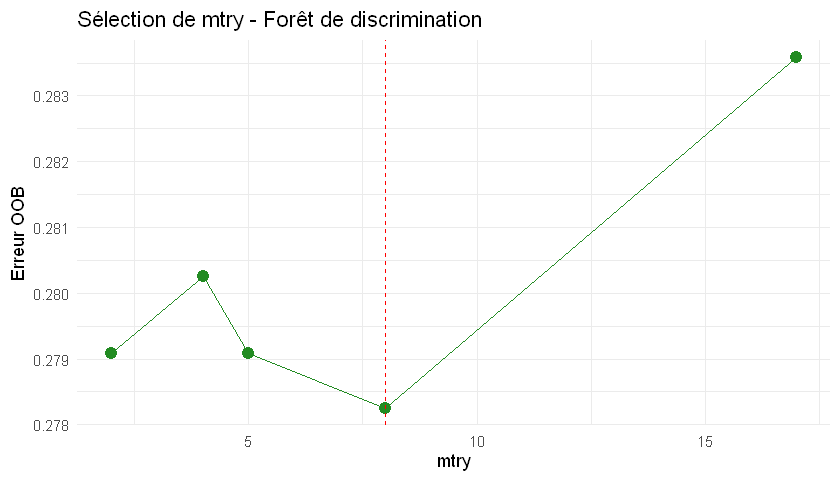

In [80]:
# Sélection de mtry par erreur OOB
# On teste plusieurs valeurs de mtry et on retient celle qui minimise l'erreur OOB.
set.seed(111)
p_dis <- ncol(datappq) - 1  # nombre de variables explicatives

mtry_vals <- sort(unique(c(
  2,
  floor(sqrt(p_dis)),    # ~sqrt(p) : règle empirique discrimination
  floor(p_dis / 3),
  floor(p_dis / 2),
  p_dis                  # bagging pur
)))

oob_err_mtry <- sapply(mtry_vals, function(m) {
  rf <- randomForest(Heart_Disease_Risk ~ ., data = datappq,
                     ntree = 100, mtry = m, nodesize = 1)
  tail(rf$err.rate[, "OOB"], 1)
})

df_mtry_dis <- data.frame(mtry = mtry_vals, oob_erreur = oob_err_mtry)
print(df_mtry_dis)

best_mtry_dis <- mtry_vals[which.min(oob_err_mtry)]
cat(sprintf("\nmtry optimal : %d  (erreur OOB = %.4f)\n",
            best_mtry_dis, min(oob_err_mtry)))

options(repr.plot.width = 7, repr.plot.height = 4)
ggplot(df_mtry_dis, aes(x = mtry, y = oob_erreur)) +
  geom_line(colour = "forestgreen") + geom_point(colour = "forestgreen", size = 3) +
  geom_vline(xintercept = best_mtry_dis, linetype = "dashed", colour = "red") +
  labs(x = "mtry", y = "Erreur OOB",
       title = "Sélection de mtry - Forêt de discrimination") +
  theme_minimal()

In [81]:
# Modèle final (forêt de discrimination)
set.seed(111)
rf.dis <- randomForest(
  Heart_Disease_Risk ~ .,
  data       = datappq,
  ntree      = 100,
  mtry       = best_mtry_dis,
  nodesize   = 1,
  importance = TRUE   # active le calcul des deux mesures d'importance
)

print(rf.dis)
cat(sprintf("Accuracy OOB : %.4f\n", 1 - tail(rf.dis$err.rate[, "OOB"], 1)))


Call:
 randomForest(formula = Heart_Disease_Risk ~ ., data = datappq,      ntree = 100, mtry = best_mtry_dis, nodesize = 1, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 100
No. of variables tried at each split: 8

        OOB estimate of  error rate: 27.8%
Confusion matrix:
     0    1 class.error
0 5367 1373   0.2037092
1 1963 3297   0.3731939
Accuracy OOB : 0.7220


### 3.4.3 Évaluation sur l'échantillon test

In [82]:
# Prédictions test
pred_rf_dis_test <- predict(rf.dis, datestq, type = "class")
prob_rf_dis_test <- predict(rf.dis, datestq, type = "prob")[, 2]

err_rf_dis <- mean(pred_rf_dis_test != datestq$Heart_Disease_Risk)
cat(sprintf("Taux d'erreur test - Forêt : %.4f  (accuracy = %.4f)\n",
            err_rf_dis, 1 - err_rf_dis))

cat("\nMatrice de confusion (Forêt) :\n")
print(table(Prédit = pred_rf_dis_test, Observé = datestq$Heart_Disease_Risk))

roc_rf_dis <- roc(datestq$Heart_Disease_Risk, prob_rf_dis_test, quiet = TRUE)
cat(sprintf("AUC - Forêt : %.4f\n", auc(roc_rf_dis)))

Taux d'erreur test - Forêt : 0.2660  (accuracy = 0.7340)

Matrice de confusion (Forêt) :
      Observé
Prédit    0    1
     0 1376  454
     1  344  826
AUC - Forêt : 0.7886


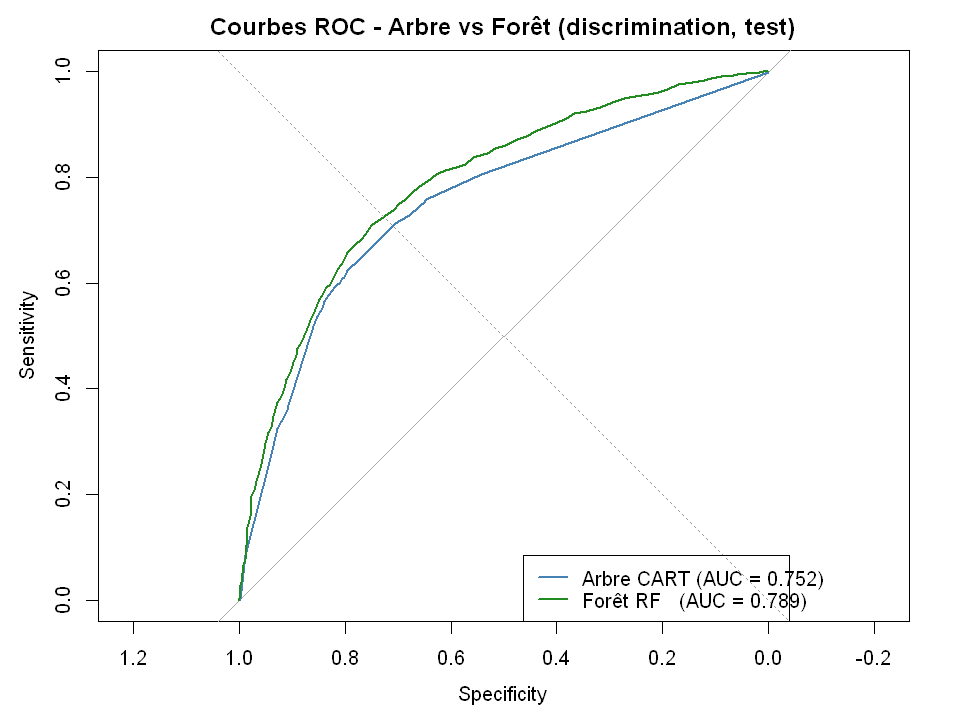

In [83]:
# Courbe ROC : Arbre vs Forêt
options(repr.plot.width = 8, repr.plot.height = 6)
plot(roc_gini,   col = "steelblue",    lwd = 2,
     main = "Courbes ROC - Arbre vs Forêt (discrimination, test)")
lines(roc_rf_dis, col = "forestgreen", lwd = 2)
abline(a = 0, b = 1, lty = 3, col = "grey60")
legend("bottomright",
       legend = c(sprintf("Arbre CART (AUC = %.3f)", auc(roc_gini)),
                  sprintf("Forêt RF   (AUC = %.3f)", auc(roc_rf_dis))),
       col = c("steelblue", "forestgreen"), lwd = 2)

### 3.4.4 Importance des variables

La forêt fournit deux mesures, plus stables que celle de l'arbre seul car moyennées sur $B$ arbres :
- **MeanDecreaseAccuracy** : chute d'accuracy OOB lors d'une permutation aléatoire de la variable
- **MeanDecreaseGini** : réduction totale de l'indice de Gini apportée par la variable

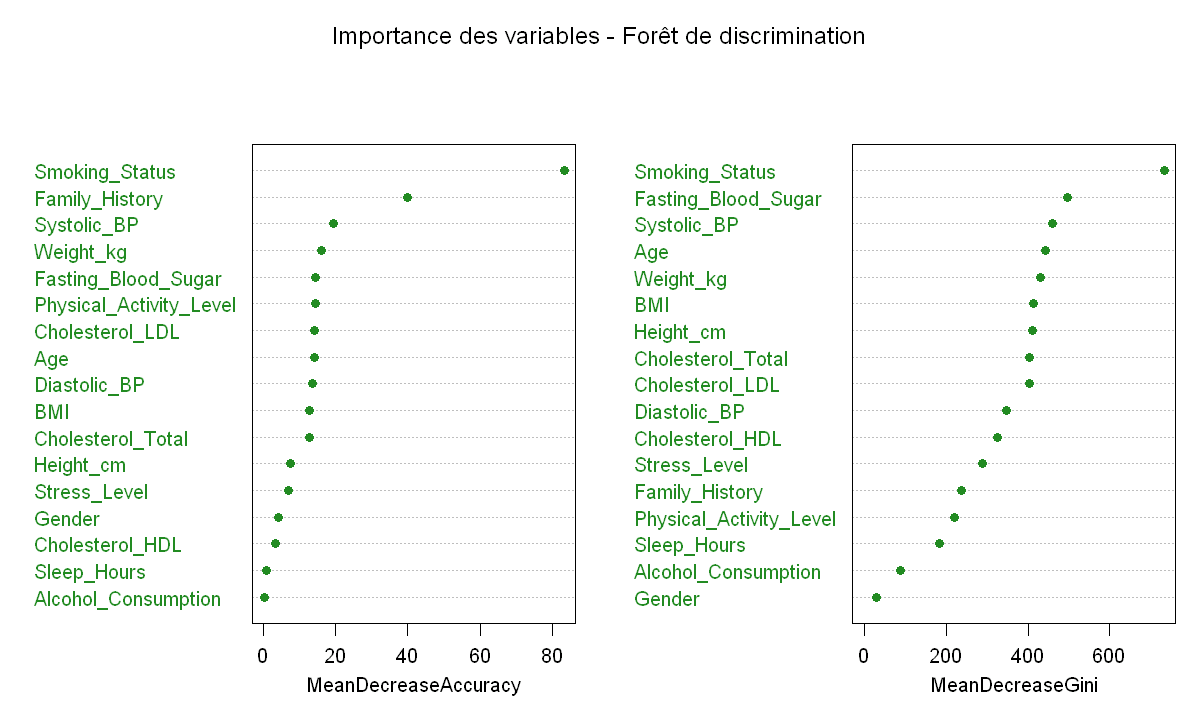

In [84]:
# Graphe d'importance des variables (forêt)
options(repr.plot.width = 10, repr.plot.height = 6)
varImpPlot(
  rf.dis,
  main  = "Importance des variables - Forêt de discrimination",
  col   = "forestgreen",
  pch   = 16
)

### 3.4.5 Bilan - Discrimination (`Heart_Disease_Risk`)

In [85]:
# Tableau récapitulatif (discrimination)
resultats_dis <- data.frame(
  Modele    = c("Arbre CART Gini (élagué)",
                "Arbre CART Entropie (élagué)",
                "Forêt aléatoire"),
  Erreur    = round(c(err_gini_test, err_ent_test, err_rf_dis), 4),
  Accuracy  = round(c(1-err_gini_test, 1-err_ent_test, 1-err_rf_dis), 4),
  AUC       = round(c(as.numeric(auc(roc_gini)),
                      as.numeric(auc(roc_ent)),
                      as.numeric(auc(roc_rf_dis))), 4)
)
print(resultats_dis)

# L'arbre CART est plus interprétable (règles de décision lisibles dans le graphe).
# La forêt réduit la variance par agrégation de B=100 arbres, au prix
# de l'interprétabilité (mais l'importance des variables reste disponible).

                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2700   0.7300 0.7660
3              Forêt aléatoire 0.2660   0.7340 0.7886


---
## 3.5 Prévision par arbre de régression - `Cholesterol_LDL`

On prédit la variable **quantitative** `Cholesterol_LDL` à partir de toutes les autres variables, **sauf `Heart_Disease_Risk`** (consigne du sujet). On utilise `datappr` (apprentissage) et `datestr` (test).

En régression, CART minimise l'**erreur quadratique** (`method="anova"`). La valeur prédite dans chaque feuille est la **moyenne** des observations.

### 3.5.1 Estimation et élagage de l'arbre de régression

In [86]:
# Arbre de régression complet
tree.reg.full <- rpart(
  Cholesterol_LDL ~ .,
  data    = datappr,
  method  = "anova",
  control = rpart.control(cp = 0.0001)
)

printcp(tree.reg.full)


Regression tree:
rpart(formula = Cholesterol_LDL ~ ., data = datappr, method = "anova", 
    control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
 [1] Age                     Alcohol_Consumption     BMI                    
 [4] Cholesterol_HDL         Cholesterol_Total       Diastolic_BP           
 [7] Family_History          Fasting_Blood_Sugar     Gender                 
[10] Height_cm               Physical_Activity_Level Sleep_Hours            
[13] Smoking_Status          Stress_Level            Systolic_BP            
[16] Weight_kg              

Root node error: 11999/12000 = 0.99992

n= 12000 

            CP nsplit rel error  xerror      xstd
1   0.43049490      0   1.00000 1.00006 0.0131747
2   0.09210564      1   0.56951 0.57593 0.0078569
3   0.08535086      2   0.47740 0.47759 0.0066837
4   0.01789120      3   0.39205 0.39823 0.0052844
5   0.01624614      4   0.37416 0.37958 0.0050989
6   0.01361311      5   0.35791 0.37127 0.0050438
7   0.

cp optimal : 0.0003676323 
Nombre de feuilles : 23 


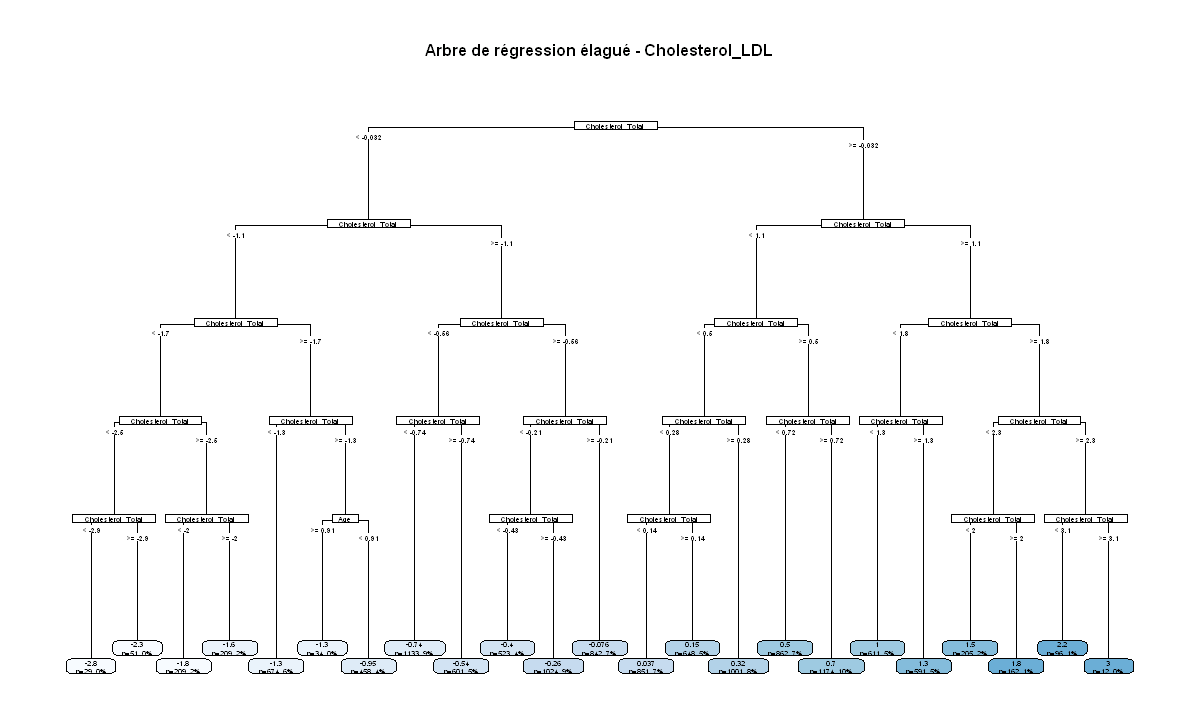

In [87]:
# Élagage par validation croisée
# On minimise xerror (erreur CV estimée) pour sélectionner la taille de l'arbre.
opt_cp_reg <- tree.reg.full$cptable[which.min(tree.reg.full$cptable[, "xerror"]), "CP"]
cat("cp optimal :", opt_cp_reg, "\n")

tree.reg <- prune(tree.reg.full, cp = opt_cp_reg)

cat("Nombre de feuilles :", sum(tree.reg$frame$var == "<leaf>"), "\n")

# options(repr.plot.width = 18, repr.plot.height = 9) # 21 feuilles
rpart.plot(
  tree.reg,
  type  = 5,
  extra = 101,
  main  = "Arbre de régression élagué - Cholesterol_LDL"
)

Problème de data leakage : on n'a que `Cholesterol_Total` dans l'arbre.

Dans un premier temps, on va enlever `Cholesterol_Total` (`datappr.v2`), puis on va aussi enlever (`Cholesterol_HDL`) des données d'études (datappr.v3).

In [88]:
# construction de l'échantillon d'apprentissage sans Cholesterol_Total (peut-être enlever aussi les autres variables de cholestérol ? index = 11)
datappr0.v2 <- data[appri, -c(1, 9, 19)]

# construction de l'échantillon test
datestr0.v2 <- data[testi, -c(1, 9, 19)] 

# vérification
str(datappr0.v2)
str(datestr0.v2)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0.v2, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr.v2 <- datappr0.v2
datappr.v2[, num_cols] <- scale(datappr0.v2[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr.v2 <- datestr0.v2
datestr.v2[, num_cols] <- scale(
  datestr0.v2[, num_cols],
  center = sapply(datappr0.v2[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0.v2[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
# summary(datappr.v2)
# summary(datestr.v2)

'data.frame':	12000 obs. of  16 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Cholesterol_HDL        : int  52 38 45 45 48 46 44 37 38 43 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 4 2 1 2 2 3 3 3

In [89]:
# construction de l'échantillon d'apprentissage sans Cholesterol_Total et Cholesterol_LDL (index = 9 et 11)
datappr0.v3 <- data[appri, -c(1, 9, 11, 19)]

# construction de l'échantillon test
datestr0.v3 <- data[testi, -c(1, 9, 11, 19)] 

# vérification
str(datappr0.v3)
str(datestr0.v3)

# on identifie les colonnes numériques
num_cols <- sapply(datappr0.v3, is.numeric)

# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr.v3 <- datappr0.v3
datappr.v3[, num_cols] <- scale(datappr0.v3[, num_cols])

# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr.v3 <- datestr0.v3
datestr.v3[, num_cols] <- scale(
  datestr0.v3[, num_cols],
  center = sapply(datappr0.v3[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0.v3[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
# summary(datappr.v3)
# summary(datestr.v3)

'data.frame':	12000 obs. of  15 variables:
 $ Age                    : int  60 53 62 73 52 73 64 49 61 49 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 1 1 1 1 2 1 ...
 $ Height_cm              : num  147 162 175 173 160 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 60.3 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 23.7 25 34.5 28.2 36.3 33.9 ...
 $ Systolic_BP            : int  140 128 141 136 134 149 129 139 131 150 ...
 $ Diastolic_BP           : int  89 81 100 96 92 98 90 91 91 100 ...
 $ Cholesterol_LDL        : int  151 119 124 117 155 166 160 138 139 129 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 103 103 108 90 103 106 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 2 1 2 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 1 1 2 1 1 1 ...
 $ Physical_Activity_Level: Factor w/ 4 levels "0","1","2","3": 4 2 1 2 2 3 3 3 3 1 ...
 $ Family_History         : Factor w/ 2 levels "0","1": 1 

In [90]:
# Arbre de régression complet (sans Cholesterol_Total)
tree.reg.full.v2 <- rpart(
  Cholesterol_LDL ~ .,
  data    = datappr.v2,
  method  = "anova",
  control = rpart.control(cp = 0.0001)
)

printcp(tree.reg.full.v2)


Regression tree:
rpart(formula = Cholesterol_LDL ~ ., data = datappr.v2, method = "anova", 
    control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
 [1] Age                     Alcohol_Consumption     BMI                    
 [4] Cholesterol_HDL         Diastolic_BP            Family_History         
 [7] Fasting_Blood_Sugar     Gender                  Height_cm              
[10] Physical_Activity_Level Sleep_Hours             Smoking_Status         
[13] Stress_Level            Systolic_BP             Weight_kg              

Root node error: 11999/12000 = 0.99992

n= 12000 

            CP nsplit rel error  xerror     xstd
1   0.08252029      0   1.00000 1.00025 0.013178
2   0.02308230      1   0.91748 0.92204 0.012108
3   0.01041932      2   0.89440 0.89797 0.011810
4   0.00927447      3   0.88398 0.88611 0.011657
5   0.00569040      4   0.87470 0.87995 0.011575
6   0.00542922      5   0.86901 0.87759 0.011583
7   0.00371108      6   0.86358 0.87174

In [91]:
# Arbre de régression complet (sans Cholesterol_Total et sans Cholesterol_LDL)
tree.reg.full.v3 <- rpart(
  Cholesterol_LDL ~ .,
  data    = datappr.v3,
  method  = "anova",
  control = rpart.control(cp = 0.0001)
)

printcp(tree.reg.full.v3)


Regression tree:
rpart(formula = Cholesterol_LDL ~ ., data = datappr.v3, method = "anova", 
    control = rpart.control(cp = 1e-04))

Variables actually used in tree construction:
 [1] Age                     Alcohol_Consumption     BMI                    
 [4] Diastolic_BP            Family_History          Fasting_Blood_Sugar    
 [7] Gender                  Height_cm               Physical_Activity_Level
[10] Sleep_Hours             Smoking_Status          Stress_Level           
[13] Systolic_BP             Weight_kg              

Root node error: 11999/12000 = 0.99992

n= 12000 

            CP nsplit rel error  xerror     xstd
1   0.08252029      0   1.00000 1.00014 0.013178
2   0.02308230      1   0.91748 0.92236 0.012122
3   0.01041932      2   0.89440 0.90104 0.011884
4   0.00927447      3   0.88398 0.88748 0.011694
5   0.00569040      4   0.87470 0.88132 0.011624
6   0.00542922      5   0.86901 0.87725 0.011585
7   0.00371108      6   0.86358 0.87156 0.011513
8   0.00301366

cp optimal : 0.0008395118 
Nombre de feuilles : 24 


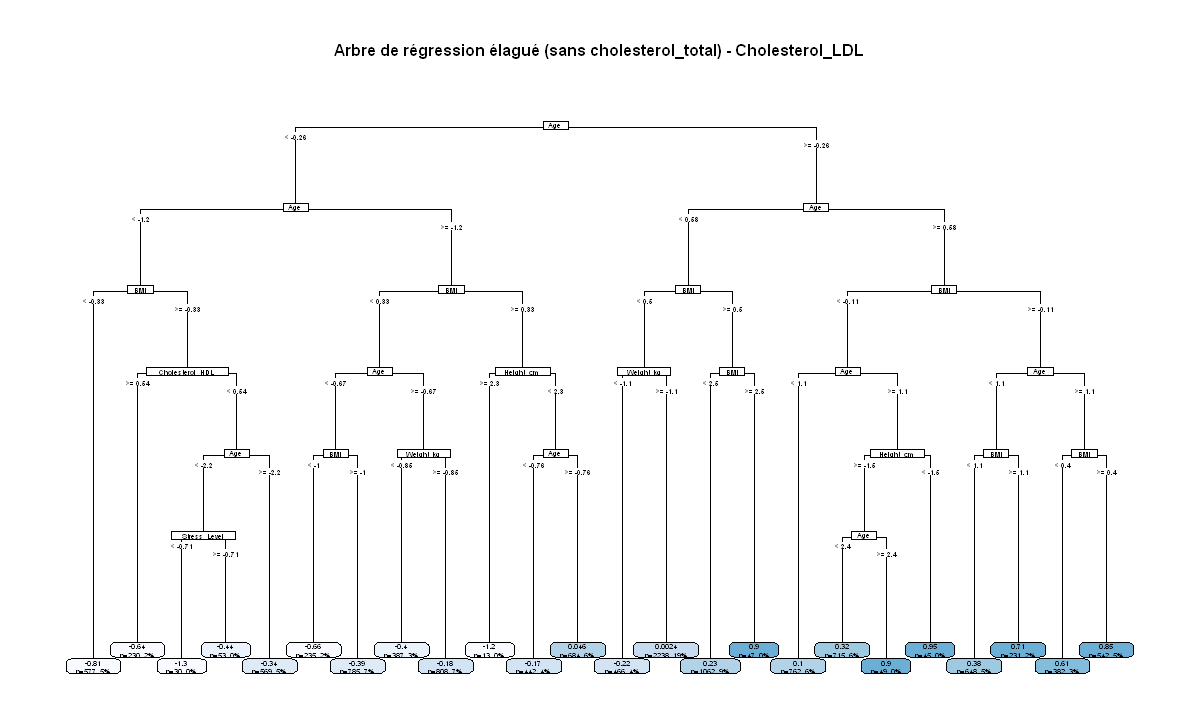

In [92]:
# Élagage par validation croisée (sans Cholesterol_Total)
# On minimise xerror (erreur CV estimée) pour sélectionner la taille de l'arbre.
opt_cp_reg <- tree.reg.full.v2$cptable[which.min(tree.reg.full.v2$cptable[, "xerror"]), "CP"]
cat("cp optimal :", opt_cp_reg, "\n")

tree.reg.v2 <- prune(tree.reg.full.v2, cp = opt_cp_reg)

cat("Nombre de feuilles :", sum(tree.reg.v2$frame$var == "<leaf>"), "\n")

# options(repr.plot.width = 18, repr.plot.height = 9) # 25 feuilles
rpart.plot(
  tree.reg.v2,
  type  = 5,
  extra = 101,
  main  = "Arbre de régression élagué (sans cholesterol_total) - Cholesterol_LDL"
)

cp optimal : 0.0008687105 
Nombre de feuilles : 21 


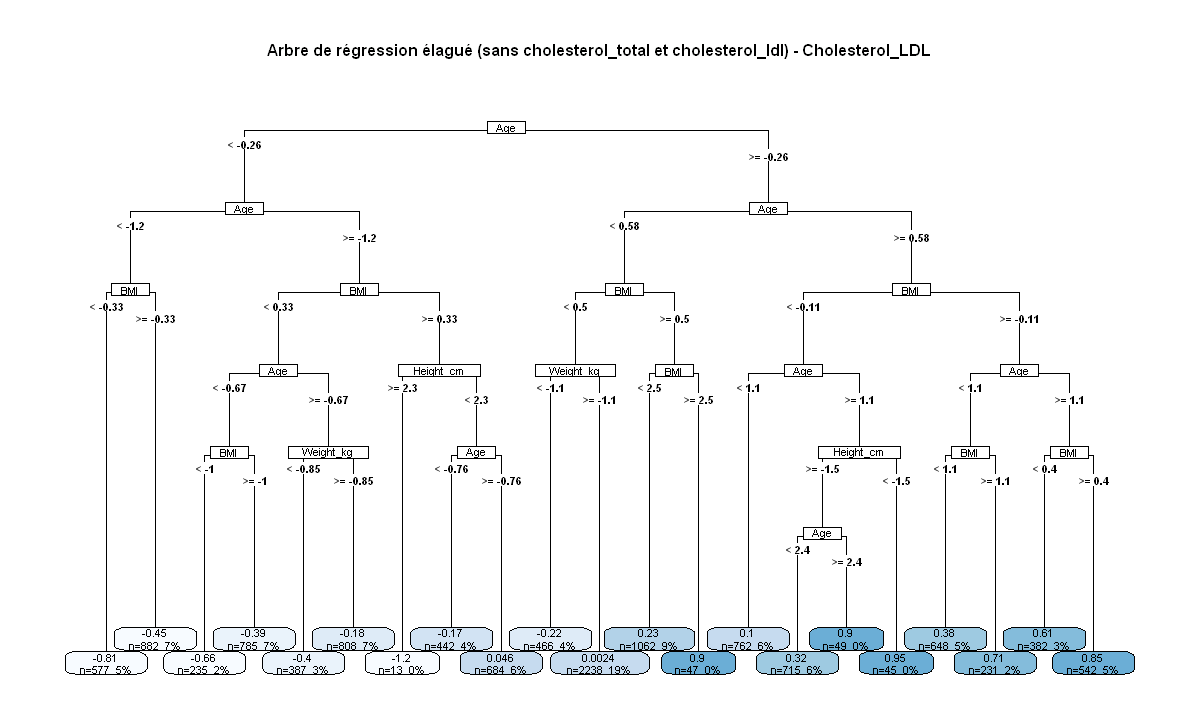

In [93]:
# Élagage par validation croisée (sans Cholesterol_Total et Cholesterol_LDL)
# On minimise xerror (erreur CV estimée) pour sélectionner la taille de l'arbre.
opt_cp_reg <- tree.reg.full.v3$cptable[which.min(tree.reg.full.v3$cptable[, "xerror"]), "CP"]
cat("cp optimal :", opt_cp_reg, "\n")

tree.reg.v3 <- prune(tree.reg.full.v3, cp = opt_cp_reg)

cat("Nombre de feuilles :", sum(tree.reg.v3$frame$var == "<leaf>"), "\n")

# options(repr.plot.width = 18, repr.plot.height = 9) # 25 feuilles
rpart.plot(
  tree.reg.v3,
  type  = 5,
  extra = 101,
  main  = "Arbre de régression élagué (sans cholesterol_total et cholesterol_ldl) - Cholesterol_LDL"
)

### 3.5.2 Évaluation sur l'échantillon test

In [94]:
# Prédictions et métriques 
pred_tree_reg_test <- predict(tree.reg, datestr)

rmse_tree_reg <- sqrt(mean((pred_tree_reg_test - datestr$Cholesterol_LDL)^2))
mae_tree_reg <- mean(abs(pred_tree_reg_test - datestr$Cholesterol_LDL))
ss_tot_reg    <- sum((datestr$Cholesterol_LDL - mean(datestr$Cholesterol_LDL))^2)
r2_tree_reg   <- 1 - sum((pred_tree_reg_test - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Avec cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_tree_reg))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_tree_reg))
cat(sprintf("R²   (test) : %.4f\n",        r2_tree_reg))

[1] "Avec cholesterol_total :"
RMSE (test) : 0.5620 mg/dL
MAE  (test) : 0.4469 mg/dL
R²   (test) : 0.6767


In [95]:
# Prédictions et métriques (sans cholesterol_total)
pred_tree_reg_test.v2 <- predict(tree.reg.v2, datestr)

rmse_tree_reg.v2 <- sqrt(mean((pred_tree_reg_test.v2 - datestr$Cholesterol_LDL)^2))
mae_tree_reg.v2  <- mean(abs(pred_tree_reg_test.v2 - datestr$Cholesterol_LDL))
ss_tot_reg.v2    <- sum((datestr$Cholesterol_LDL - mean(datestr$Cholesterol_LDL))^2)
r2_tree_reg.v2   <- 1 - sum((pred_tree_reg_test.v2 - datestr$Cholesterol_LDL)^2) / ss_tot_reg.v2

print("Sans cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_tree_reg.v2))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_tree_reg.v2))
cat(sprintf("R²   (test) : %.4f\n",        r2_tree_reg.v2))

[1] "Sans cholesterol_total :"
RMSE (test) : 0.9183 mg/dL
MAE  (test) : 0.7363 mg/dL
R²   (test) : 0.1367


In [96]:
# Prédictions et métriques (sans Cholesterol_total et sans Cholesterol_LDL)
pred_tree_reg_test.v3 <- predict(tree.reg.v3, datestr)

rmse_tree_reg.v3 <- sqrt(mean((pred_tree_reg_test.v3 - datestr$Cholesterol_LDL)^2))
mae_tree_reg.v3  <- mean(abs(pred_tree_reg_test.v3 - datestr$Cholesterol_LDL))
ss_tot_reg.v3    <- sum((datestr$Cholesterol_LDL - mean(datestr$Cholesterol_LDL))^2)
r2_tree_reg.v3   <- 1 - sum((pred_tree_reg_test.v3 - datestr$Cholesterol_LDL)^2) / ss_tot_reg.v3

print("Sans cholesterol_total et sans cholesterol_ldl :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_tree_reg.v3))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_tree_reg.v3))
cat(sprintf("R²   (test) : %.4f\n",        r2_tree_reg.v3))

[1] "Sans cholesterol_total et sans cholesterol_ldl :"
RMSE (test) : 0.9182 mg/dL
MAE  (test) : 0.7360 mg/dL
R²   (test) : 0.1369


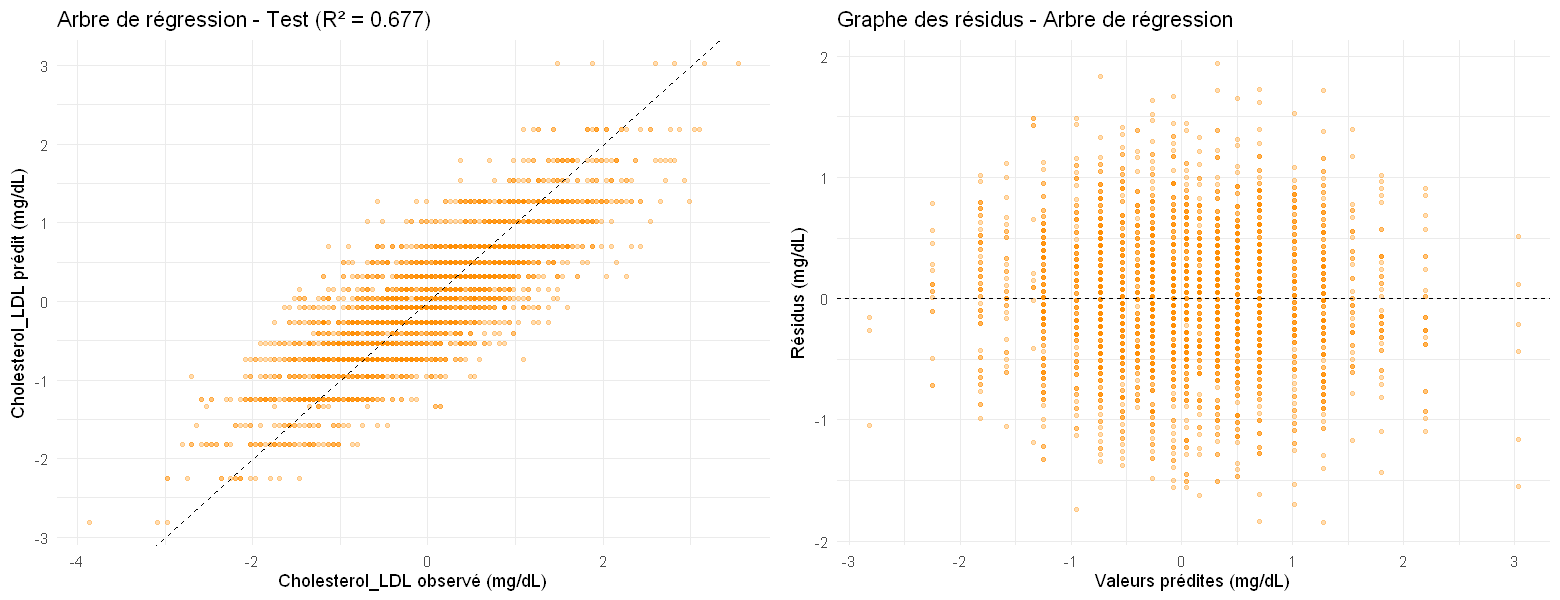

In [97]:
# Graphes valeurs prédites et résidus
df_tree_reg <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_tree_reg_test,
  residus  = datestr$Cholesterol_LDL - pred_tree_reg_test
)

p1 <- ggplot(df_tree_reg, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Arbre de régression - Test (R² = %.3f)", r2_tree_reg)) +
  theme_minimal()

p2 <- ggplot(df_tree_reg, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Arbre de régression") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

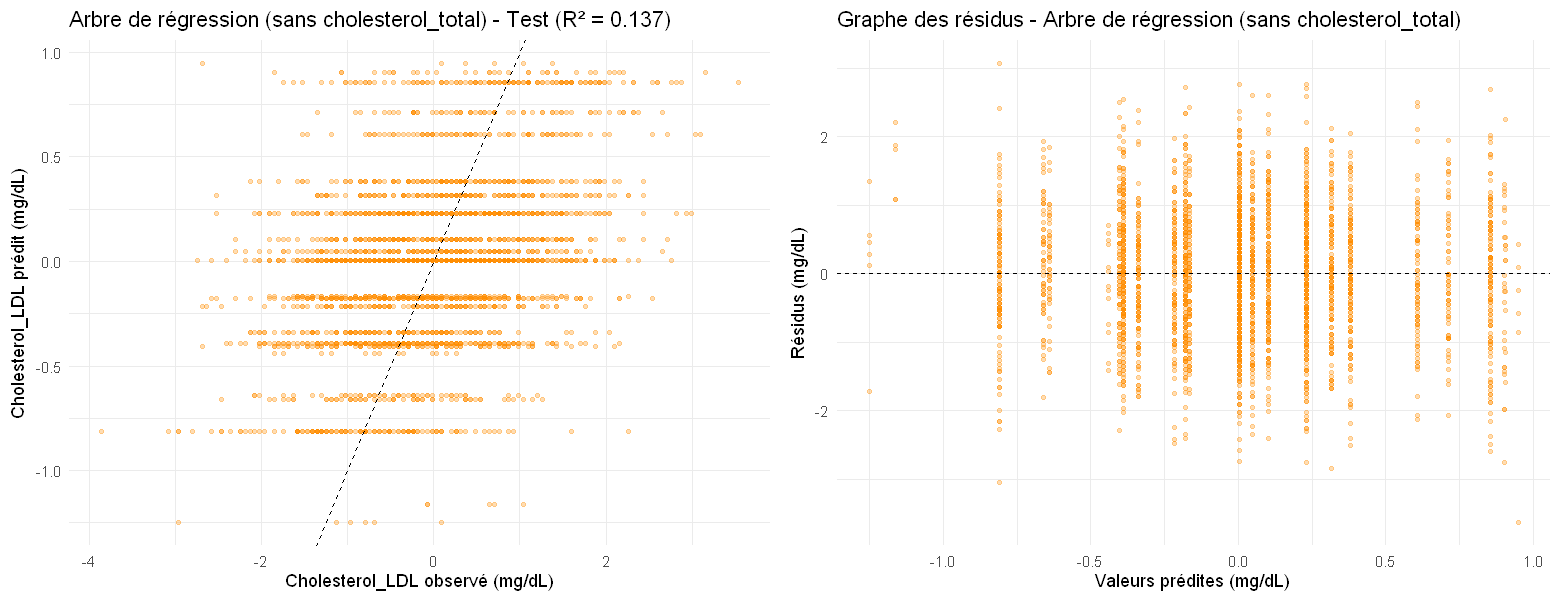

In [98]:
# Graphes valeurs prédites et résidus (sans cholesterol_total)
df_tree_reg.v2 <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_tree_reg_test.v2,
  residus  = datestr$Cholesterol_LDL - pred_tree_reg_test.v2
)

p1 <- ggplot(df_tree_reg.v2, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Arbre de régression (sans cholesterol_total) - Test (R² = %.3f)", r2_tree_reg.v2)) +
  theme_minimal()

p2 <- ggplot(df_tree_reg.v2, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Arbre de régression (sans cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

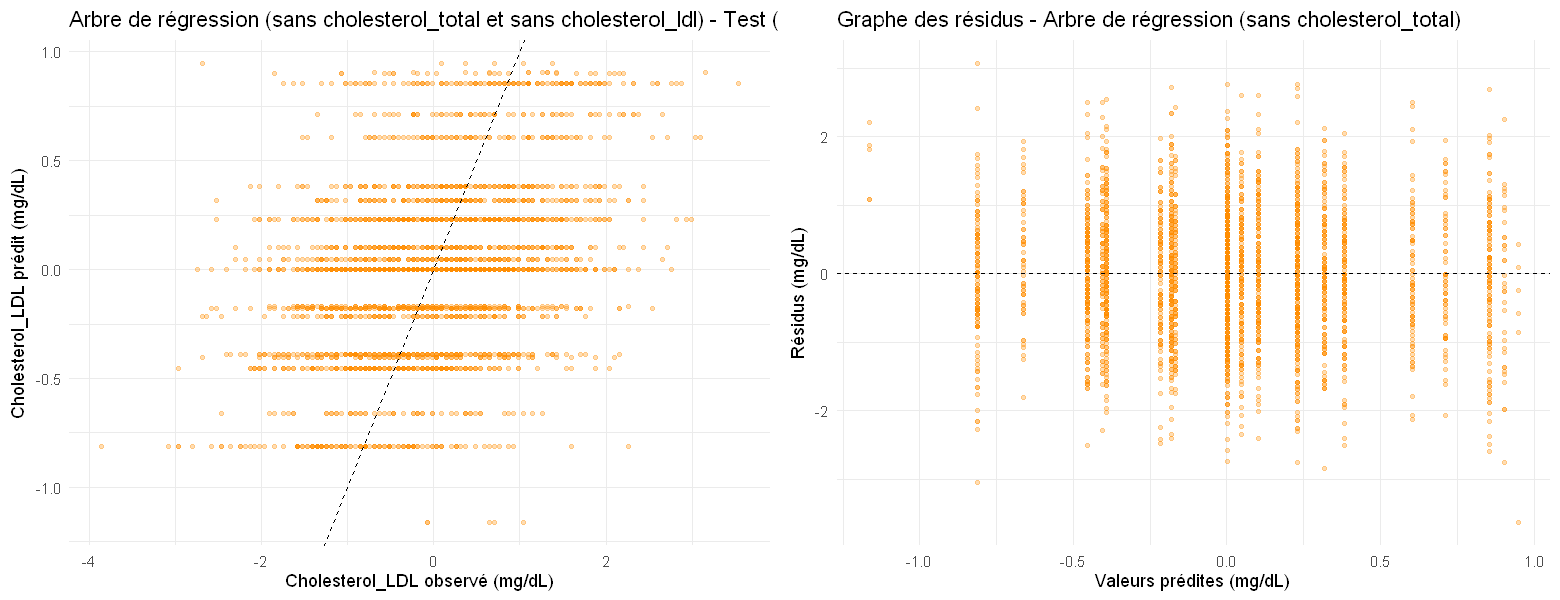

In [99]:
# Graphes valeurs prédites et résidus (sans cholesterol_total et sans cholesterol_ldl)
df_tree_reg.v3 <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_tree_reg_test.v3,
  residus  = datestr$Cholesterol_LDL - pred_tree_reg_test.v3
)

p1 <- ggplot(df_tree_reg.v3, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Arbre de régression (sans cholesterol_total et sans cholesterol_ldl) - Test (R² = %.3f)", r2_tree_reg.v3)) +
  theme_minimal()

p2 <- ggplot(df_tree_reg.v3, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "darkorange", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Arbre de régression (sans cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

### 3.5.3 Importance des variables

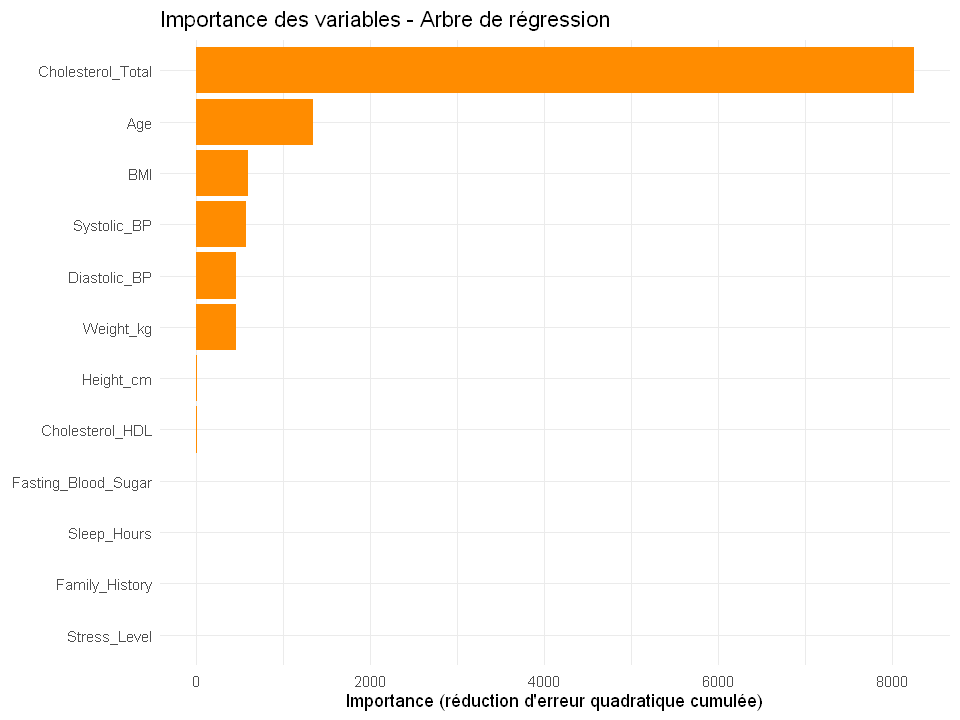

In [100]:
# Importance des variables (arbre de régression)
imp_reg <- tree.reg$variable.importance
imp_reg_df <- data.frame(
  variable   = names(imp_reg),
  importance = as.numeric(imp_reg)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_reg_df, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction d'erreur quadratique cumulée)",
       title = "Importance des variables - Arbre de régression") +
  theme_minimal()

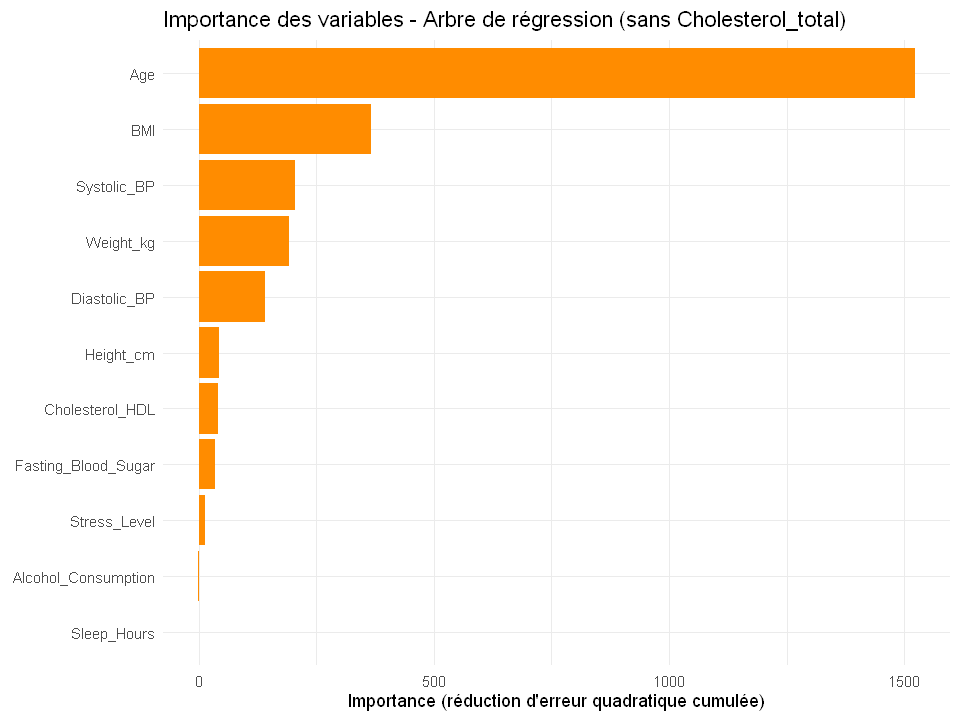

In [101]:
# Importance des variables (arbre de régression) (sans Cholesterol_total)
imp_reg.v2 <- tree.reg.v2$variable.importance
imp_reg_df.v2 <- data.frame(
  variable   = names(imp_reg.v2),
  importance = as.numeric(imp_reg.v2)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_reg_df.v2, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction d'erreur quadratique cumulée)",
       title = "Importance des variables - Arbre de régression (sans Cholesterol_total)") +
  theme_minimal()

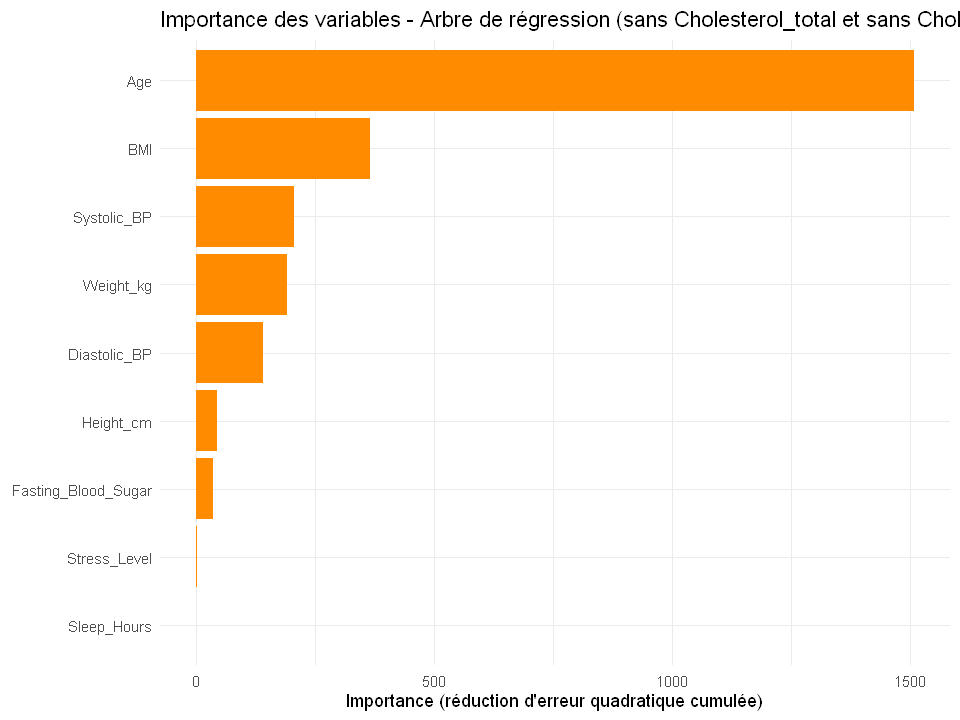

In [102]:
# Importance des variables (arbre de régression) (sans Cholesterol_total et sans Cholesterol_LDL)
imp_reg.v3 <- tree.reg.v3$variable.importance
imp_reg_df.v3 <- data.frame(
  variable   = names(imp_reg.v3),
  importance = as.numeric(imp_reg.v3)
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_reg_df.v3, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance (réduction d'erreur quadratique cumulée)",
       title = "Importance des variables - Arbre de régression (sans Cholesterol_total et sans Cholesterol_LDL)") +
  theme_minimal()

---
## 3.6 Prévision par forêt aléatoire - Régression (`Cholesterol_LDL`)

En régression, la forêt prédit la **moyenne** des prédictions des $B$ arbres. La recommandation pour $m$ est $p/3$.

### 3.6.1 Analyse de convergence et optimisation de `mtry`

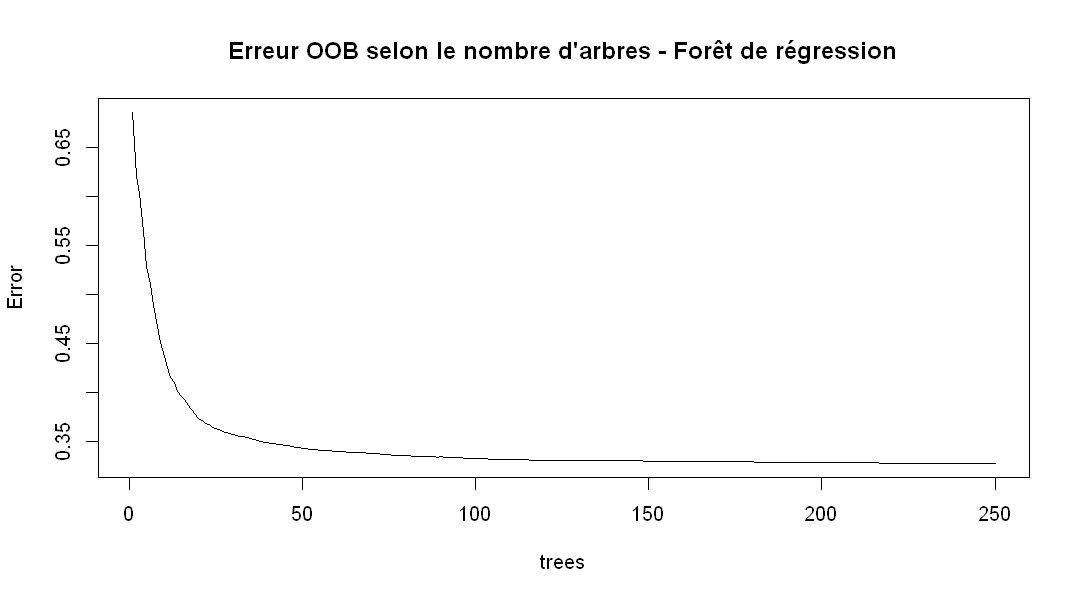

In [103]:
# Convergence de l'erreur OOB (régression)
set.seed(111)
rf.reg.conv <- randomForest(
  Cholesterol_LDL ~ .,
  data  = datappr,
  ntree = 250,
  mtry  = floor((ncol(datappr) - 1) / 3)  # p/3 : règle empirique régression
)

options(repr.plot.width = 9, repr.plot.height = 5)
plot(rf.reg.conv,
     main = "Erreur OOB selon le nombre d'arbres - Forêt de régression")

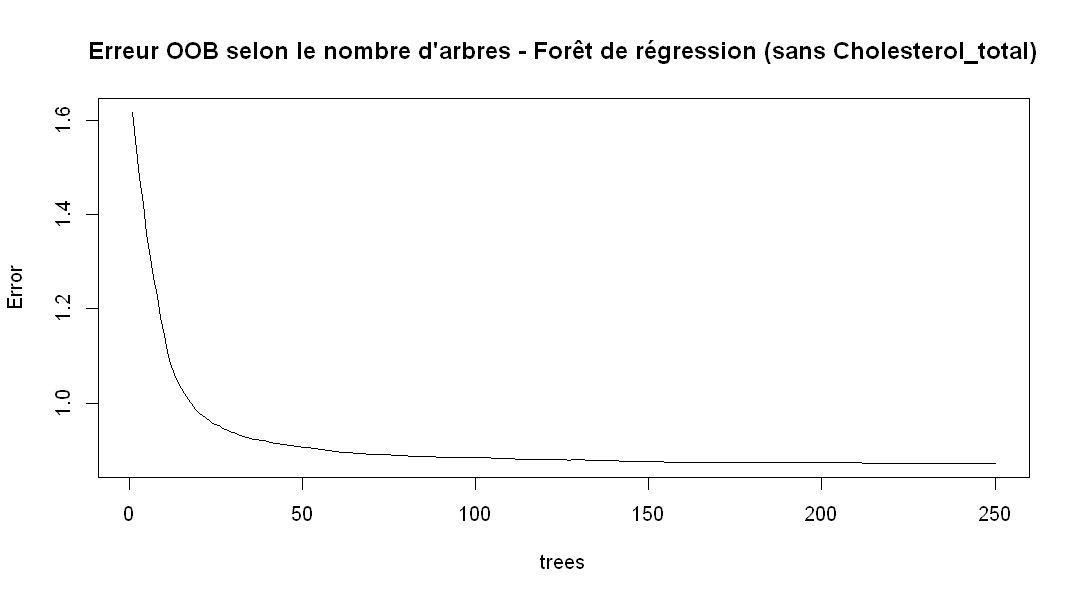

In [110]:
# Convergence de l'erreur OOB (régression) (sans Cholesterol_total)
set.seed(111)
rf.reg.conv.v2 <- randomForest(
  Cholesterol_LDL ~ .,
  data  = datappr.v2,
  ntree = 250,
  mtry  = floor((ncol(datappr.v2) - 1) / 3)  # p/3 : règle empirique régression
)

options(repr.plot.width = 9, repr.plot.height = 5)
plot(rf.reg.conv.v2,
     main = "Erreur OOB selon le nombre d'arbres - Forêt de régression (sans Cholesterol_total)")

  mtry   oob_mse
1    2 0.3904868
2    4 0.3395296
3    5 0.3339317
4    8 0.3294470
5   16 0.3332054

mtry optimal : 8  (MSE OOB = 0.3294)


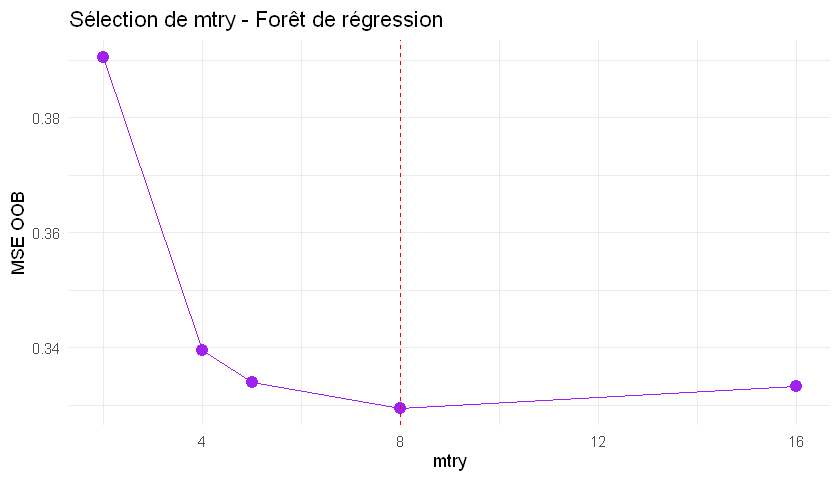

In [104]:
# Sélection de mtry par erreur OOB
set.seed(111)
p_reg <- ncol(datappr) - 1

mtry_vals_reg <- sort(unique(c(
  2,
  floor(p_reg / 3),    # p/3 : règle empirique régression
  floor(sqrt(p_reg)),
  floor(p_reg / 2),
  p_reg
)))

oob_mse_mtry <- sapply(mtry_vals_reg, function(m) {
  rf <- randomForest(Cholesterol_LDL ~ ., data = datappr, ntree = 100, mtry = m)
  tail(rf$mse, 1)  # MSE OOB finale
})

df_mtry_reg <- data.frame(mtry = mtry_vals_reg, oob_mse = oob_mse_mtry)
print(df_mtry_reg)

best_mtry_reg <- mtry_vals_reg[which.min(oob_mse_mtry)]
cat(sprintf("\nmtry optimal : %d  (MSE OOB = %.4f)\n",
            best_mtry_reg, min(oob_mse_mtry)))

options(repr.plot.width = 7, repr.plot.height = 4)
ggplot(df_mtry_reg, aes(x = mtry, y = oob_mse)) +
  geom_line(colour = "purple") + geom_point(colour = "purple", size = 3) +
  geom_vline(xintercept = best_mtry_reg, linetype = "dashed", colour = "red") +
  labs(x = "mtry", y = "MSE OOB",
       title = "Sélection de mtry - Forêt de régression") +
  theme_minimal()

  mtry   oob_mse
1    2 0.8828354
2    3 0.8834787
3    5 0.8843018
4    7 0.8950943
5   15 0.8971283

mtry optimal : 2  (MSE OOB = 0.8828)


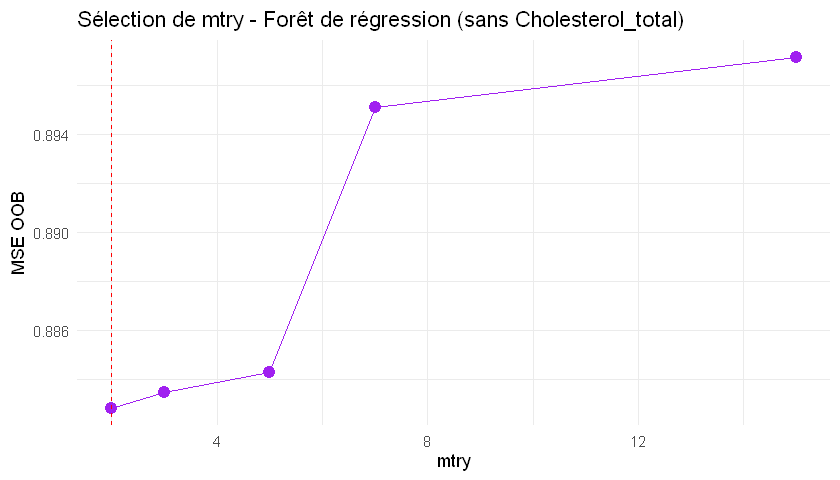

In [111]:
# Sélection de mtry par erreur OOB (régression) (sans Cholesterol_total)
set.seed(111)
p_reg <- ncol(datappr.v2) - 1

mtry_vals_reg.v2 <- sort(unique(c(
  2,
  floor(p_reg / 3),    # p/3 : règle empirique régression
  floor(sqrt(p_reg)),
  floor(p_reg / 2),
  p_reg
)))

oob_mse_mtry.v2 <- sapply(mtry_vals_reg.v2, function(m) {
  rf <- randomForest(Cholesterol_LDL ~ ., data = datappr.v2, ntree = 100, mtry = m)
  tail(rf$mse, 1)  # MSE OOB finale
})

df_mtry_reg.v2 <- data.frame(mtry = mtry_vals_reg.v2, oob_mse = oob_mse_mtry.v2)
print(df_mtry_reg.v2)

best_mtry_reg.v2 <- mtry_vals_reg.v2[which.min(oob_mse_mtry.v2)]
cat(sprintf("\nmtry optimal : %d  (MSE OOB = %.4f)\n",
            best_mtry_reg.v2, min(oob_mse_mtry.v2)))

options(repr.plot.width = 7, repr.plot.height = 4)
ggplot(df_mtry_reg.v2, aes(x = mtry, y = oob_mse)) +
  geom_line(colour = "purple") + geom_point(colour = "purple", size = 3) +
  geom_vline(xintercept = best_mtry_reg.v2, linetype = "dashed", colour = "red") +
  labs(x = "mtry", y = "MSE OOB",
       title = "Sélection de mtry - Forêt de régression (sans Cholesterol_total)") +
  theme_minimal()

In [112]:
# Modèle final (forêt de régression)
set.seed(111)
rf.reg <- randomForest(
  Cholesterol_LDL ~ .,
  data       = datappr,
  ntree      = 100,
  mtry       = best_mtry_reg,
  importance = TRUE
)

print("Avec Cholesterol_total :")

print(rf.reg)
cat(sprintf("R² OOB : %.4f\n", tail(rf.reg$rsq, 1)))

[1] "Avec Cholesterol_total :"

Call:
 randomForest(formula = Cholesterol_LDL ~ ., data = datappr, ntree = 100,      mtry = best_mtry_reg, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 100
No. of variables tried at each split: 8

          Mean of squared residuals: 0.3297619
                    % Var explained: 67.02
R² OOB : 0.6702


In [113]:
# Modèle final (forêt de régression) (sans Cholesterol_total)
set.seed(111)
rf.reg.v2 <- randomForest(
  Cholesterol_LDL ~ .,
  data       = datappr.v2,
  ntree      = 100,
  mtry       = best_mtry_reg.v2,
  importance = TRUE
)

print("Sans Cholesterol_total :")

print(rf.reg.v2)
cat(sprintf("R² OOB : %.4f\n", tail(rf.reg.v2$rsq, 1)))

[1] "Sans Cholesterol_total :"

Call:
 randomForest(formula = Cholesterol_LDL ~ ., data = datappr.v2,      ntree = 100, mtry = best_mtry_reg.v2, importance = TRUE) 
               Type of random forest: regression
                     Number of trees: 100
No. of variables tried at each split: 2

          Mean of squared residuals: 0.890647
                    % Var explained: 10.93
R² OOB : 0.1093


### 3.6.2 Évaluation sur l'échantillon test

In [114]:
# Prédictions test et métriques
pred_rf_reg_test <- predict(rf.reg, datestr)

rmse_rf_reg <- sqrt(mean((pred_rf_reg_test - datestr$Cholesterol_LDL)^2))
mae_rf_reg  <- mean(abs(pred_rf_reg_test - datestr$Cholesterol_LDL))
r2_rf_reg   <- 1 - sum((pred_rf_reg_test - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Avec Cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_rf_reg))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_rf_reg))
cat(sprintf("R²   (test) : %.4f\n",        r2_rf_reg))

[1] "Avec Cholesterol_total :"
RMSE (test) : 0.5661 mg/dL
MAE  (test) : 0.4504 mg/dL
R²   (test) : 0.6719


In [115]:
# Prédictions test et métriques (sans Cholesterol_total)
pred_rf_reg_test.v2 <- predict(rf.reg.v2, datestr)

rmse_rf_reg.v2 <- sqrt(mean((pred_rf_reg_test.v2 - datestr$Cholesterol_LDL)^2))
mae_rf_reg.v2  <- mean(abs(pred_rf_reg_test.v2 - datestr$Cholesterol_LDL))
r2_rf_reg.v2   <- 1 - sum((pred_rf_reg_test.v2 - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Sans Cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_rf_reg.v2))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_rf_reg.v2))
cat(sprintf("R²   (test) : %.4f\n",        r2_rf_reg.v2))

[1] "Sans Cholesterol_total :"
RMSE (test) : 0.9228 mg/dL
MAE  (test) : 0.7403 mg/dL
R²   (test) : 0.1283


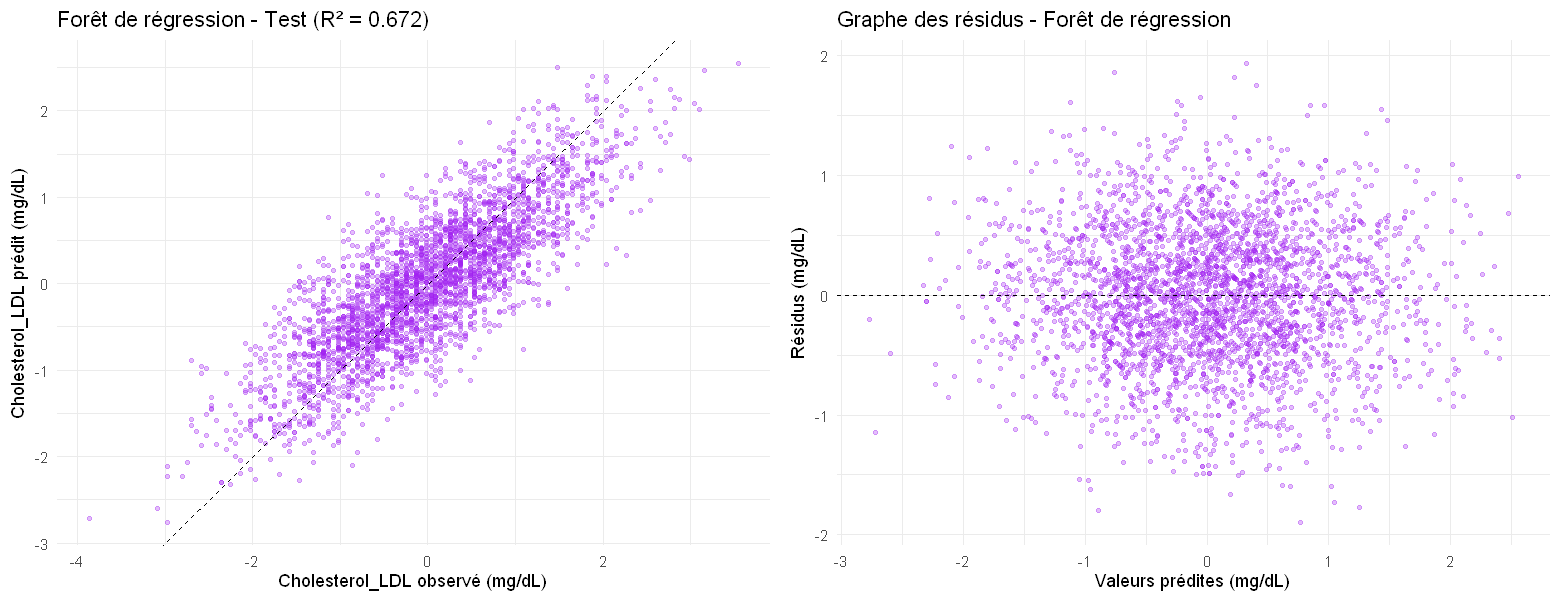

In [116]:
# Graphes valeurs prédites et résidus
df_rf_reg <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_rf_reg_test,
  residus  = datestr$Cholesterol_LDL - pred_rf_reg_test
)

p3 <- ggplot(df_rf_reg, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Forêt de régression - Test (R² = %.3f)", r2_rf_reg)) +
  theme_minimal()

p4 <- ggplot(df_rf_reg, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Forêt de régression") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p3, p4, ncol = 2)

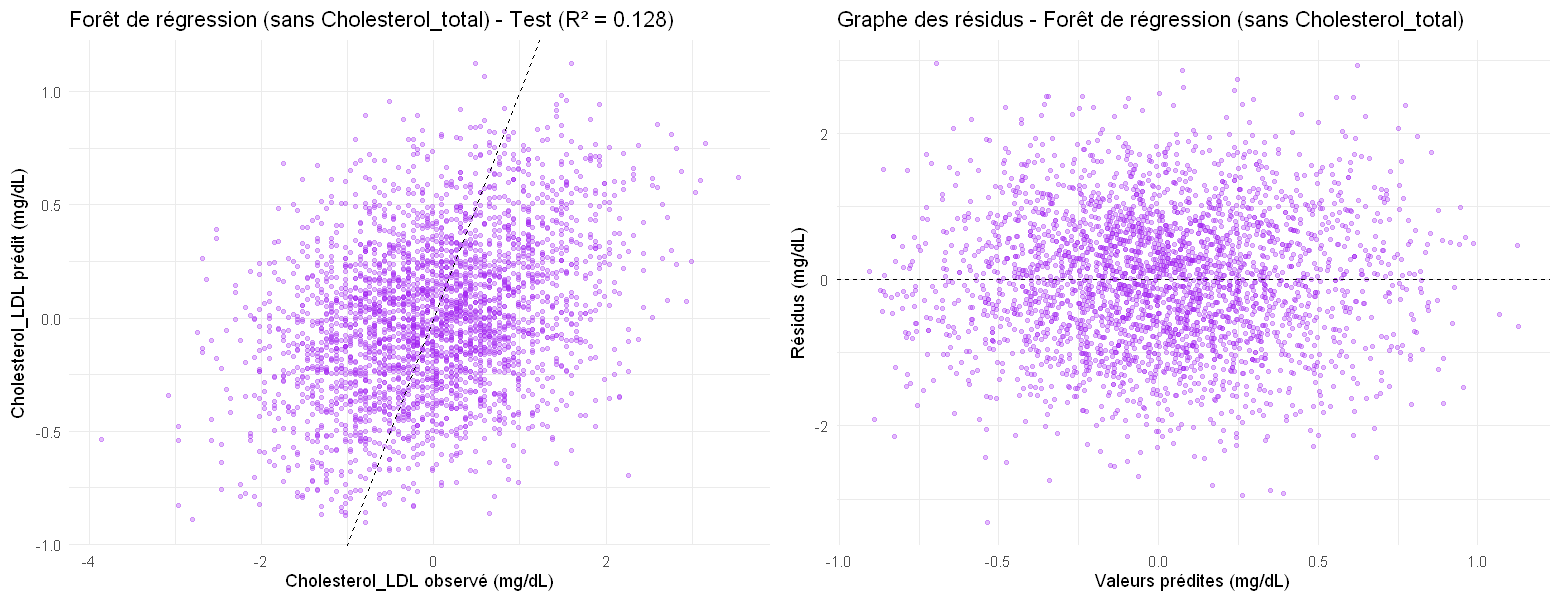

In [117]:
# Graphes valeurs prédites et résidus (sans Cholesterol_total)
df_rf_reg.v2 <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_rf_reg_test.v2,
  residus  = datestr$Cholesterol_LDL - pred_rf_reg_test.v2
)

p3 <- ggplot(df_rf_reg.v2, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Forêt de régression (sans Cholesterol_total) - Test (R² = %.3f)", r2_rf_reg.v2)) +
  theme_minimal()

p4 <- ggplot(df_rf_reg.v2, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "purple", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Forêt de régression (sans Cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p3, p4, ncol = 2)

### 3.6.3 Importance des variables

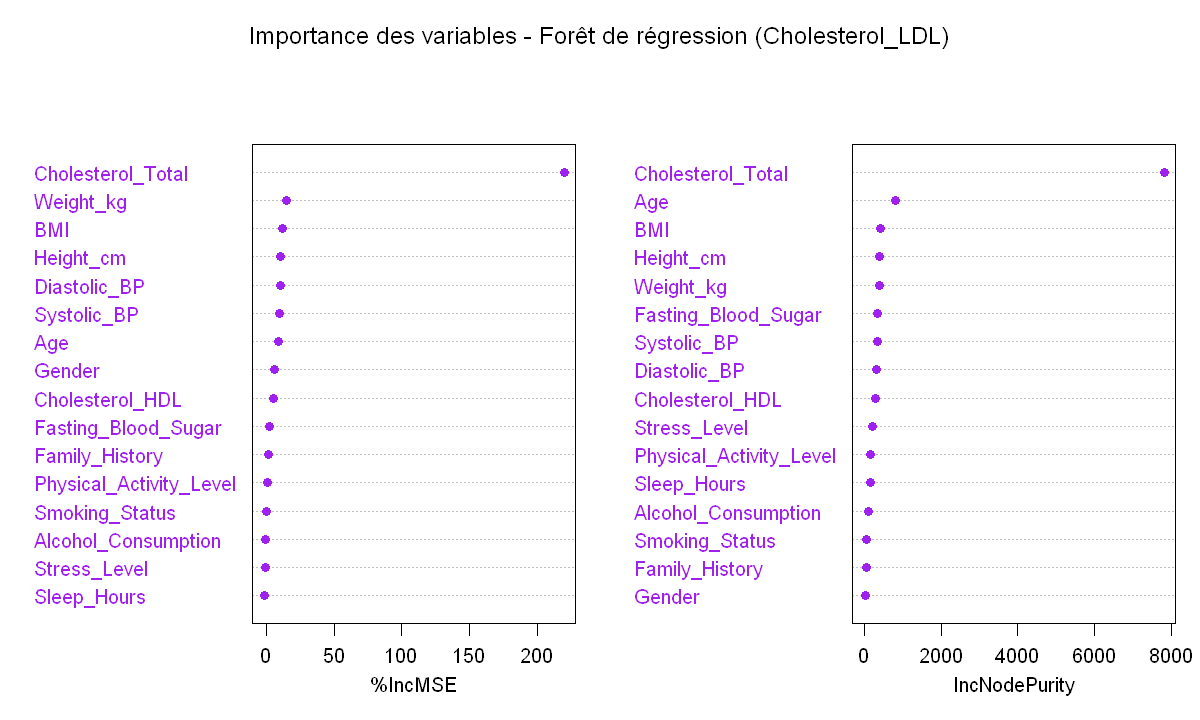

In [118]:
# Graphe d'importance des variables (forêt de régression)
options(repr.plot.width = 10, repr.plot.height = 6)
varImpPlot(
  rf.reg,
  main = "Importance des variables - Forêt de régression (Cholesterol_LDL)",
  col  = "purple",
  pch  = 16
)

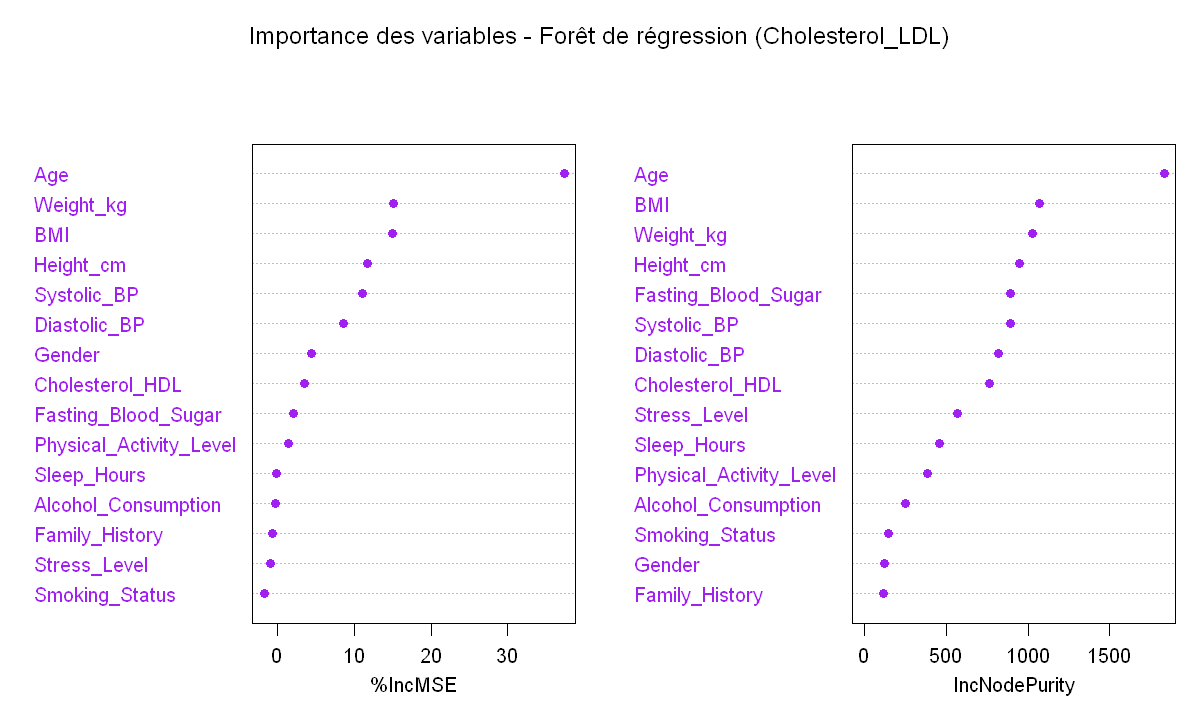

In [119]:
# Graphe d'importance des variables (forêt de régression) (sans Cholesterol_total)
options(repr.plot.width = 10, repr.plot.height = 6)
varImpPlot(
  rf.reg.v2,
  main = "Importance des variables - Forêt de régression (Cholesterol_LDL)",
  col  = "purple",
  pch  = 16
)

### 3.6.4 Bilan - Régression (`Cholesterol_LDL`)

In [125]:
# Tableau récapitulatif (régression)
resultats_reg <- data.frame(
  Modele = c("Arbre CART (élagué)", "Arbre CART (élagué) (sans CT)", "Arbre CART (élagué) (sans CT+HDL)", "Forêt aléatoire", "Forêt aléatoire (sans CT)"),
  RMSE   = round(c(rmse_tree_reg, rmse_tree_reg.v2, rmse_tree_reg.v3, rmse_rf_reg, rmse_rf_reg.v2), 4),
  MAE    = round(c(mae_tree_reg,  mae_tree_reg.v2, mae_tree_reg.v3, mae_rf_reg, mae_rf_reg.v2),  4),
  R2     = round(c(r2_tree_reg,   r2_tree_reg.v2, r2_tree_reg.v3, r2_rf_reg, r2_rf_reg.v2),   4)
)
print(resultats_reg)

                             Modele   RMSE    MAE     R2
1               Arbre CART (élagué) 0.5620 0.4469 0.6767
2     Arbre CART (élagué) (sans CT) 0.9183 0.7363 0.1367
3 Arbre CART (élagué) (sans CT+HDL) 0.9182 0.7360 0.1369
4                   Forêt aléatoire 0.5661 0.4504 0.6719
5         Forêt aléatoire (sans CT) 0.9228 0.7403 0.1283


---
## Synthèse : Arbres et Forêts aléatoires

In [126]:
# Synthèse finale
cat("=== DISCRIMINATION - Heart_Disease_Risk ===\n")
print(resultats_dis)
cat("\n=== RÉGRESSION - Cholesterol_LDL ===\n")
print(resultats_reg)

cat("\nPoints-clés :\n",
    "- Arbre CART : interprétable (règles lisibles), mais sensible au bruit.\n",
    "  => L'élagage par validation croisée (cp optimal) est indispensable.\n",
    "- Forêt aléatoire : réduit la variance par bagging + tirage aléatoire\n",
    "  des variables à chaque nœud. Plus performante, moins interprétable.\n",
    "- L'importance des variables est cohérente avec l'analyse exploratoire\n",
    "  (ACP, corrélations) réalisée en début de notebook.\n")

=== DISCRIMINATION - Heart_Disease_Risk ===
                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2700   0.7300 0.7660
3              Forêt aléatoire 0.2660   0.7340 0.7886

=== RÉGRESSION - Cholesterol_LDL ===
                             Modele   RMSE    MAE     R2
1               Arbre CART (élagué) 0.5620 0.4469 0.6767
2     Arbre CART (élagué) (sans CT) 0.9183 0.7363 0.1367
3 Arbre CART (élagué) (sans CT+HDL) 0.9182 0.7360 0.1369
4                   Forêt aléatoire 0.5661 0.4504 0.6719
5         Forêt aléatoire (sans CT) 0.9228 0.7403 0.1283

Points-clés :
 - Arbre CART : interprétable (règles lisibles), mais sensible au bruit.
   => L'élagage par validation croisée (cp optimal) est indispensable.
 - Forêt aléatoire : réduit la variance par bagging + tirage aléatoire
   des variables à chaque nœud. Plus performante, moins interprétable.
 - L'importance des variables est cohérente avec l'analyse 

---
# Partie 4 — Prévision par Boosting

Le **boosting** est une méthode d'ensemble qui construit les arbres **séquentiellement** : chaque nouvel arbre corrige les erreurs du modèle précédent. Contrairement aux forêts (arbres indépendants en parallèle), le boosting réduit principalement le **biais**.

On utilise la librairie **`gbm`** (*Gradient Boosting Machines*), qui implémente le **gradient boosting** de Friedman (2001).

**Hyperparamètres principaux :**
- `n.trees` : nombre d'arbres $B$ — sélectionné par **validation croisée interne** (`cv.folds`)
- `shrinkage` : taux d'apprentissage $\lambda$ (typiquement entre 0.01 et 0.1) — plus il est petit, plus il faut d'arbres
- `interaction.depth` : profondeur maximale de chaque arbre individuel (captures des interactions entre variables)
- `n.minobsinnode` : taille minimale d'un nœud terminal (régularisation)

> **Note :** Shrinkage faible + grand `n.trees` donnent généralement de meilleures performances, au prix d'un temps de calcul plus élevé. La validation croisée interne permet de choisir automatiquement `n.trees` pour chaque combinaison d'hyperparamètres.

In [128]:
# Librairie pour le gradient boosting
library(gbm)

Warning message:
"le package 'gbm' a été compilé avec la version R 4.4.3"
Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3



## 4.1 Boosting — Discrimination (`Heart_Disease_Risk`)

Pour la classification binaire, `gbm` utilise par défaut la **déviance de Bernoulli** comme fonction de perte (`distribution = "bernoulli"`). Le modèle produit des scores (log-odds) qu'on transforme en probabilités via la fonction logistique.

### 4.1.1 Estimation du modèle et sélection du nombre d'arbres

On utilise la **validation croisée interne** de `gbm` (`cv.folds = 5`) pour estimer le nombre optimal d'arbres et éviter le sur-apprentissage.

In [130]:
# on transforme les variables de risque cardiaque en numérique (0 et 1) pour le GBM (as.factor --> {0,1})
datappq_boosting <- datappq
datestq_boosting <- datestq

# (on passe par as.character pour être sûr que le texte "0" devient le chiffre 0, et "1" devient 1)
datappq_boosting$Heart_Disease_Risk <- as.numeric(as.character(datappq_boosting$Heart_Disease_Risk))
datestq_boosting$Heart_Disease_Risk <- as.numeric(as.character(datestq_boosting$Heart_Disease_Risk))

Nombre optimal d'arbres (CV) : 271


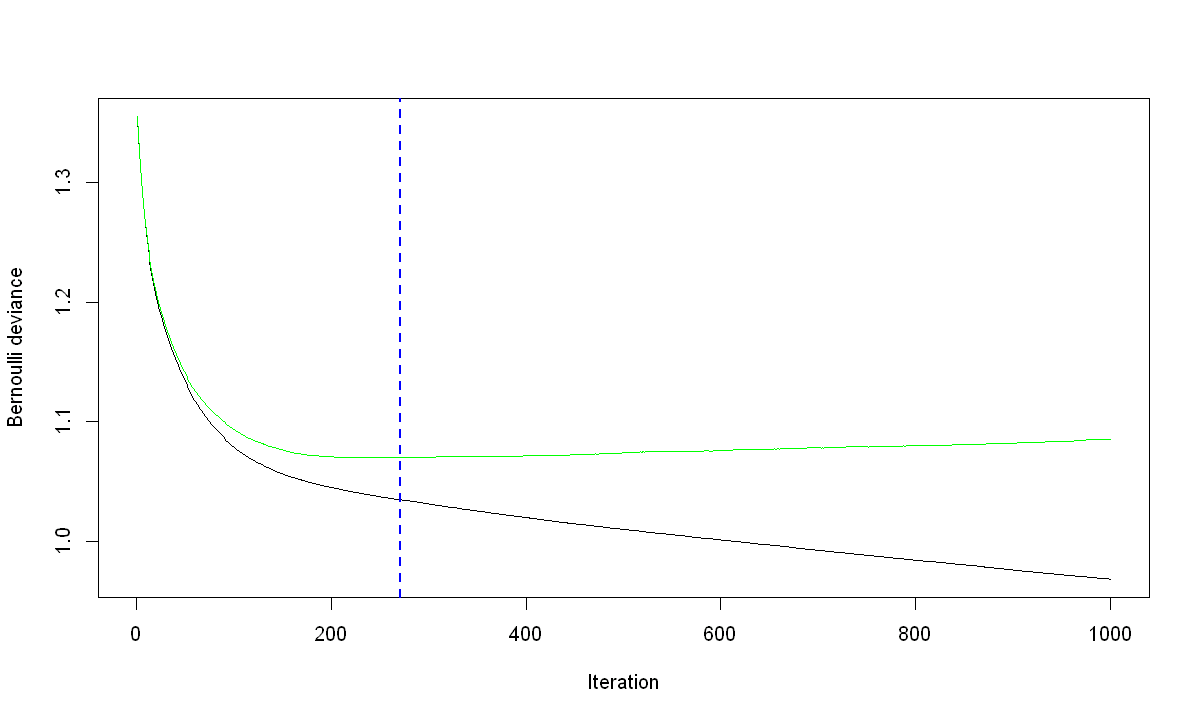

In [ ]:
# -- Estimation du modèle de boosting (discrimination) ------------------------
# distribution="bernoulli" : perte de Bernoulli pour la classification binaire
# cv.folds=5 : validation croisée interne pour choisir n.trees
# shrinkage=0.05 : taux d'apprentissage modéré
# interaction.depth=3 : arbres de profondeur 3 (captures les interactions d'ordre 3)
# n.minobsinnode=10 : régularisation minimale des feuilles
set.seed(111)
boost.dis <- gbm(
  Heart_Disease_Risk ~ .,
  data              = datappq_boosting,
  distribution      = "bernoulli",
  n.trees           = 1000,
  interaction.depth = 3,
  shrinkage         = 0.05,
  n.minobsinnode    = 10,
  cv.folds          = 5,
  verbose           = FALSE
)

# Nombre optimal d'arbres selon la CV (minimise la déviance CV)
best_iter_dis <- gbm.perf(boost.dis, method = "cv", plot.it = TRUE)
cat(sprintf("Nombre optimal d'arbres (CV) : %d\n", best_iter_dis))

### 4.1.2 Optimisation des hyperparamètres

On effectue une recherche sur grille (*grid search*) pour les hyperparamètres clés : `interaction.depth` et `shrinkage`. Pour chaque combinaison, on relit le nombre optimal d'arbres par CV.

In [132]:
# IL FAUDRAIT PAS METTRE N.TREES = 271 quelque part

# Grid search sur interaction.depth et shrinkage
# On teste des combinaisons de profondeur et de taux d'apprentissage.
# Pour chaque combinaison, gbm sélectionne automatiquement n.trees par CV.
set.seed(111)

depths    <- c(1, 3, 5)        # profondeur des arbres individuels
shrink    <- c(0.01, 0.05, 0.1)  # taux d'apprentissage

grid_dis <- expand.grid(depth = depths, shrinkage = shrink)
grid_dis$n_trees_opt <- NA
grid_dis$cv_error    <- NA

for (i in seq_len(nrow(grid_dis))) {
  d <- grid_dis$depth[i]
  s <- grid_dis$shrinkage[i]

  # n.trees plus grand quand le taux d'apprentissage est petit
  ntrees_max <- ifelse(s <= 0.01, 3000, ifelse(s <= 0.05, 1500, 800))

  fit <- gbm(
    Heart_Disease_Risk ~ .,
    data              = datappq_boosting,
    distribution      = "bernoulli",
    n.trees           = ntrees_max,
    interaction.depth = d,
    shrinkage         = s,
    n.minobsinnode    = 10,
    cv.folds          = 5,
    verbose           = FALSE
  )
  best_n          <- gbm.perf(fit, method = "cv", plot.it = FALSE)
  grid_dis$n_trees_opt[i] <- best_n
  grid_dis$cv_error[i]    <- fit$cv.error[best_n]
}

print(grid_dis[order(grid_dis$cv_error), ])

# Meilleure combinaison
best_row_dis <- which.min(grid_dis$cv_error)
cat(sprintf("\nMeilleure configuration :\n"))
cat(sprintf("  interaction.depth = %d\n",    grid_dis$depth[best_row_dis]))
cat(sprintf("  shrinkage         = %.2f\n",  grid_dis$shrinkage[best_row_dis]))
cat(sprintf("  n.trees optimal   = %d\n",    grid_dis$n_trees_opt[best_row_dis]))

  depth shrinkage n_trees_opt cv_error
7     1      0.10         272 1.064035
1     1      0.01        2902 1.065096
4     1      0.05         526 1.065319
5     3      0.05         300 1.067942
2     3      0.01        1526 1.068334
3     5      0.01        1029 1.069922
8     3      0.10         106 1.071056
6     5      0.05         187 1.073357
9     5      0.10          77 1.074084

Meilleure configuration :
  interaction.depth = 1
  shrinkage         = 0.10
  n.trees optimal   = 272


In [146]:
# Modèle final de boosting (discrimination)
set.seed(111)
boost.dis.final <- gbm(
  Heart_Disease_Risk ~ .,
  data              = datappq_boosting,
  distribution      = "bernoulli",
  n.trees           = grid_dis$n_trees_opt[best_row_dis],
  interaction.depth = grid_dis$depth[best_row_dis],
  shrinkage         = grid_dis$shrinkage[best_row_dis],
  n.minobsinnode    = 10,
  verbose           = FALSE
)

cat("Modèle de boosting final entraîné.\n")
print(boost.dis.final)

Modèle de boosting final entraîné.
gbm(formula = Heart_Disease_Risk ~ ., distribution = "bernoulli", 
    data = datappq_boosting, n.trees = grid_dis$n_trees_opt[best_row_dis], 
    interaction.depth = grid_dis$depth[best_row_dis], n.minobsinnode = 10, 
    shrinkage = grid_dis$shrinkage[best_row_dis], verbose = FALSE)
A gradient boosted model with bernoulli loss function.
272 iterations were performed.
There were 17 predictors of which 16 had non-zero influence.


### 4.1.3 Évaluation sur l'échantillon test

In [134]:
# Prédictions sur le test
# type="response" : renvoie directement des probabilités (après transformation logistique)
prob_boost_dis_test <- predict(
  boost.dis.final, datestq_boosting,
  n.trees = grid_dis$n_trees_opt[best_row_dis],
  type    = "response"
)

# Seuil de classification à 0.5
pred_boost_dis_test <- ifelse(prob_boost_dis_test >= 0.5, 1, 0)

err_boost_dis <- mean(pred_boost_dis_test != datestq$Heart_Disease_Risk)
cat(sprintf("Taux d'erreur test — Boosting : %.4f  (accuracy = %.4f)\n",
            err_boost_dis, 1 - err_boost_dis))

cat("\nMatrice de confusion (Boosting) :\n")
print(table(Prédit = pred_boost_dis_test, Observé = datestq_boosting$Heart_Disease_Risk))

roc_boost_dis <- roc(datestq$Heart_Disease_Risk, prob_boost_dis_test, quiet = TRUE)
cat(sprintf("AUC — Boosting : %.4f\n", auc(roc_boost_dis)))

Taux d'erreur test — Boosting : 0.2567  (accuracy = 0.7433)

Matrice de confusion (Boosting) :
      Observé
Prédit    0    1
     0 1394  444
     1  326  836
AUC — Boosting : 0.8059


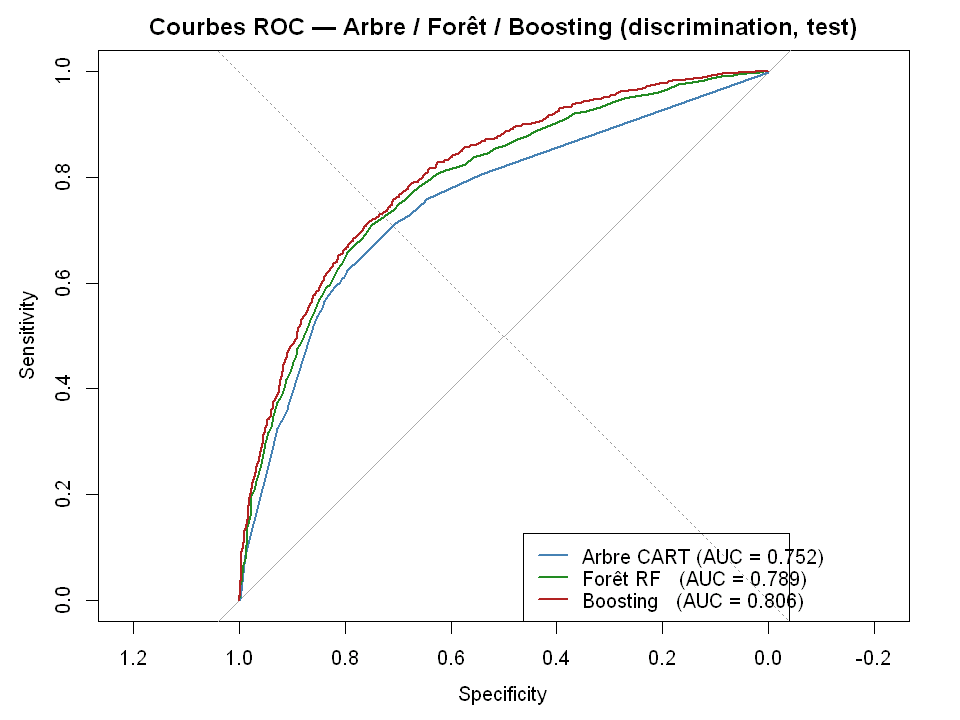

In [135]:
# Courbe ROC : Arbre vs Forêt vs Boosting
options(repr.plot.width = 8, repr.plot.height = 6)
plot(roc_gini,       col = "steelblue",   lwd = 2,
     main = "Courbes ROC — Arbre / Forêt / Boosting (discrimination, test)")
lines(roc_rf_dis,    col = "forestgreen", lwd = 2)
lines(roc_boost_dis, col = "firebrick",   lwd = 2)
abline(a = 0, b = 1, lty = 3, col = "grey60")
legend("bottomright",
       legend = c(sprintf("Arbre CART (AUC = %.3f)", auc(roc_gini)),
                  sprintf("Forêt RF   (AUC = %.3f)", auc(roc_rf_dis)),
                  sprintf("Boosting   (AUC = %.3f)", auc(roc_boost_dis))),
       col = c("steelblue", "forestgreen", "firebrick"), lwd = 2)

### 4.1.4 Importance des variables (boosting discrimination)

Dans `gbm`, l'importance d'une variable est la **réduction totale de la fonction de perte** qu'elle génère, moyennée sur tous les arbres.

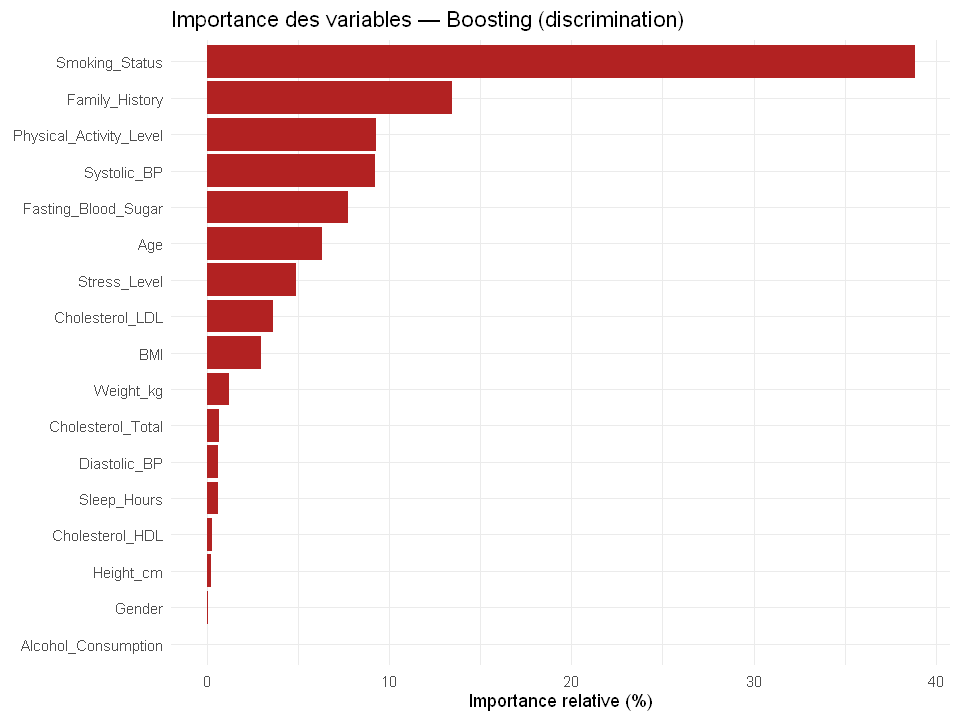

In [136]:
# Importance des variables
imp_boost_dis <- summary(
  boost.dis.final,
  n.trees    = grid_dis$n_trees_opt[best_row_dis],
  plotit     = FALSE
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_boost_dis, aes(x = reorder(var, rel.inf), y = rel.inf)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance relative (%)",
       title = "Importance des variables — Boosting (discrimination)") +
  theme_minimal()

### 4.1.5 Bilan - Discrimination (`Heart_Disease_Risk`)

In [137]:
# Tableau récapitulatif mis à jour (discrimination)
resultats_dis_complet <- data.frame(
  Modele   = c("Arbre CART Gini (élagué)",
               "Arbre CART Entropie (élagué)",
               "Forêt aléatoire",
               "Boosting (gbm)"),
  Erreur   = round(c(err_gini_test, err_ent_test, err_rf_dis, err_boost_dis), 4),
  Accuracy = round(1 - c(err_gini_test, err_ent_test, err_rf_dis, err_boost_dis), 4),
  AUC      = round(c(as.numeric(auc(roc_gini)),
                     as.numeric(auc(roc_ent)),
                     as.numeric(auc(roc_rf_dis)),
                     as.numeric(auc(roc_boost_dis))), 4)
)
print(resultats_dis_complet)

                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2700   0.7300 0.7660
3              Forêt aléatoire 0.2660   0.7340 0.7886
4               Boosting (gbm) 0.2567   0.7433 0.8059


---
## 4.2 Boosting — Régression (`Cholesterol_LDL`)

Pour la régression, `gbm` utilise la **déviance gaussienne** (erreur quadratique) comme fonction de perte (`distribution = "gaussian"`). Le modèle ajuste chaque arbre sur les **résidus** du modèle précédent.

### 4.2.1 Estimation et sélection du nombre d'arbres

Nombre optimal d'arbres (CV) : 117


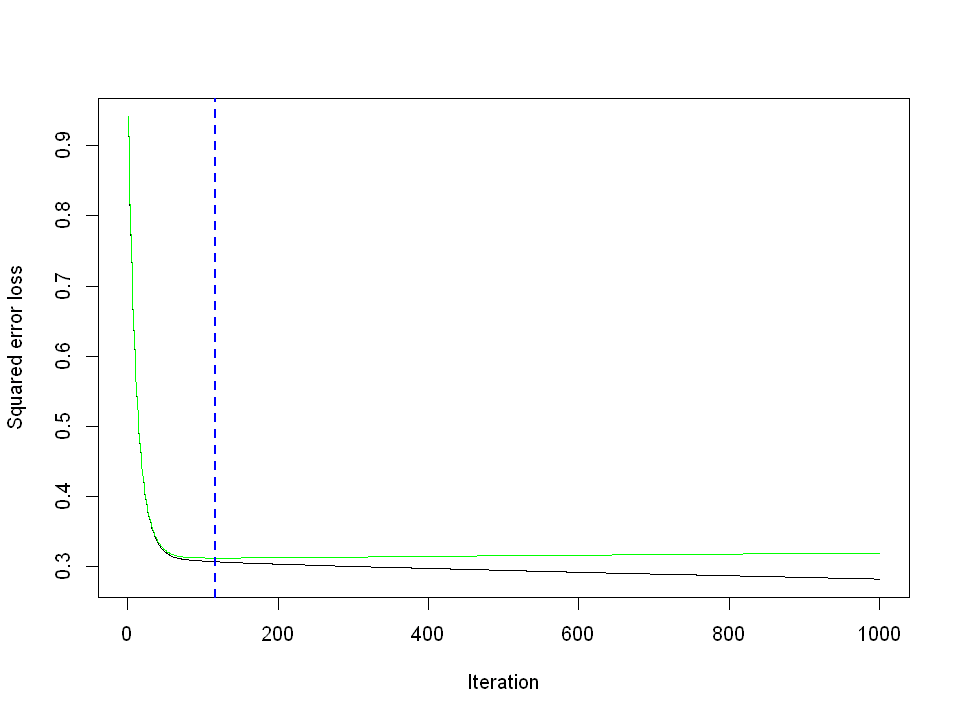

In [ ]:
# Estimation du modèle de boosting (régression)
# distribution="gaussian" : minimisation de l'erreur quadratique (régression)
set.seed(111)
boost.reg <- gbm(
  Cholesterol_LDL ~ .,
  data              = datappr,
  distribution      = "gaussian",
  n.trees           = 1000,
  interaction.depth = 3,
  shrinkage         = 0.05,
  n.minobsinnode    = 10,
  cv.folds          = 5,
  verbose           = FALSE
)

best_iter_reg <- gbm.perf(boost.reg, method = "cv", plot.it = TRUE)
cat(sprintf("Nombre optimal d'arbres (CV) : %d\n", best_iter_reg))

Nombre optimal d'arbres (sans Cholesterol_total) CV) : 133


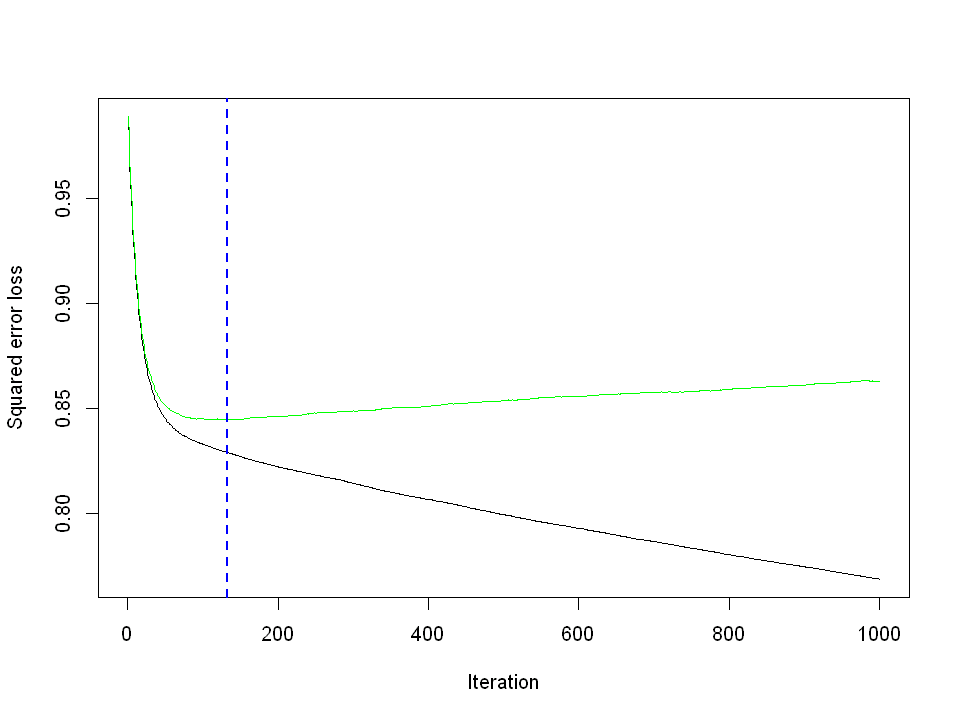

In [147]:
# Estimation du modèle de boosting (régression) (sans Cholesterol_total)
# distribution="gaussian" : minimisation de l'erreur quadratique (régression)
set.seed(111)
boost.reg.v2 <- gbm(
  Cholesterol_LDL ~ .,
  data              = datappr.v2,
  distribution      = "gaussian",
  n.trees           = 1000,
  interaction.depth = 3,
  shrinkage         = 0.05,
  n.minobsinnode    = 10,
  cv.folds          = 5,
  verbose           = FALSE
)

best_iter_reg <- gbm.perf(boost.reg.v2, method = "cv", plot.it = TRUE)
cat(sprintf("Nombre optimal d'arbres (sans Cholesterol_total) CV) : %d\n", best_iter_reg))

Nombre optimal d'arbres (sans Cholesterol_total et sans Cholesterol_LDL) CV) : 103


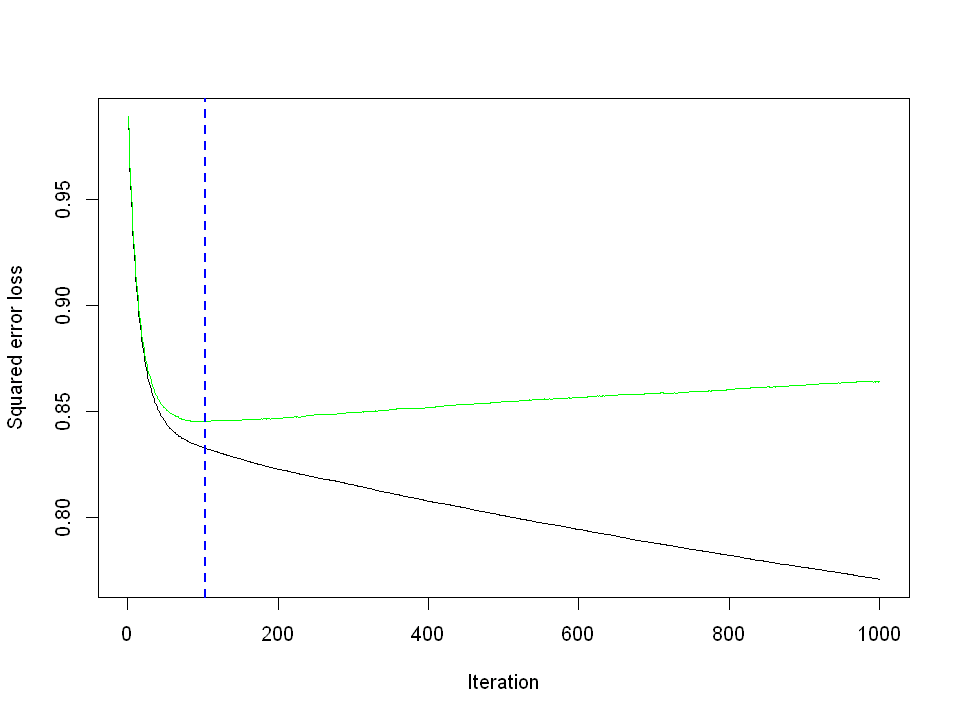

In [148]:
# Estimation du modèle de boosting (régression) (sans Cholesterol_total et sans Cholesterol_LDL)
# distribution="gaussian" : minimisation de l'erreur quadratique (régression)
set.seed(111)
boost.reg.v3 <- gbm(
  Cholesterol_LDL ~ .,
  data              = datappr.v3,
  distribution      = "gaussian",
  n.trees           = 1000,
  interaction.depth = 3,
  shrinkage         = 0.05,
  n.minobsinnode    = 10,
  cv.folds          = 5,
  verbose           = FALSE
)

best_iter_reg <- gbm.perf(boost.reg.v3, method = "cv", plot.it = TRUE)
cat(sprintf("Nombre optimal d'arbres (sans Cholesterol_total et sans Cholesterol_LDL) CV) : %d\n", best_iter_reg))

### 4.2.2 Optimisation des hyperparamètres

In [ ]:
# Grid search (régression)
set.seed(111)

grid_reg <- expand.grid(depth = c(1, 3, 5), shrinkage = c(0.01, 0.05, 0.1))
grid_reg$n_trees_opt <- NA
grid_reg$cv_mse      <- NA

for (i in seq_len(nrow(grid_reg))) {
  d <- grid_reg$depth[i]
  s <- grid_reg$shrinkage[i]
  ntrees_max <- ifelse(s <= 0.01, 3000, ifelse(s <= 0.05, 1500, 800))

  fit <- gbm(
    Cholesterol_LDL ~ .,
    data              = datappr,
    distribution      = "gaussian",
    n.trees           = ntrees_max,
    interaction.depth = d,
    shrinkage         = s,
    n.minobsinnode    = 10,
    cv.folds          = 5,
    verbose           = FALSE
  )
  best_n               <- gbm.perf(fit, method = "cv", plot.it = FALSE)
  grid_reg$n_trees_opt[i] <- best_n
  grid_reg$cv_mse[i]      <- fit$cv.error[best_n]
}

print("Avec Cholesterol_total :")

print(grid_reg[order(grid_reg$cv_mse), ])

best_row_reg <- which.min(grid_reg$cv_mse)
cat(sprintf("\nMeilleure configuration :\n"))
cat(sprintf("  interaction.depth = %d\n",   grid_reg$depth[best_row_reg]))
cat(sprintf("  shrinkage         = %.2f\n", grid_reg$shrinkage[best_row_reg]))
cat(sprintf("  n.trees optimal   = %d\n",   grid_reg$n_trees_opt[best_row_reg]))

  depth shrinkage n_trees_opt    cv_mse
1     1      0.01        1299 0.3125914
8     3      0.10          58 0.3127045
4     1      0.05         240 0.3127627
2     3      0.01         623 0.3129286
9     5      0.10          44 0.3131504
3     5      0.01         482 0.3131541
6     5      0.05          92 0.3131722
5     3      0.05         111 0.3133150
7     1      0.10         126 0.3137627

Meilleure configuration :
  interaction.depth = 1
  shrinkage         = 0.01
  n.trees optimal   = 1299


In [149]:
# Grid search (régression) (sans Cholesterol_total)
set.seed(111)

grid_reg.v2 <- expand.grid(depth = c(1, 3, 5), shrinkage = c(0.01, 0.05, 0.1))
grid_reg.v2$n_trees_opt <- NA
grid_reg.v2$cv_mse      <- NA

for (i in seq_len(nrow(grid_reg.v2))) {
  d <- grid_reg.v2$depth[i]
  s <- grid_reg.v2$shrinkage[i]
  ntrees_max <- ifelse(s <= 0.01, 3000, ifelse(s <= 0.05, 1500, 800))

  fit <- gbm(
    Cholesterol_LDL ~ .,
    data              = datappr,
    distribution      = "gaussian",
    n.trees           = ntrees_max,
    interaction.depth = d,
    shrinkage         = s,
    n.minobsinnode    = 10,
    cv.folds          = 5,
    verbose           = FALSE
  )
  best_n               <- gbm.perf(fit, method = "cv", plot.it = FALSE)
  grid_reg.v2$n_trees_opt[i] <- best_n
  grid_reg.v2$cv_mse[i]      <- fit$cv.error[best_n]
}

print("Sans Cholesterol_total :")

print(grid_reg.v2[order(grid_reg.v2$cv_mse), ])

best_row_reg <- which.min(grid_reg.v2$cv_mse)
cat(sprintf("\nMeilleure configuration :\n"))
cat(sprintf("  interaction.depth = %d\n",   grid_reg.v2$depth[best_row_reg]))
cat(sprintf("  shrinkage         = %.2f\n", grid_reg.v2$shrinkage[best_row_reg]))
cat(sprintf("  n.trees optimal   = %d\n",   grid_reg.v2$n_trees_opt[best_row_reg]))

[1] "Sans Cholesterol_total :"
  depth shrinkage n_trees_opt    cv_mse
1     1      0.01        1299 0.3125914
8     3      0.10          58 0.3127045
4     1      0.05         240 0.3127627
2     3      0.01         623 0.3129286
9     5      0.10          44 0.3131504
3     5      0.01         482 0.3131541
6     5      0.05          92 0.3131722
5     3      0.05         111 0.3133150
7     1      0.10         126 0.3137627

Meilleure configuration :
  interaction.depth = 1
  shrinkage         = 0.01
  n.trees optimal   = 1299


In [150]:
# Grid search (régression) (sans Cholesterol_total et sans Cholesterol_LDL)
set.seed(111)

grid_reg.v3 <- expand.grid(depth = c(1, 3, 5), shrinkage = c(0.01, 0.05, 0.1))
grid_reg.v3$n_trees_opt <- NA
grid_reg.v3$cv_mse      <- NA

for (i in seq_len(nrow(grid_reg.v3))) {
  d <- grid_reg.v3$depth[i]
  s <- grid_reg.v3$shrinkage[i]
  ntrees_max <- ifelse(s <= 0.01, 3000, ifelse(s <= 0.05, 1500, 800))

  fit <- gbm(
    Cholesterol_LDL ~ .,
    data              = datappr,
    distribution      = "gaussian",
    n.trees           = ntrees_max,
    interaction.depth = d,
    shrinkage         = s,
    n.minobsinnode    = 10,
    cv.folds          = 5,
    verbose           = FALSE
  )
  best_n               <- gbm.perf(fit, method = "cv", plot.it = FALSE)
  grid_reg.v3$n_trees_opt[i] <- best_n
  grid_reg.v3$cv_mse[i]      <- fit$cv.error[best_n]
}

print("Sans Cholesterol_total et sans Cholesterol_LDL :")

print(grid_reg.v3[order(grid_reg.v3$cv_mse), ])

best_row_reg <- which.min(grid_reg.v3$cv_mse)
cat(sprintf("\nMeilleure configuration :\n"))
cat(sprintf("  interaction.depth = %d\n",   grid_reg.v3$depth[best_row_reg]))
cat(sprintf("  shrinkage         = %.2f\n", grid_reg.v3$shrinkage[best_row_reg]))
cat(sprintf("  n.trees optimal   = %d\n",   grid_reg.v3$n_trees_opt[best_row_reg]))

[1] "Sans Cholesterol_total et sans Cholesterol_LDL :"
  depth shrinkage n_trees_opt    cv_mse
1     1      0.01        1299 0.3125914
8     3      0.10          58 0.3127045
4     1      0.05         240 0.3127627
2     3      0.01         623 0.3129286
9     5      0.10          44 0.3131504
3     5      0.01         482 0.3131541
6     5      0.05          92 0.3131722
5     3      0.05         111 0.3133150
7     1      0.10         126 0.3137627

Meilleure configuration :
  interaction.depth = 1
  shrinkage         = 0.01
  n.trees optimal   = 1299


In [ ]:
# Modèle final de boosting (régression)
set.seed(111)
boost.reg.final <- gbm(
  Cholesterol_LDL ~ .,
  data              = datappr,
  distribution      = "gaussian",
  n.trees           = grid_reg$n_trees_opt[best_row_reg],
  interaction.depth = grid_reg$depth[best_row_reg],
  shrinkage         = grid_reg$shrinkage[best_row_reg],
  n.minobsinnode    = 10,
  verbose           = FALSE
)

cat("Modèle de boosting final entraîné.\n")

Modèle de boosting final entraîné.


In [153]:
# Modèle final de boosting (régression) (sans Cholesterol_total)
set.seed(111)
boost.reg.final.v2 <- gbm(
  Cholesterol_LDL ~ .,
  data              = datappr.v2,
  distribution      = "gaussian",
  n.trees           = grid_reg.v2$n_trees_opt[best_row_reg],
  interaction.depth = grid_reg.v2$depth[best_row_reg],
  shrinkage         = grid_reg.v2$shrinkage[best_row_reg],
  n.minobsinnode    = 10,
  verbose           = FALSE
)

cat("Modèle de boosting sans Cholesterol_total entraîné.\n")

Modèle de boosting sans Cholesterol_total entraîné.


In [154]:
# Modèle final de boosting (régression) (sans Cholesterol_total et sans Cholesterol_LDL)
set.seed(111)
boost.reg.final.v3 <- gbm(
  Cholesterol_LDL ~ .,
  data              = datappr.v3,
  distribution      = "gaussian",
  n.trees           = grid_reg.v3$n_trees_opt[best_row_reg],
  interaction.depth = grid_reg.v3$depth[best_row_reg],
  shrinkage         = grid_reg.v3$shrinkage[best_row_reg],
  n.minobsinnode    = 10,
  verbose           = FALSE
)

cat("Modèle de boosting sans Cholesterol_total et sans Cholesterol_LDL entraîné.\n")

Modèle de boosting sans Cholesterol_total et sans Cholesterol_LDL entraîné.


### 4.2.3 Évaluation sur l'échantillon test

In [155]:
# Prédictions test et métriques
pred_boost_reg_test <- predict(
  boost.reg.final, datestr,
  n.trees = grid_reg$n_trees_opt[best_row_reg]
)

rmse_boost_reg <- sqrt(mean((pred_boost_reg_test - datestr$Cholesterol_LDL)^2))
mae_boost_reg  <- mean(abs(pred_boost_reg_test - datestr$Cholesterol_LDL))
r2_boost_reg   <- 1 - sum((pred_boost_reg_test - datestr$Cholesterol_LDL)^2) / ss_tot_reg

print("Avec Cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_boost_reg))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_boost_reg))
cat(sprintf("R²   (test) : %.4f\n",        r2_boost_reg))

[1] "Avec Cholesterol_total :"
RMSE (test) : 0.5572 mg/dL
MAE  (test) : 0.4432 mg/dL
R²   (test) : 0.6822


In [156]:
# Prédictions test et métriques (sans Cholesterol_total)
pred_boost_reg_test.v2 <- predict(
  boost.reg.final.v2, datestr.v2,
  n.trees = grid_reg.v2$n_trees_opt[best_row_reg]
)

rmse_boost_reg.v2 <- sqrt(mean((pred_boost_reg_test.v2 - datestr.v2$Cholesterol_LDL)^2))
mae_boost_reg.v2  <- mean(abs(pred_boost_reg_test.v2 - datestr.v2$Cholesterol_LDL))
r2_boost_reg.v2   <- 1 - sum((pred_boost_reg_test.v2 - datestr.v2$Cholesterol_LDL)^2) / ss_tot_reg

print("Sans Cholesterol_total :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_boost_reg.v2))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_boost_reg.v2))
cat(sprintf("R²   (test) : %.4f\n",        r2_boost_reg.v2))

[1] "Sans Cholesterol_total :"
RMSE (test) : 0.9094 mg/dL
MAE  (test) : 0.7293 mg/dL
R²   (test) : 0.1535


In [157]:
# Prédictions test et métriques (sans Cholesterol_total et sans Cholesterol_LDL)
pred_boost_reg_test.v3 <- predict(
  boost.reg.final.v3, datestr.v3,
  n.trees = grid_reg.v3$n_trees_opt[best_row_reg]
)

rmse_boost_reg.v3 <- sqrt(mean((pred_boost_reg_test.v3 - datestr.v3$Cholesterol_LDL)^2))
mae_boost_reg.v3  <- mean(abs(pred_boost_reg_test.v3 - datestr.v3$Cholesterol_LDL))
r2_boost_reg.v3   <- 1 - sum((pred_boost_reg_test.v3 - datestr.v3$Cholesterol_LDL)^2) / ss_tot_reg

print("Sans Cholesterol_total et sans Cholesterol_LDL :")

cat(sprintf("RMSE (test) : %.4f mg/dL\n", rmse_boost_reg.v3))
cat(sprintf("MAE  (test) : %.4f mg/dL\n", mae_boost_reg.v3))
cat(sprintf("R²   (test) : %.4f\n",        r2_boost_reg.v3))

[1] "Sans Cholesterol_total et sans Cholesterol_LDL :"
RMSE (test) : 0.9094 mg/dL
MAE  (test) : 0.7294 mg/dL
R²   (test) : 0.1534


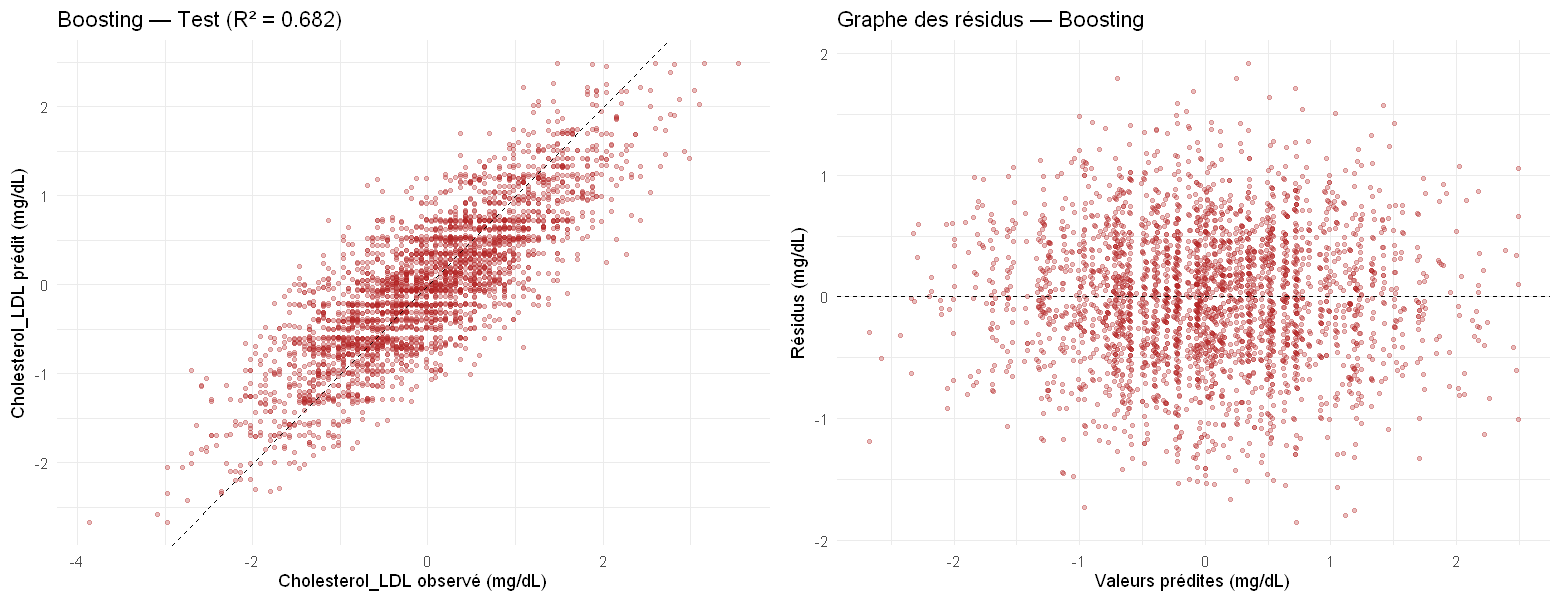

In [158]:
# Graphes valeurs prédites et résidus
df_boost_reg <- data.frame(
  observee = datestr$Cholesterol_LDL,
  predite  = pred_boost_reg_test,
  residus  = datestr$Cholesterol_LDL - pred_boost_reg_test
)

p5 <- ggplot(df_boost_reg, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "firebrick", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Boosting — Test (R² = %.3f)", r2_boost_reg)) +
  theme_minimal()

p6 <- ggplot(df_boost_reg, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "firebrick", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus — Boosting") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p5, p6, ncol = 2)

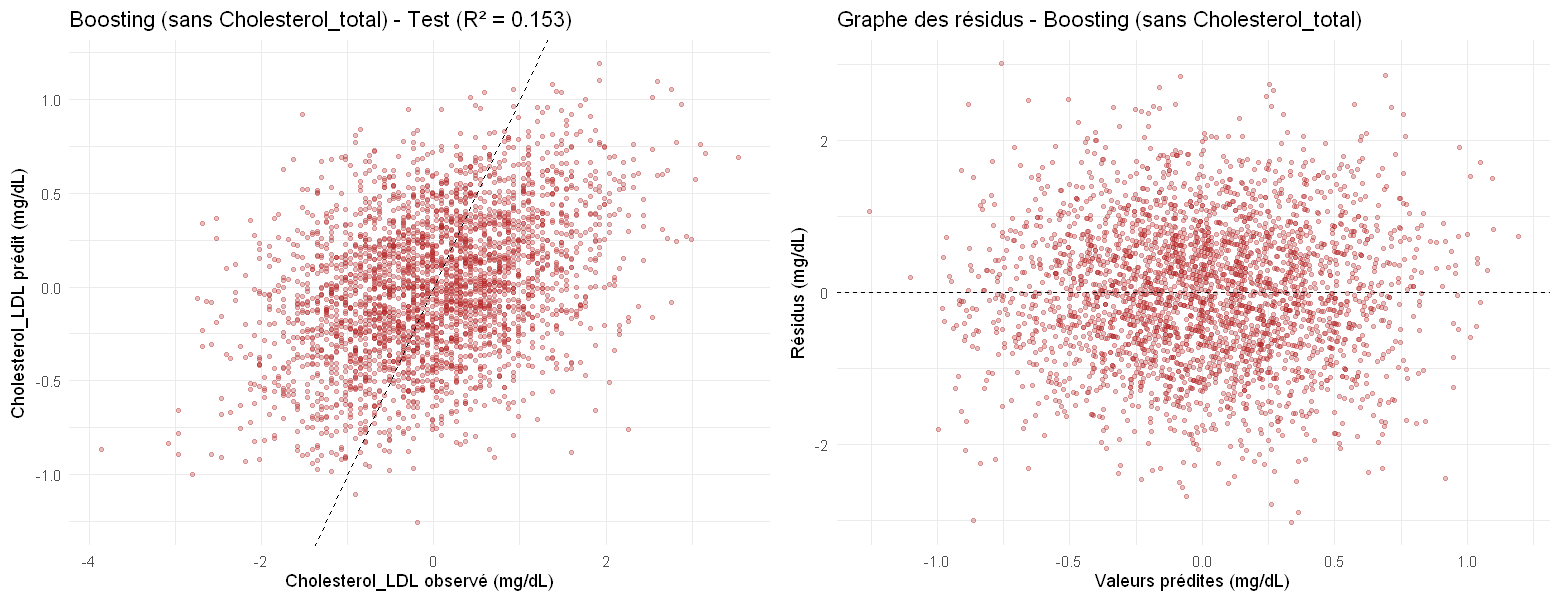

In [159]:
# Graphes valeurs prédites et résidus (sans Cholesterol_total)
df_boost_reg.v2 <- data.frame(
  observee = datestr.v2$Cholesterol_LDL,
  predite  = pred_boost_reg_test.v2,
  residus  = datestr.v2$Cholesterol_LDL - pred_boost_reg_test.v2
)

p5 <- ggplot(df_boost_reg.v2, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "firebrick", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Boosting (sans Cholesterol_total) - Test (R² = %.3f)", r2_boost_reg.v2)) +
  theme_minimal()

p6 <- ggplot(df_boost_reg.v2, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "firebrick", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Boosting (sans Cholesterol_total)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p5, p6, ncol = 2)

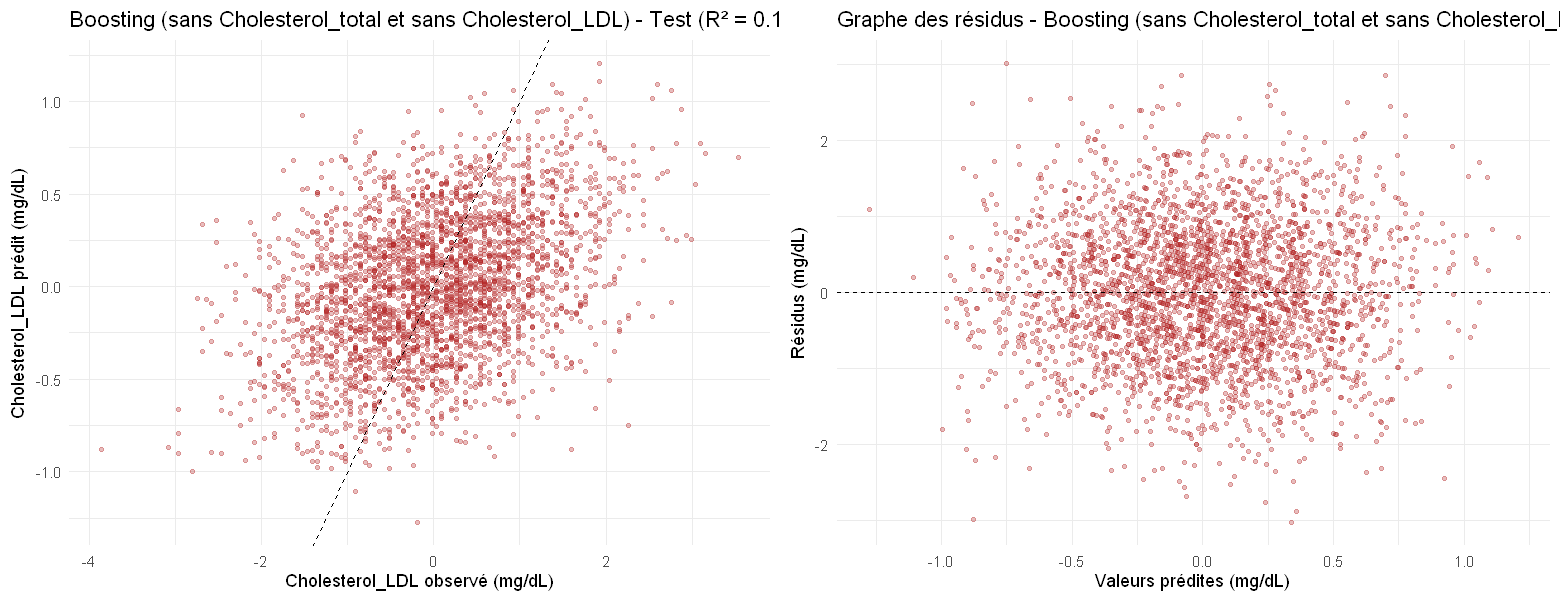

In [160]:
# Graphes valeurs prédites et résidus (sans Cholesterol_total et sans Cholesterol_LDL)
df_boost_reg.v3 <- data.frame(
  observee = datestr.v3$Cholesterol_LDL,
  predite  = pred_boost_reg_test.v3,
  residus  = datestr.v3$Cholesterol_LDL - pred_boost_reg_test.v3
)

p5 <- ggplot(df_boost_reg.v3, aes(x = observee, y = predite)) +
  geom_point(alpha = 0.3, colour = "firebrick", size = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  labs(x = "Cholesterol_LDL observé (mg/dL)",
       y = "Cholesterol_LDL prédit (mg/dL)",
       title = sprintf("Boosting (sans Cholesterol_total et sans Cholesterol_LDL) - Test (R² = %.3f)", r2_boost_reg.v3)) +
  theme_minimal()

p6 <- ggplot(df_boost_reg.v3, aes(x = predite, y = residus)) +
  geom_point(alpha = 0.3, colour = "firebrick", size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(x = "Valeurs prédites (mg/dL)", y = "Résidus (mg/dL)",
       title = "Graphe des résidus - Boosting (sans Cholesterol_total et sans Cholesterol_LDL)") +
  theme_minimal()

options(repr.plot.width = 13, repr.plot.height = 5)
grid.arrange(p5, p6, ncol = 2)

### 4.2.4 Importance des variables

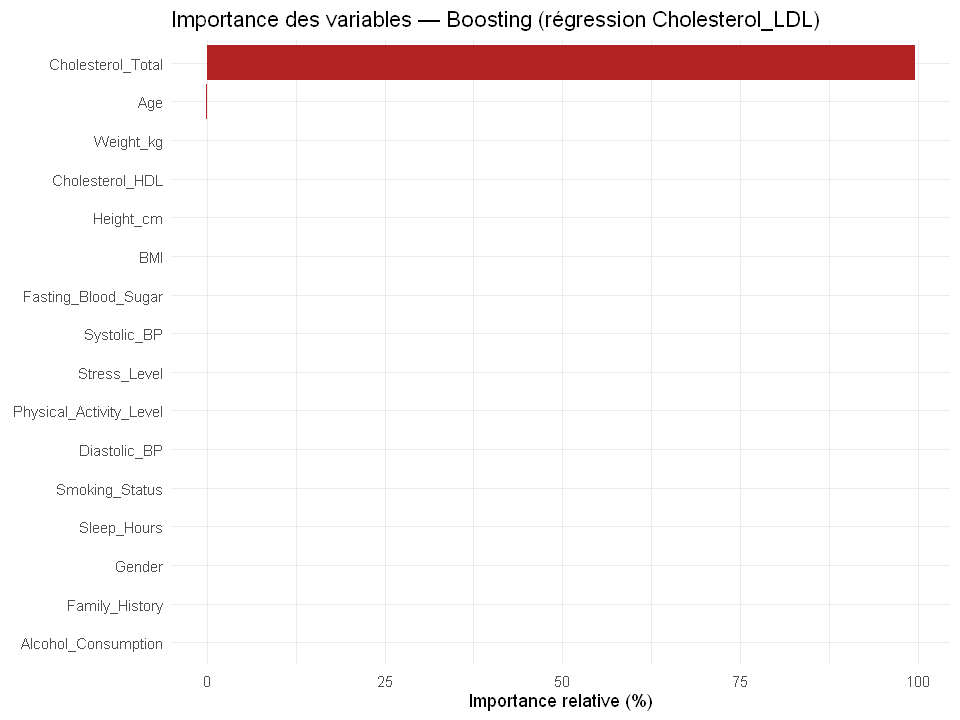

In [161]:
# Importance des variables (boosting régression)
imp_boost_reg <- summary(
  boost.reg.final,
  n.trees = grid_reg$n_trees_opt[best_row_reg],
  plotit  = FALSE
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_boost_reg, aes(x = reorder(var, rel.inf), y = rel.inf)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance relative (%)",
       title = "Importance des variables — Boosting (régression Cholesterol_LDL)") +
  theme_minimal()

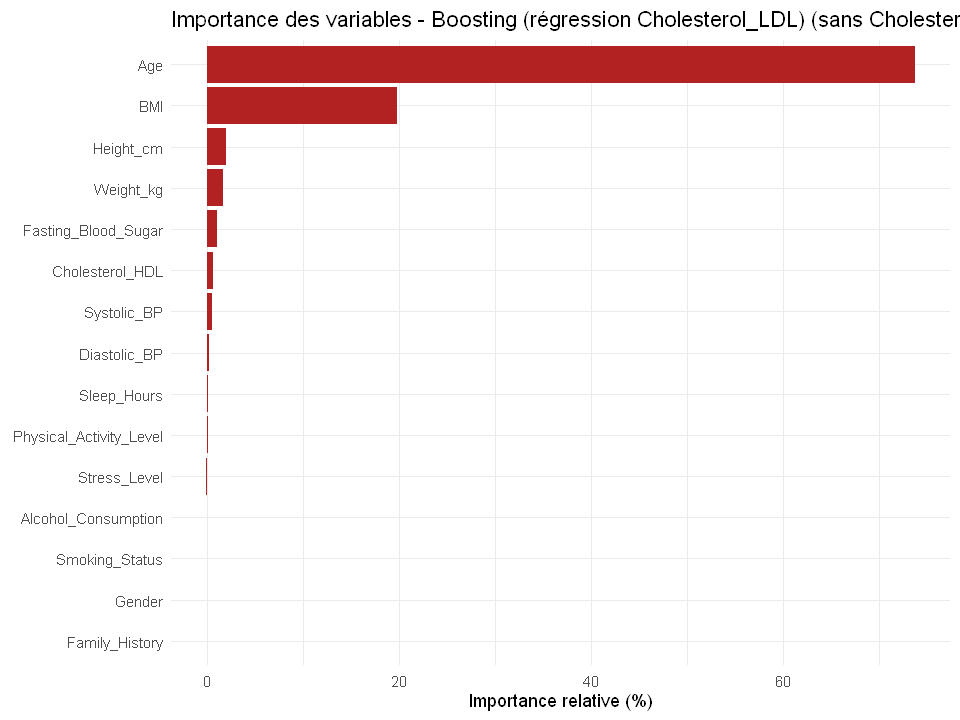

In [162]:
# Importance des variables (boosting régression) (sans Cholesterol_total)
imp_boost_reg.v2 <- summary(
  boost.reg.final.v2,
  n.trees = grid_reg.v2$n_trees_opt[best_row_reg],
  plotit  = FALSE
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_boost_reg.v2, aes(x = reorder(var, rel.inf), y = rel.inf)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance relative (%)",
       title = "Importance des variables - Boosting (régression Cholesterol_LDL) (sans Cholesterol_total)") +
  theme_minimal()

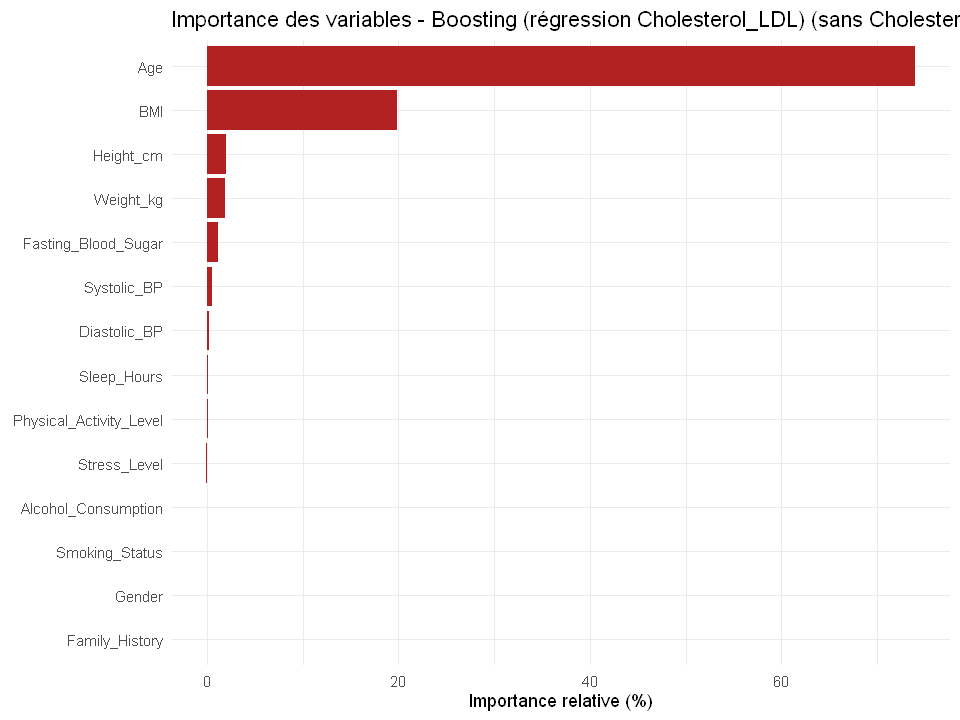

In [163]:
# Importance des variables (boosting régression) (sans Cholesterol_total et sans Cholesterol_LDL)
imp_boost_reg.v3 <- summary(
  boost.reg.final.v3,
  n.trees = grid_reg.v3$n_trees_opt[best_row_reg],
  plotit  = FALSE
)

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(imp_boost_reg.v3, aes(x = reorder(var, rel.inf), y = rel.inf)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  labs(x = NULL,
       y = "Importance relative (%)",
       title = "Importance des variables - Boosting (régression Cholesterol_LDL) (sans Cholesterol_total et sans Cholesterol_LDL)") +
  theme_minimal()

### 4.2.5 Bilan — Régression (`Cholesterol_LDL`)

In [164]:
# Tableau récapitulatif mis à jour (régression)
resultats_reg_complet <- data.frame(
  Modele = c("Arbre CART (élagué)", "Forêt aléatoire", "Boosting (gbm)", "Boosting (sans CT)", "Boosting (sans CT+LDL)"),
  RMSE   = round(c(rmse_tree_reg, rmse_rf_reg, rmse_boost_reg, rmse_boost_reg.v2, rmse_boost_reg.v3), 4),
  MAE    = round(c(mae_tree_reg,  mae_rf_reg,  mae_boost_reg, mae_boost_reg.v2, mae_boost_reg.v3),  4),
  R2     = round(c(r2_tree_reg,   r2_rf_reg,   r2_boost_reg, r2_boost_reg.v2, r2_boost_reg.v3),   4)
)
print(resultats_reg_complet)

                  Modele   RMSE    MAE     R2
1    Arbre CART (élagué) 0.5620 0.4469 0.6767
2        Forêt aléatoire 0.5661 0.4504 0.6719
3         Boosting (gbm) 0.5572 0.4432 0.6822
4     Boosting (sans CT) 0.9094 0.7293 0.1535
5 Boosting (sans CT+LDL) 0.9094 0.7294 0.1534


---
## Synthèse générale — Arbres, Forêts et Boosting

In [165]:
# Synthèse finale
cat("=== DISCRIMINATION — Heart_Disease_Risk ===\n")
print(resultats_dis_complet)

cat("\n=== RÉGRESSION — Cholesterol_LDL ===\n")
print(resultats_reg_complet)

cat("\nPoints-clés :\n",
    "- Arbre CART : interprétable (règles lisibles), mais sensible au bruit.\n",
    "  L élagage par CV (cp optimal) est indispensable.\n",
    "- Forêt aléatoire : réduit la variance par bagging + tirage aléatoire\n",
    "  des variables. Plus performante que l arbre seul, moins interprétable.\n",
    "- Boosting (gbm) : corrige séquentiellement les erreurs résiduel.\n",
    "  Souvent le modèle le plus performant, mais requiert un réglage soigneux\n",
    "  de shrinkage et interaction.depth pour éviter le sur-apprentissage.\n",
    "- L importance des variables est cohérente entre les trois méthodes\n",
    "  et avec l analyse exploratoire (ACP, corrélations).\n")

=== DISCRIMINATION — Heart_Disease_Risk ===
                        Modele Erreur Accuracy    AUC
1     Arbre CART Gini (élagué) 0.2793   0.7207 0.7520
2 Arbre CART Entropie (élagué) 0.2700   0.7300 0.7660
3              Forêt aléatoire 0.2660   0.7340 0.7886
4               Boosting (gbm) 0.2567   0.7433 0.8059

=== RÉGRESSION — Cholesterol_LDL ===
                  Modele   RMSE    MAE     R2
1    Arbre CART (élagué) 0.5620 0.4469 0.6767
2        Forêt aléatoire 0.5661 0.4504 0.6719
3         Boosting (gbm) 0.5572 0.4432 0.6822
4     Boosting (sans CT) 0.9094 0.7293 0.1535
5 Boosting (sans CT+LDL) 0.9094 0.7294 0.1534

Points-clés :
 - Arbre CART : interprétable (règles lisibles), mais sensible au bruit.
   L élagage par CV (cp optimal) est indispensable.
 - Forêt aléatoire : réduit la variance par bagging + tirage aléatoire
   des variables. Plus performante que l arbre seul, moins interprétable.
 - Boosting (gbm) : corrige séquentiellement les erreurs résiduel.
   Souvent le modèle